# <center> 3. Prescriptive Analysis

In [10]:
# importing required libraries
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", DeprecationWarning)

In [11]:
dfT1DData = pd.read_excel("../SourceData/Processed/Team10_PythonWranglers_CleanedData.xlsx")

## 1. What is the average Total Daily Dose (TDD) of insulin for each patient and what percentage of a person's TDD is accounted for by basal insulin vs bolus insulin?

### *Reasoning - Basal insulin keeps blood glucose stable in the absence of meals (background insulin). A high basal percentage may indicate that the participant relies more on background insulin indicating relatively stable blood glucose values. Medical practitioners generally recommend a good balance between bolus and basal insulin: 40–50% basal and 50–60% bolus, but it varies by individual.*

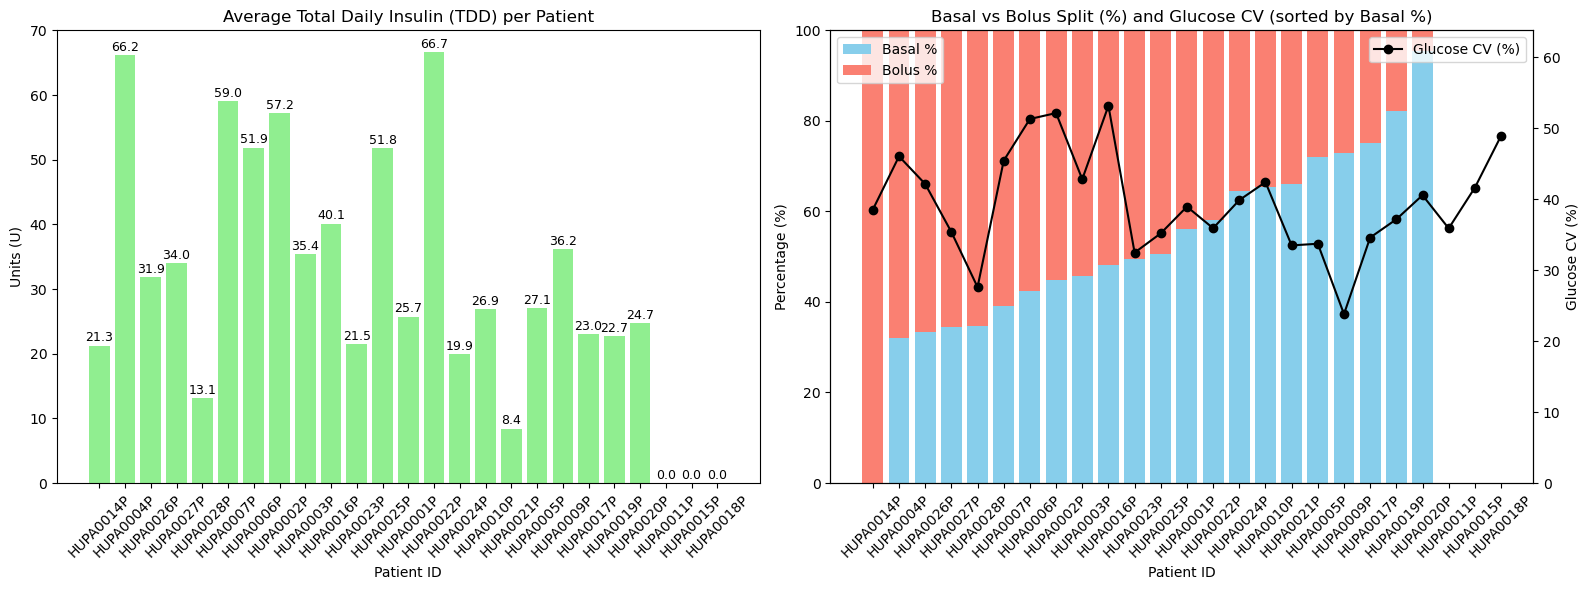

In [13]:
# --- Step 1: Constants ---
readings_per_day = 24 * 12  # 5-min intervals

# --- Step 2: Calculate daily mean per reading and scale to full day ---
daily_avg_per_reading = dfT1DData.groupby(['patient_id','date']).agg(
    basal_mean_per_reading=('basal_rate','mean'),
    bolus_mean_per_reading=('bolus_volume_delivered','mean')
).reset_index()

daily_avg_per_reading['basal_total'] = daily_avg_per_reading['basal_mean_per_reading'] * readings_per_day
daily_avg_per_reading['bolus_total'] = daily_avg_per_reading['bolus_mean_per_reading'] * readings_per_day
daily_avg_per_reading['TDD'] = daily_avg_per_reading['basal_total'] + daily_avg_per_reading['bolus_total']

# --- Step 3: Average across days per patient ---
avg_insulin = daily_avg_per_reading.groupby('patient_id').agg(
    avg_basal=('basal_total','mean'),
    avg_bolus=('bolus_total','mean'),
    avg_TDD=('TDD','mean')
).reset_index()

# --- Step 4: Basal/Bolus percentages ---
avg_insulin['basal_pct'] = (avg_insulin['avg_basal'] / avg_insulin['avg_TDD']) * 100
avg_insulin['bolus_pct'] = (avg_insulin['avg_bolus'] / avg_insulin['avg_TDD']) * 100

# --- Step 5: Glucose coefficient of variation per patient ---
glucose_stats = dfT1DData.groupby('patient_id')['glucose'].agg(['mean','std']).reset_index()
glucose_stats['CV'] = (glucose_stats['std'] / glucose_stats['mean']) * 100

# Merge CV into avg_insulin
avg_insulin = avg_insulin.merge(glucose_stats[['patient_id','CV']], on='patient_id', how='left')

# --- Step 6: Sort by basal percentage for stacked bar chart ---
avg_insulin_sorted = avg_insulin.sort_values(by='basal_pct').reset_index(drop=True)

# --- Step 7: Plot charts ---
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Left chart: Average TDD
axes[0].bar(avg_insulin_sorted['patient_id'], avg_insulin_sorted['avg_TDD'], color='lightgreen')
axes[0].set_title('Average Total Daily Insulin (TDD) per Patient')
axes[0].set_ylabel('Units (U)')
axes[0].set_xlabel('Patient ID')
axes[0].tick_params(axis='x', rotation=45)

# Add TDD value labels
for i, row in avg_insulin_sorted.iterrows():
    axes[0].text(i, row['avg_TDD'] + 0.2, f"{row['avg_TDD']:.1f}", ha='center', va='bottom', fontsize=9)

# Right chart: Basal vs Bolus % (100% stacked) with glucose CV overlay
axes[1].bar(avg_insulin_sorted['patient_id'], avg_insulin_sorted['basal_pct'], label='Basal %', color='skyblue')
axes[1].bar(avg_insulin_sorted['patient_id'], avg_insulin_sorted['bolus_pct'], 
            bottom=avg_insulin_sorted['basal_pct'], label='Bolus %', color='salmon')

# Overlay CV as a line plot on secondary y-axis
axes2 = axes[1].twinx()
axes2.plot(avg_insulin_sorted['patient_id'], avg_insulin_sorted['CV'], color='black', marker='o', linestyle='-', label='Glucose CV (%)')
axes2.set_ylabel('Glucose CV (%)')
axes2.set_ylim(0, max(avg_insulin_sorted['CV'])*1.2)

axes[1].set_title('Basal vs Bolus Split (%) and Glucose CV (sorted by Basal %)')
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left')
axes2.legend(loc='upper right')

plt.tight_layout()
plt.show()


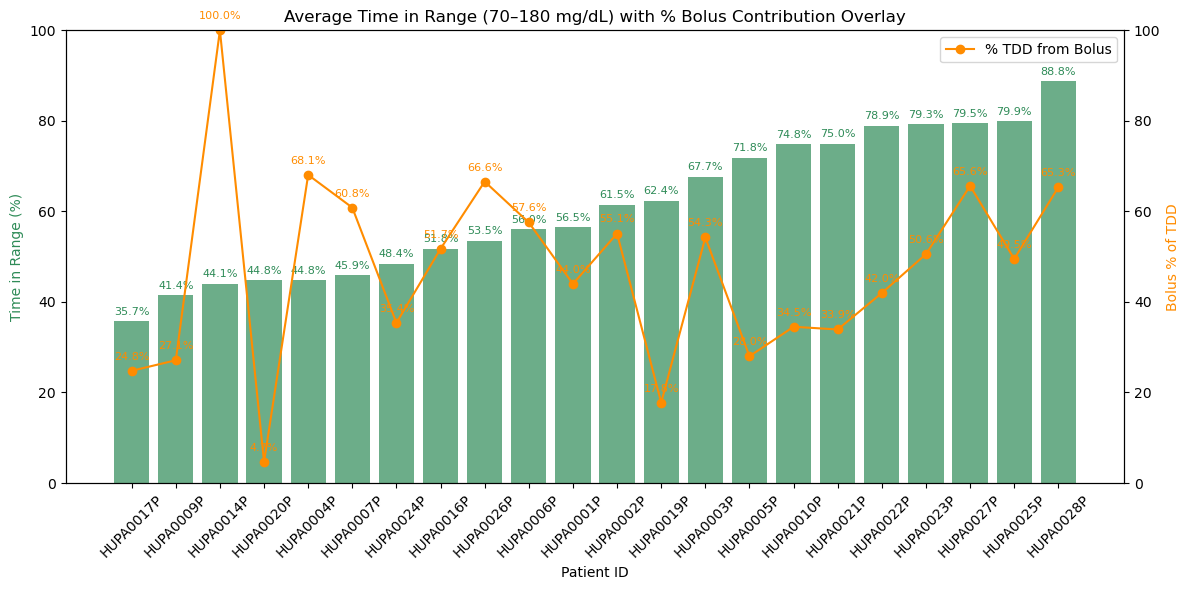

In [14]:
# --- Step 1: Calculate Time in Range (70–180 mg/dL) per patient ---
dfT1DData['in_range_flag'] = dfT1DData['glucose'].between(70, 180)

tir_stats = dfT1DData.groupby('patient_id')['in_range_flag'].mean().reset_index()
tir_stats['TIR_pct'] = tir_stats['in_range_flag'] * 100  # convert to percentage

# --- Step 2: Get % Bolus contribution from insulin stats ---
bolus_split = avg_insulin_sorted[['patient_id', 'bolus_pct', 'avg_basal', 'avg_bolus']]  

# --- Step 3: Merge ---
tir_merged = tir_stats.merge(bolus_split, on='patient_id', how='left')

# --- Step 4: Exclude participants with missing insulin (basal and bolus both 0) ---
tir_filtered = tir_merged[(tir_merged['avg_basal'] > 0) | (tir_merged['avg_bolus'] > 0)]

# --- Step 5: Sort by Time in Range ---
tir_sorted = tir_filtered.sort_values(by='TIR_pct', ascending=True).reset_index(drop=True)

# --- Step 6: Plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart: Average Time in Range per patient
bars = ax1.bar(tir_sorted['patient_id'], tir_sorted['TIR_pct'], color='seagreen', alpha=0.7)
ax1.set_ylabel('Time in Range (%)', color='seagreen')
ax1.set_xlabel('Patient ID')
ax1.set_title('Average Time in Range (70–180 mg/dL) with % Bolus Contribution Overlay')
ax1.set_ylim(0,100)
ax1.tick_params(axis='x', rotation=45)

# Add labels to bars
for bar, value in zip(bars, tir_sorted['TIR_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{value:.1f}%", ha='center', va='bottom', fontsize=8, color='seagreen')

# Line chart: % of TDD from bolus insulin
ax2 = ax1.twinx()
line = ax2.plot(tir_sorted['patient_id'], tir_sorted['bolus_pct'], 
         color='darkorange', marker='o', linestyle='-', label='% TDD from Bolus')
ax2.set_ylabel('Bolus % of TDD', color='darkorange')
ax2.set_ylim(0,100)

# Add labels to line points
for x, y in zip(tir_sorted['patient_id'], tir_sorted['bolus_pct']):
    ax2.text(x, y + 2, f"{y:.1f}%", ha='center', va='bottom', fontsize=8, color='darkorange')

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


### <span style="color: green;">When the glucose variability (coefficient of variance for glucose) is less than 36% it is considered to be stable by medical practioners.</span>

### <span style="color: green;">In the Basal vs Bolus Split (%) and Glucose CV chart, we can see that most participants with glucose CV < 36% have a higher basal % than bolus%. On the other hand, those with higher Bolus % than basal % have higher glucose variability on average.Therefore, we can conclude that having a higher % of total daily insulin requirement coming from basal insulin can indicate well-controlled blood sugar levels, since relying heavily on bolus insulin to regulate blood sugar means that there could be a lot of swing in glucose values around meal times. However relying too heavily on Basal Insulin increases the risk of hypoglycemia if meals are missed.</span>

### <span style="color: green;">From the above Average Time in Range with % Bolus Overlay chart we can conclude that Time in Range is higher for patients with a good balance between basal insulin and bolus insulin:
### <span style="color: green;">between 40% to 50% for Basal insulin and 
### <span style="color: green;">between 50% - 60% for bolus insulin).</span>

## 2. For participants spending large % time in hyperglycemia, should carb-to-insulin be adjusted?

### *Reasoning: Carb-to-insulin ratios are decided by medical practioners and individualized for each participant.*

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


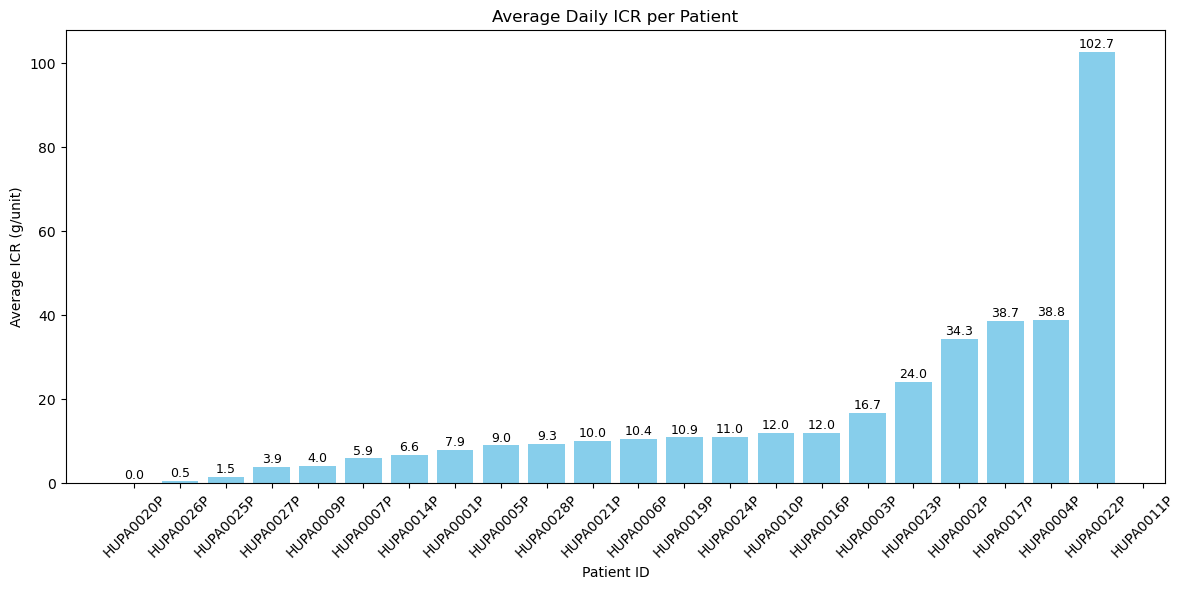

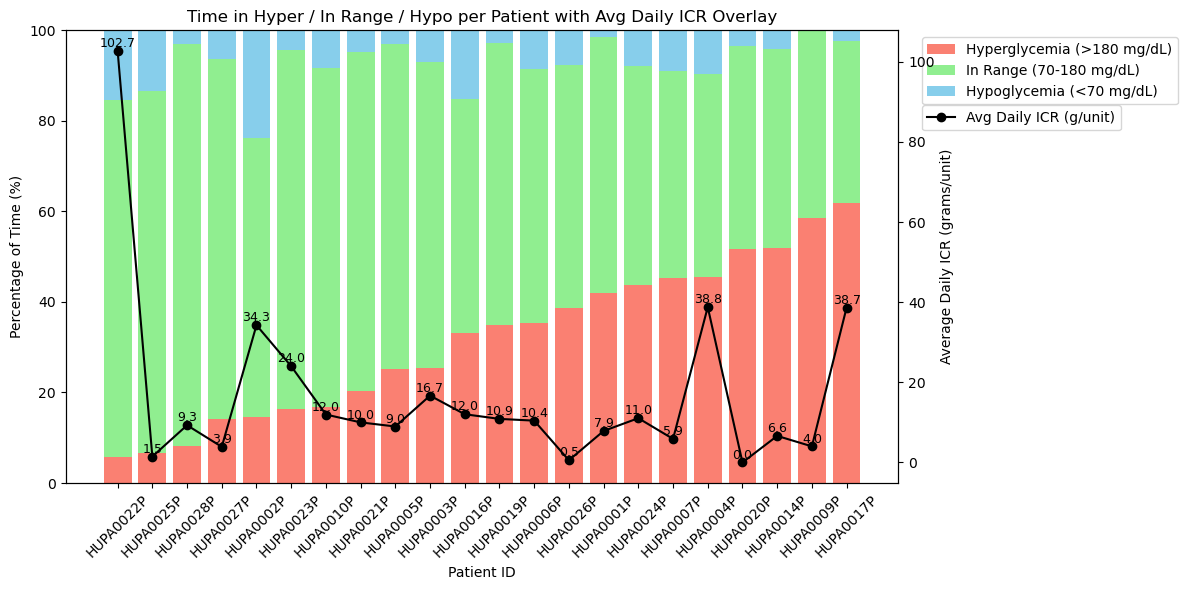

In [17]:
# -------------------------------
# Step 1: Compute daily ICR per patient
# -------------------------------
# Ensure carb in grams
dfT1DData['carb_grams'] = dfT1DData['carb_input'] * 10

def daily_icr_calc(group):
    total_carbs = group['carb_grams'].sum()
    total_bolus = group['bolus_volume_delivered'].sum()
    return total_carbs / total_bolus if total_bolus > 0 else np.nan

# Compute daily ICR
daily_icr = dfT1DData.groupby(['patient_id','date']).apply(daily_icr_calc).reset_index(name='daily_ICR')

# Average ICR per patient over all days
avg_icr_per_patient = daily_icr.groupby('patient_id')['daily_ICR'].mean().reset_index()

# -------------------------------
# Chart 1: Average ICR per patient (bar chart)
# -------------------------------
avg_icr_sorted = avg_icr_per_patient.sort_values('daily_ICR')
plt.figure(figsize=(12,6))
bars = plt.bar(avg_icr_sorted['patient_id'], avg_icr_sorted['daily_ICR'], color='skyblue')

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.2, f"{height:.1f}", ha='center', va='bottom', fontsize=9)

plt.xlabel("Patient ID")
plt.ylabel("Average ICR (g/unit)")
plt.title("Average Daily ICR per Patient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# Step 2: Compute Time in Hyper/In-range/Hypo per patient
# -------------------------------
dfT1DData['hypo'] = (dfT1DData['glucose'] < 70).astype(int)
dfT1DData['in_range'] = ((dfT1DData['glucose'] >= 70) & (dfT1DData['glucose'] <= 180)).astype(int)
dfT1DData['hyper'] = (dfT1DData['glucose'] > 180).astype(int)

time_stats = dfT1DData.groupby('patient_id').agg(
    total_readings=('glucose','count'),
    hypo_readings=('hypo','sum'),
    in_range_readings=('in_range','sum'),
    hyper_readings=('hyper','sum')
).reset_index()

time_stats['pct_hypo'] = (time_stats['hypo_readings']/time_stats['total_readings'])*100
time_stats['pct_in_range'] = (time_stats['in_range_readings']/time_stats['total_readings'])*100
time_stats['pct_hyper'] = (time_stats['hyper_readings']/time_stats['total_readings'])*100

# -------------------------------
# Step 3: Merge time stats with daily-averaged ICR
# -------------------------------
merged = time_stats.merge(avg_icr_per_patient.rename(columns={'daily_ICR':'avg_ICR'}), on='patient_id')

# Remove patients with avg_ICR = NaN (no bolus)
merged = merged[merged['avg_ICR'].notna()]

# Order by ascending hyperglycemia %
merged = merged.sort_values('pct_hyper')

# -------------------------------
# Chart 2: Stacked bar (hyper at base) with overlay daily-averaged ICR
# -------------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Stacked bars: hyper at base
ax1.bar(merged['patient_id'], merged['pct_hyper'], label='Hyperglycemia (>180 mg/dL)', color='salmon')
ax1.bar(merged['patient_id'], merged['pct_in_range'], bottom=merged['pct_hyper'], label='In Range (70-180 mg/dL)', color='lightgreen')
ax1.bar(merged['patient_id'], merged['pct_hypo'], bottom=merged['pct_hyper'] + merged['pct_in_range'], label='Hypoglycemia (<70 mg/dL)', color='skyblue')

ax1.set_xlabel("Patient ID")
ax1.set_ylabel("Percentage of Time (%)")
ax1.set_title("Time in Hyper / In Range / Hypo per Patient with Avg Daily ICR Overlay")
ax1.set_xticklabels(merged['patient_id'], rotation=45)

# Overlay line chart for avg ICR
ax2 = ax1.twinx()
line = ax2.plot(merged['patient_id'], merged['avg_ICR'], color='black', marker='o', label='Avg Daily ICR (g/unit)')
ax2.set_ylabel("Average Daily ICR (grams/unit)")

# Add labels for each point on the line
for x, y in zip(range(len(merged['patient_id'])), merged['avg_ICR']):
    ax2.text(x, y + 0.2, f"{y:.1f}", ha='center', va='bottom', fontsize=9, color='black')

# Legends
ax1.legend(loc='upper left', bbox_to_anchor=(1.02,1))
ax2.legend(loc='upper left', bbox_to_anchor=(1.02,0.85))

plt.tight_layout()
plt.show()

### <span style="color: green;">From the above chart, we can observe that excepting some outlier patients such as patients 17, 4, 2 and 23 (who are all outliers with unusually large ICR which indicated high insulin sensitivity not typical of T1D patients), most patients who spend >25% of time in hyperglycemia have a higher ICR. It is recommended that their ICR be reduced to improve their time in range.</span>

## 3. For participants with frequent hypoglycemia, should basal insulin rates be lowered at certain times of day (e.g., overnight)?

### *Reasoning: If basal dose is too high, glucose can drop during sleep when there is no food intake.*

C:\Users\kitka\AppData\Local\Temp\ipykernel_5316\2473101129.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  night_window['hypo'] = (night_window['glucose'] < 70).astype(int)


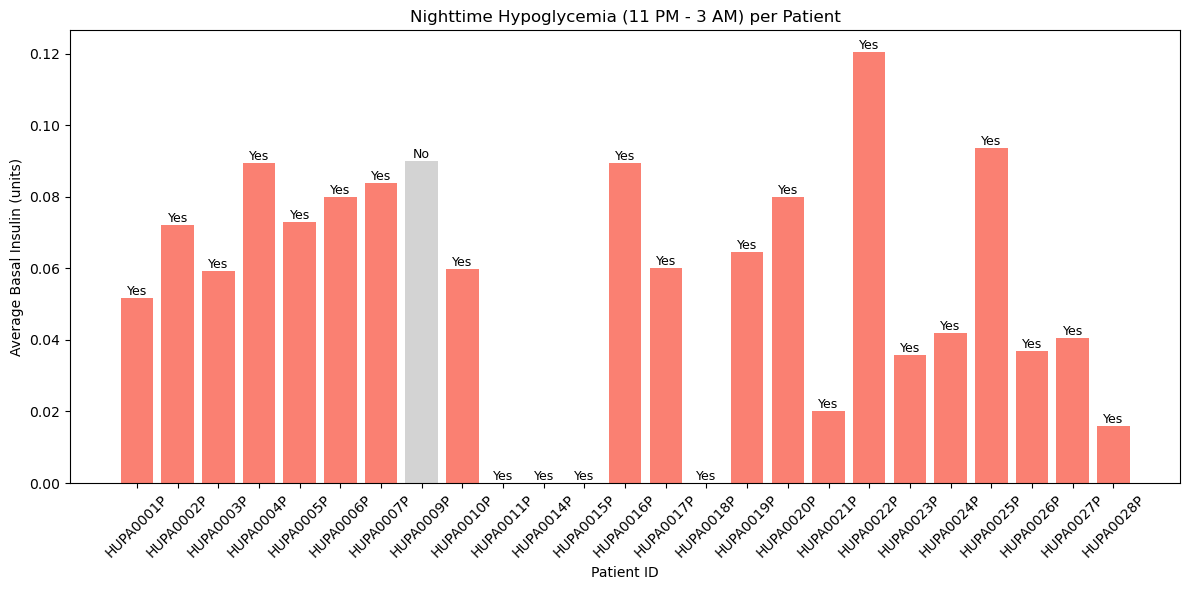

In [20]:
# Ensure 'time' column is datetime
dfT1DData['time'] = pd.to_datetime(dfT1DData['time'])

# Extract time only
dfT1DData['hour'] = dfT1DData['time'].dt.hour

# Define night window: 11 PM (23) to 3 AM (3)
# Since 3 AM is next day, we filter two conditions
night_window = dfT1DData[(dfT1DData['hour'] >= 23) | (dfT1DData['hour'] <= 3)]

# Mark hypoglycemia
night_window['hypo'] = (night_window['glucose'] < 70).astype(int)

# Group by patient to get:
# 1) Did they experience hypoglycemia at least once?
# 2) Average basal insulin during this period
night_stats = night_window.groupby('patient_id').agg(
    had_hypo=('hypo', 'max'),  # 1 if at least one hypoglycemia reading
    avg_basal=('basal_rate', 'mean')
).reset_index()

# Optional: map 0/1 to Yes/No for clarity
night_stats['had_hypo'] = night_stats['had_hypo'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(12,6))

# Color: red if hypoglycemia occurred, grey if not
colors = night_stats['had_hypo'].map({'Yes':'salmon', 'No':'lightgrey'})

bars = plt.bar(night_stats['patient_id'], night_stats['avg_basal'], color=colors)
plt.xlabel('Patient ID')
plt.ylabel('Average Basal Insulin (units)')
plt.title('Nighttime Hypoglycemia (11 PM - 3 AM) per Patient')

# Add labels indicating whether hypoglycemia occurred
for bar, had_hypo in zip(bars, night_stats['had_hypo']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, had_hypo, ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


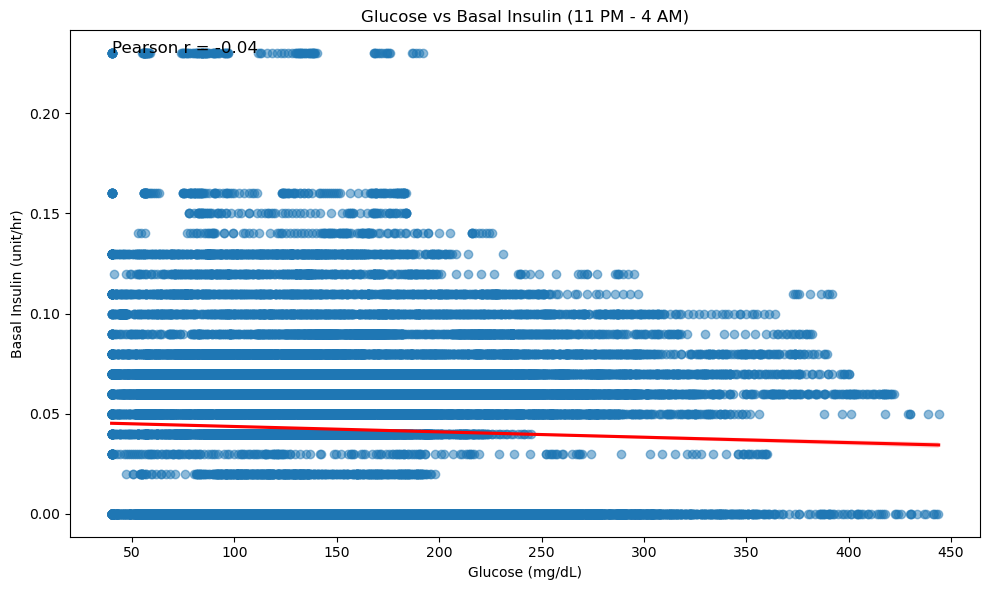

In [21]:
from scipy.stats import pearsonr

# Filter for 11 PM to 4 AM
night_window = dfT1DData[(dfT1DData['hour'] >= 23) | (dfT1DData['hour'] <= 4)]

# Compute Pearson correlation
corr, p_value = pearsonr(night_window['glucose'], night_window['basal_rate'])

# Scatter plot with regression line
plt.figure(figsize=(10,6))
sns.regplot(
    data=night_window,
    x='glucose',
    y='basal_rate',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

# Add correlation coefficient as text on the plot
plt.text(
    x=night_window['glucose'].min(),
    y=night_window['basal_rate'].max(),
    s=f"Pearson r = {corr:.2f}",
    fontsize=12,
    color='black'
)

plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Basal Insulin (unit/hr)")
plt.title("Glucose vs Basal Insulin (11 PM - 4 AM)")
plt.tight_layout()
plt.show()


### <span style="color: green;">From the above chart, we can observe a very slight negative correlation between basal insulin and Glucose values indicating that as basal insulin increases, glucose values decrease. For patients experiencing frequent hypoglycemia, it is recommended that their basal insulin dosage be reduced at night to prevent nighttime hypoglycemia.</span>

## 4. How does the glucose value change in a patients post a meal?

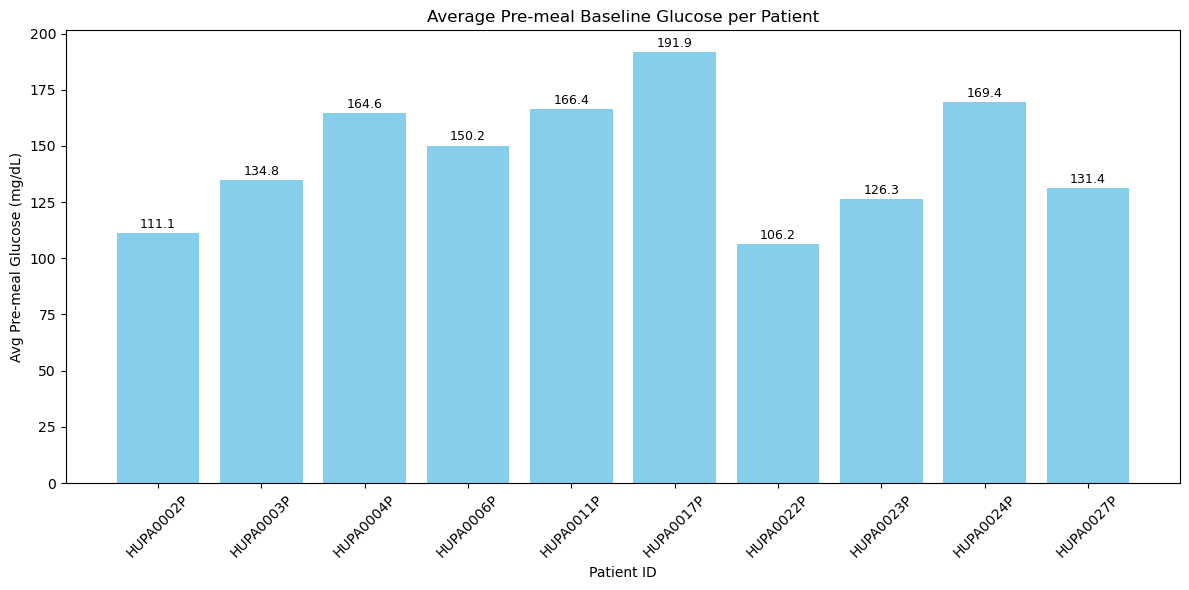

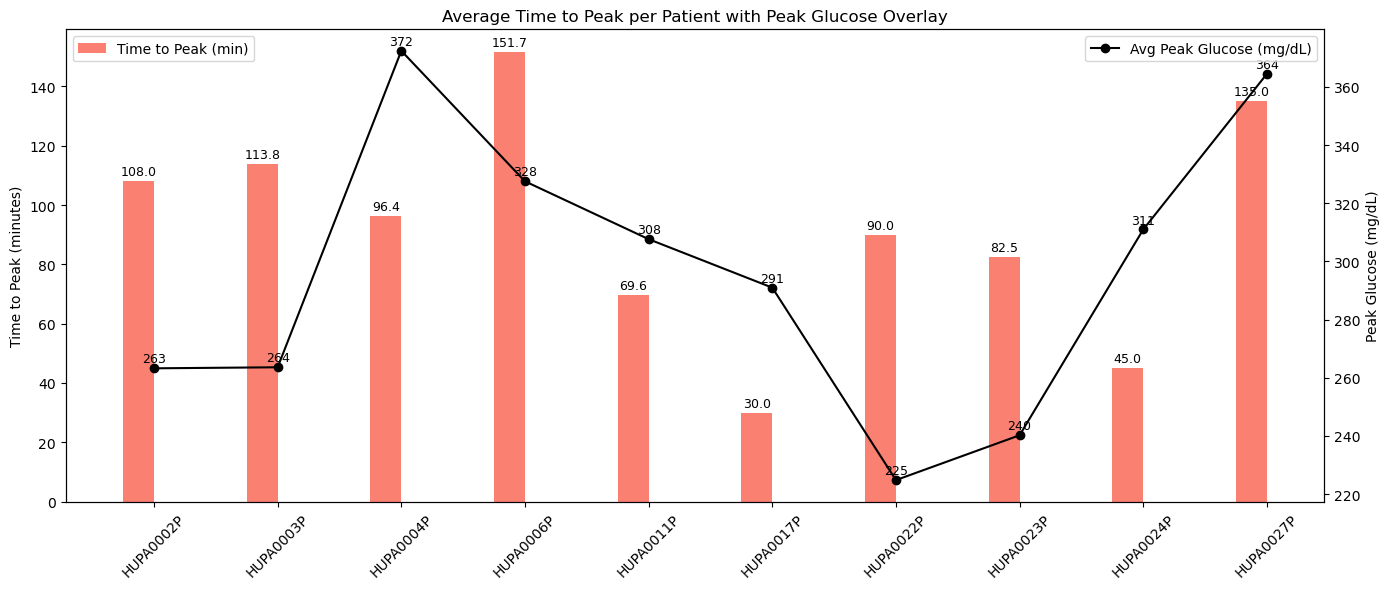

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Constants ---
LARGE_MEAL_THRESHOLD = 9        # carb_input >= 4 servings
PRE_MEAL_WINDOW_MIN = 30        # minutes before meal
POST_MEAL_WINDOW_HR = 3         # hours after meal
MIN_GAP_BETWEEN_MEALS_MIN = 60  # minutes between meals

# Ensure 'time' is datetime
dfT1DData['time'] = pd.to_datetime(dfT1DData['time'])

# Initialize lists
patient_ids = []
premeal_baselines = []
avg_time_to_peak = []
avg_peak_glucose = []

for patient_id, g in dfT1DData.groupby('patient_id'):
    g = g.sort_values('time')
    last_meal_time = None
    baseline_list = []
    time_to_peak_list = []
    peak_glucose_list = []

    for idx, row in g.iterrows():
        if row['carb_input'] >= LARGE_MEAL_THRESHOLD:
            meal_time = row['time']

            # Skip meals too close together
            if last_meal_time is not None and (meal_time - last_meal_time).total_seconds()/60 < MIN_GAP_BETWEEN_MEALS_MIN:
                continue

            # Pre-meal baseline
            pre_window_start = meal_time - pd.Timedelta(minutes=PRE_MEAL_WINDOW_MIN)
            premeal_vals = g[(g['time'] >= pre_window_start) & (g['time'] < meal_time)]['glucose']
            if not premeal_vals.empty:
                baseline = premeal_vals.mean()
                baseline_list.append(baseline)

            # Post-meal window
            post_window_end = meal_time + pd.Timedelta(hours=POST_MEAL_WINDOW_HR)
            postmeal_vals = g[(g['time'] >= meal_time) & (g['time'] <= post_window_end)][['time','glucose']].reset_index(drop=True)
            if not postmeal_vals.empty:
                # Time to peak
                peak_idx = postmeal_vals['glucose'].idxmax()
                peak_row = postmeal_vals.loc[peak_idx]
                time_peak = (peak_row['time'] - meal_time).total_seconds()/60
                time_to_peak_list.append(time_peak)
                peak_glucose_list.append(peak_row['glucose'])

            last_meal_time = meal_time

    # Store averages per patient
    if baseline_list:
        patient_ids.append(patient_id)
        premeal_baselines.append(np.mean(baseline_list))
        avg_time_to_peak.append(np.mean(time_to_peak_list) if time_to_peak_list else np.nan)
        avg_peak_glucose.append(np.mean(peak_glucose_list) if peak_glucose_list else np.nan)

# Create summary DataFrame
meal_metrics = pd.DataFrame({
    'patient_id': patient_ids,
    'avg_premeal_baseline': premeal_baselines,
    'avg_time_to_peak_min': avg_time_to_peak,
    'avg_peak_glucose': avg_peak_glucose
})

# ------------------ Chart 1: Average Pre-meal Baseline ------------------
plt.figure(figsize=(12,6))
bars = plt.bar(meal_metrics['patient_id'], meal_metrics['avg_premeal_baseline'], color='skyblue')
plt.xlabel('Patient ID')
plt.ylabel('Avg Pre-meal Glucose (mg/dL)')
plt.title('Average Pre-meal Baseline Glucose per Patient')
plt.xticks(rotation=45)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ------------------ Chart 2: Time to Peak and Peak Glucose ------------------
x = np.arange(len(meal_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14,6))

bars1 = ax.bar(x - width/2, meal_metrics['avg_time_to_peak_min'], width, label='Time to Peak (min)', color='salmon')

# Overlay peak glucose as points
ax2 = ax.twinx()
line = ax2.plot(x, meal_metrics['avg_peak_glucose'], color='black', marker='o', label='Avg Peak Glucose (mg/dL)')
ax2.set_ylabel('Peak Glucose (mg/dL)')

# Add bar labels
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}", ha='center', va='bottom', fontsize=9)

# Add labels for peak glucose points
for i, y in enumerate(meal_metrics['avg_peak_glucose']):
    if not np.isnan(y):
        ax2.text(x[i], y + 1, f"{y:.0f}", ha='center', va='bottom', fontsize=9, color='black')

ax.set_xticks(x)
ax.set_xticklabels(meal_metrics['patient_id'], rotation=45)
ax.set_ylabel('Time to Peak (minutes)')
ax.set_title('Average Time to Peak per Patient with Peak Glucose Overlay')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


### <span style="color: green;">From the first chart, we can see the average pre-meal baseline glucose of patients who would go on to eat large meals (carbs > 9 units).

### <span style="color: green;">In the second chart we see the average peak glucose values reached with 3 hours of the meal for each patient along with the average time taken to reach the peak glucose value.

### <span style="color: green;">From these charts, we can observe that the average post-meal peak is above 250 mg/dL for most patients with highest peak being at 372 mg/dL and the time to peak is also low for some patients with some patients' blood glucose shooting up within 30-45 minutes of the meal. It is recommended that the bolus dosage be increased for these participants.</span>

## 5. What is Dawn Phenomenon and how does it impact blood glucose levels?

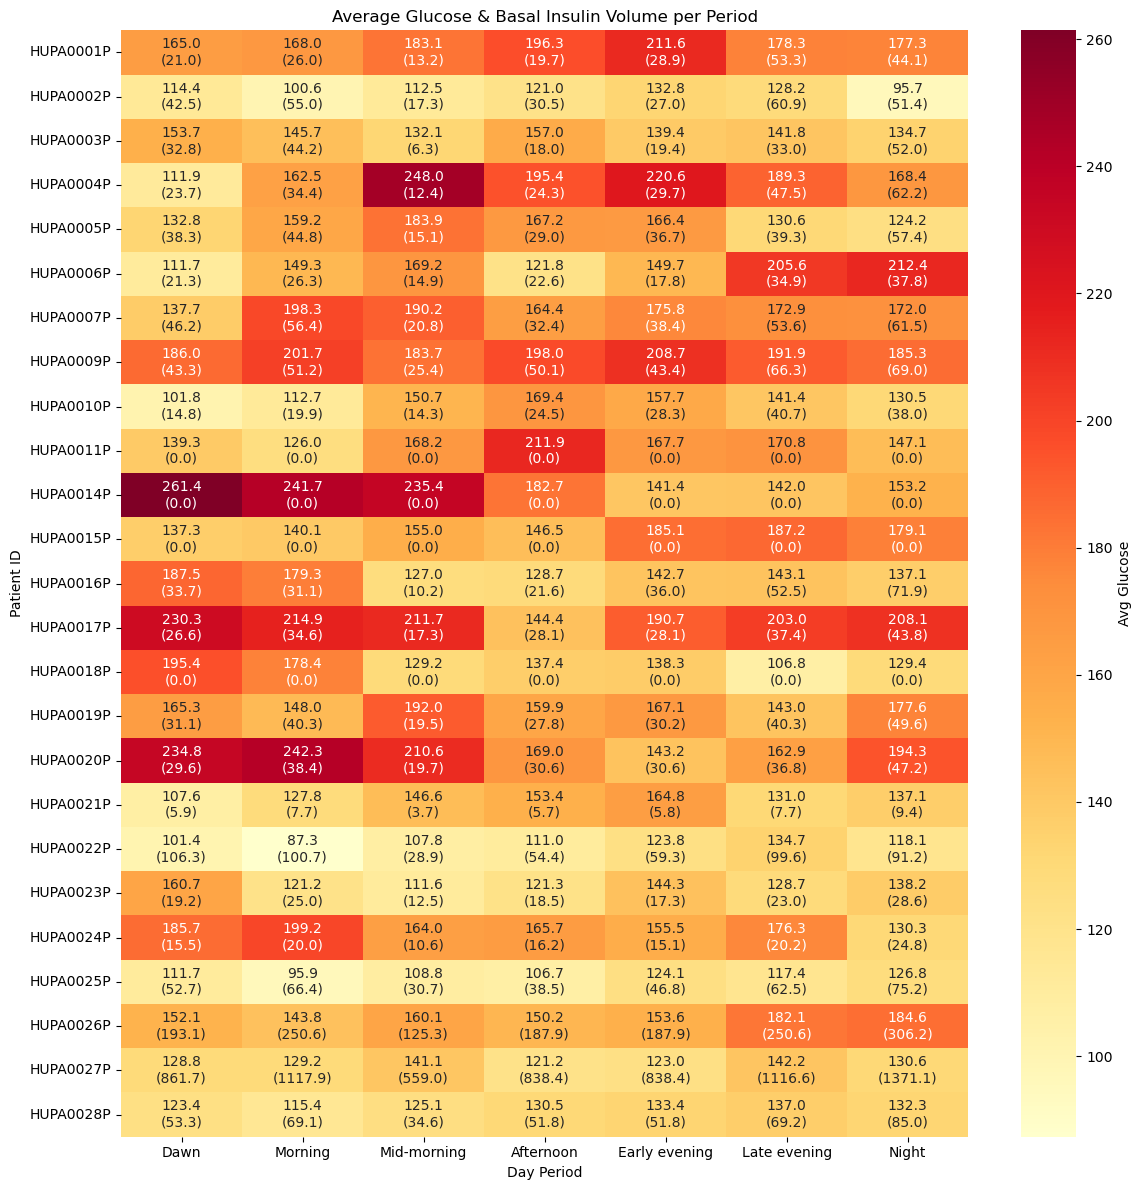

In [27]:
# Define the time periods
time_periods = [
    ("Dawn", "03:00:00", "06:00:00"),
    ("Morning", "06:00:00", "10:00:00"),
    ("Mid-morning", "10:00:00", "12:00:00"),
    ("Afternoon", "12:00:00", "15:00:00"),
    ("Early evening", "15:00:00", "18:00:00"),
    ("Late evening", "18:00:00", "22:00:00"),
    ("Night", "22:00:00", "23:59:59"),
    ("Night", "00:00:00", "03:00:00")  # split across midnight
]

# Function to assign period
def assign_period(t):
    for name, start, end in time_periods:
        if start <= t.strftime("%H:%M:%S") <= end:
            return name
    return None

# Assign period column
dfT1DData['period'] = dfT1DData['time'].dt.time.apply(assign_period)
period_order = ["Dawn", "Morning", "Mid-morning", "Afternoon", 
                "Early evening", "Late evening", "Night"]
dfT1DData['period'] = pd.Categorical(dfT1DData['period'], categories=period_order, ordered=True)

# Group by patient & period
summary = dfT1DData.groupby(['patient_id','period']).agg({
    'glucose': 'mean',
    'basal_rate': 'sum',
    'bolus_volume_delivered': 'sum'
}).reset_index()

# Pivot for heatmap
heatmap_data = summary.pivot(index='patient_id', columns='period', values='glucose')

# Create annotation with both glucose + basal insulin
annotations = summary.pivot(index='patient_id', columns='period', values='glucose').copy()

for i in range(annotations.shape[0]):
    for j in range(annotations.shape[1]):
        g = summary[(summary['patient_id'] == annotations.index[i]) & 
                    (summary['period'] == annotations.columns[j])]
        if not g.empty:
            glucose_val = round(g['glucose'].values[0], 1)
            basal_val = round(g['basal_rate'].values[0], 1)
            bolus_val = round(g['bolus_volume_delivered'].values[0], 1)
            annotations.iloc[i, j] = f"{glucose_val}\n({basal_val})"
        else:
            annotations.iloc[i, j] = ""

# Plot heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(heatmap_data, annot=annotations, fmt="", cmap="YlOrRd", cbar_kws={'label': 'Avg Glucose'})
plt.title("Average Glucose & Basal Insulin Volume per Period")
plt.ylabel("Patient ID")
plt.xlabel("Day Period")
plt.tight_layout()
plt.show()

### <span style="color: green;">From the above chart, we can observe that some patients have very high blood glucose at dawn. This is due to dawn phenomenon. It is recommended that for patients experiencing dawn phenomenon, the dosage of basal insulin be increased in the early morning hours.</span>

## 6.	Should patients with frequent nocturnal lows eat balanced bedtime snacks (protein + complex carbs)?


=== overnight_pct_low by SnackGroup ===
            N_nights  Mean    SD
SnackGroup                      
Balanced          12  4.05  8.53
NoSnack         1039  7.52 18.85
CarbOnly          20 17.08 28.84

=== overnight_min by SnackGroup ===
            N_nights   Mean    SD
SnackGroup                       
CarbOnly          20  95.42 57.33
NoSnack         1039 101.45 43.23
Balanced          12 115.04 59.31

=== overnight_mean by SnackGroup ===
            N_nights   Mean    SD
SnackGroup                       
CarbOnly          20 128.24 57.32
NoSnack         1039 138.85 48.77
Balanced          12 174.89 71.82

=== overnight_low_events by SnackGroup ===
            N_nights  Mean    SD
SnackGroup                      
Balanced          12  2.92  6.14
NoSnack         1039  5.42 13.57
CarbOnly          20 12.30 20.76

=== Within-patient: Overnight %<70 (Balanced - NoSnack) ===
patient_id  Balanced  NoSnack  diff_bal_minus_none
 HUPA0002P      1.39    35.80               -34.41
 HUPA00

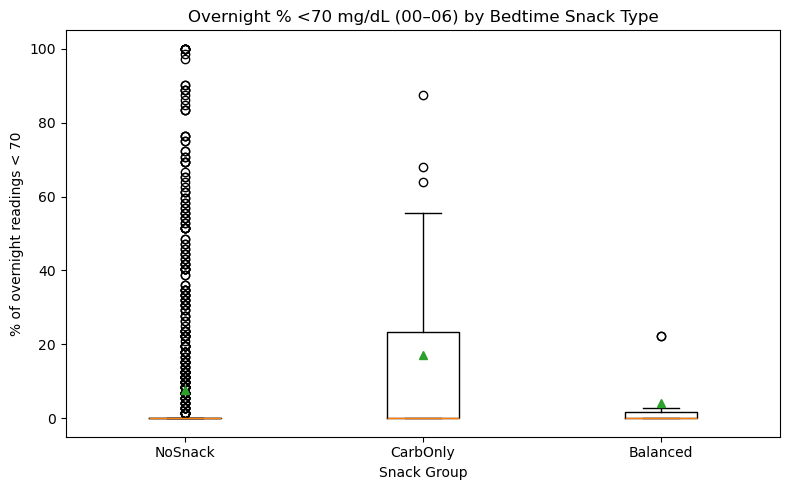

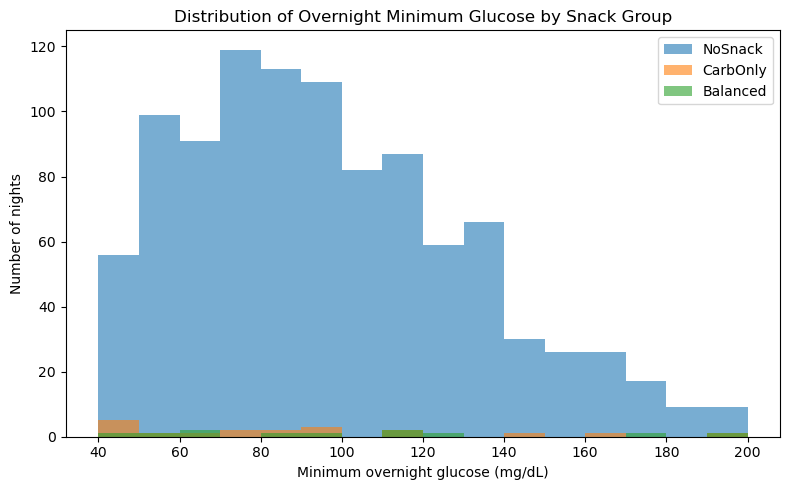

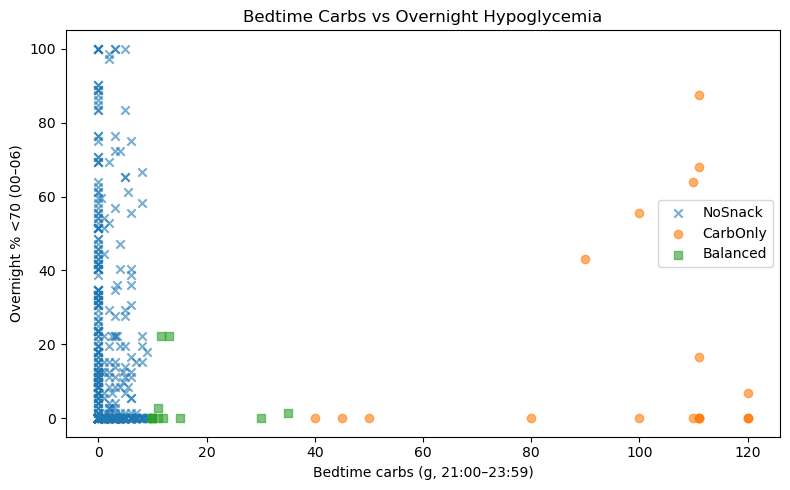

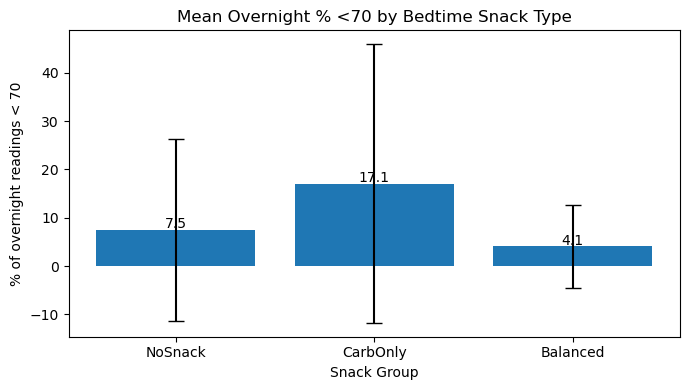


N nights → Balanced: 12, CarbOnly: 20, NoSnack: 1039
If 'Balanced' shows lower overnight %<70 and higher minimum glucose, especially in the within-patient test,
that supports recommending balanced bedtime snacks (protein + complex carbs) for patients with frequent nocturnal lows.


In [30]:
# ============================================================
# Bedtime snack quality vs overnight hypoglycemia
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# -------------------- 0) Config --------------------
BEDTIME_START, BEDTIME_END = 21, 23     # bedtime window 21:00–23:59
OVN_START, OVN_END         = 0, 5       # overnight 00:00–05:59
CARB_MIN_G                 = 10.0       # minimum carbs to count as a snack
PROTEIN_MIN_G              = 7.0        # protein grams to call it "balanced" when protein column exists
CAL_PER_CARB_BALANCED_MIN  = 10.0       # proxy: calories per gram of carbs (suggests protein/fat present)
MIN_OVN_READS              = 6          # minimum overnight readings to keep a night

# -------------------- 1) Prep dates & windows --------------------
df = dfT1DData.copy()
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df = df.dropna(subset=["date_time"])
df["date"] = df["date_time"].dt.date
df["hour"] = df["date_time"].dt.hour

# Flags
df["is_bedtime"]  = (df["hour"] >= BEDTIME_START) & (df["hour"] <= BEDTIME_END)
df["is_overnight"] = (df["hour"] >= OVN_START) & (df["hour"] <= OVN_END)

# Map bedtime to the *next* night's overnight window
df["study_night"] = pd.to_datetime(df["date"])
df.loc[df["is_bedtime"], "study_night"] = df.loc[df["is_bedtime"], "study_night"] + timedelta(days=1)
df["study_night"] = df["study_night"].dt.date

# Ensure numeric
for col in ["glucose","carb_input","calories"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Try to find a protein column if present
protein_col = None
for c in df.columns:
    cl = c.strip().lower().replace("–","-").replace("—","-")
    if "protein" in cl:
        protein_col = c
        df[protein_col] = pd.to_numeric(df[protein_col], errors="coerce").fillna(0)
        break

# -------------------- 2) Bedtime snack classification per patient-night --------------------
# Aggregate bedtime window
bt = (df[df["is_bedtime"]]
      .groupby(["patient_id","study_night"])
      .agg(carb_g=("carb_input","sum"),
           cal_sum=("calories","sum"))
      .reset_index())

if protein_col:
    prot = (df[df["is_bedtime"]]
            .groupby(["patient_id","study_night"])[protein_col]
            .sum()
            .reset_index()
            .rename(columns={protein_col:"protein_g"}))
    bt = bt.merge(prot, on=["patient_id","study_night"], how="left")
else:
    bt["protein_g"] = np.nan  # not available

# Snack group rules
def classify_snack(row):
    carb = row["carb_g"]
    prot = row["protein_g"]
    cals = row["cal_sum"]
    if pd.isna(carb) or carb < CARB_MIN_G:
        return "NoSnack"
    # if protein available, use it
    if not np.isnan(prot):
        return "Balanced" if prot >= PROTEIN_MIN_G else "CarbOnly"
    # else use calorie-per-carb proxy (higher => likely protein/fat included)
    if carb > 0:
        cal_per_carb = cals / carb
        return "Balanced" if cal_per_carb >= CAL_PER_CARB_BALANCED_MIN else "CarbOnly"
    return "NoSnack"

bt["SnackGroup"] = bt.apply(classify_snack, axis=1)

# Fill nights without any bedtime rows → NoSnack
nights_all = df.groupby(["patient_id","study_night"], as_index=False).size()[["patient_id","study_night"]]
bt = nights_all.merge(bt, on=["patient_id","study_night"], how="left")
bt["carb_g"] = bt["carb_g"].fillna(0.0)
bt["cal_sum"] = bt["cal_sum"].fillna(0.0)
bt["protein_g"] = bt["protein_g"].fillna(0.0)
bt["SnackGroup"] = bt["SnackGroup"].fillna("NoSnack")

# -------------------- 3) Overnight hypoglycemia metrics per night --------------------
def overnight_stats(g):
    w = g[g["is_overnight"]]
    vals = pd.to_numeric(w["glucose"], errors="coerce").dropna()
    if vals.empty:
        return pd.Series({"overnight_n":0, "overnight_mean":np.nan, "overnight_min":np.nan,
                          "overnight_pct_low":np.nan, "overnight_low_events":np.nan})
    return pd.Series({
        "overnight_n": len(vals),
        "overnight_mean": vals.mean(),
        "overnight_min":  vals.min(),
        "overnight_pct_low": (vals < 70).mean()*100,
        "overnight_low_events": int((vals < 70).sum())
    })

overnight = (df.groupby(["patient_id","study_night"])
               .apply(overnight_stats)
               .reset_index())

overnight = overnight[overnight["overnight_n"] >= MIN_OVN_READS]

# -------------------- 4) Merge & focus on frequent nocturnal lows --------------------
nightly = overnight.merge(bt[["patient_id","study_night","SnackGroup","carb_g","protein_g","cal_sum"]],
                          on=["patient_id","study_night"], how="left")

# (Optional) mark patients with *frequent nocturnal lows* (≥20% of nights with pct_low > 0)
patient_low_rate = (nightly.assign(had_low = nightly["overnight_low_events"] > 0)
                    .groupby("patient_id")["had_low"].mean().reset_index(name="low_night_frac"))
nightly = nightly.merge(patient_low_rate, on="patient_id", how="left")

# -------------------- 5) Group comparisons --------------------
def summarize(col):
    s = (nightly.groupby("SnackGroup")[col]
         .agg(N_nights="count", Mean="mean", SD="std")
         .sort_values("Mean"))
    print(f"\n=== {col} by SnackGroup ===")
    print(s.to_string(float_format=lambda x: f"{x:.2f}"))
    return s

sum_pct_low = summarize("overnight_pct_low")
sum_min     = summarize("overnight_min")
sum_mean    = summarize("overnight_mean")
sum_events  = summarize("overnight_low_events")

# Within-patient paired comparison: Balanced vs NoSnack (only for patients who have both)
wide = (nightly.pivot_table(index="patient_id", columns="SnackGroup", values="overnight_pct_low", aggfunc="mean"))
paired = wide.dropna(subset=["Balanced","NoSnack"], how="any").reset_index()
if not paired.empty:
    paired["diff_bal_minus_none"] = paired["Balanced"] - paired["NoSnack"]
    print("\n=== Within-patient: Overnight %<70 (Balanced - NoSnack) ===")
    print(paired[["patient_id","Balanced","NoSnack","diff_bal_minus_none"]].round(2).to_string(index=False))
    try:
        from scipy.stats import ttest_1samp
        t,p = ttest_1samp(paired["diff_bal_minus_none"], 0.0, nan_policy="omit")
        print(f"Paired t-test: mean diff = {paired['diff_bal_minus_none'].mean():.2f} pp, t={t:.2f}, p={p:.4f}")
    except Exception as e:
        print(f"Paired test skipped ({e})")
else:
    print("\nPaired comparison: not enough patients with both Balanced and NoSnack nights.")

# -------------------- 6) Charts (varied types) --------------------
# A) Boxplot of %<70 by SnackGroup
groups = ["NoSnack","CarbOnly","Balanced"]
data_groups = [nightly.loc[nightly["SnackGroup"]==g, "overnight_pct_low"].dropna().values for g in groups]
plt.figure(figsize=(8,5))
plt.boxplot(data_groups, labels=groups, showmeans=True)
plt.title("Overnight % <70 mg/dL (00–06) by Bedtime Snack Type")
plt.xlabel("Snack Group")
plt.ylabel("% of overnight readings < 70")
plt.tight_layout()
plt.show()

# B) Histogram of minimum overnight glucose by group
bins = np.arange(40, 201, 10)
plt.figure(figsize=(8,5))
for g, alpha in zip(groups, [0.6, 0.6, 0.6]):
    vals = nightly.loc[nightly["SnackGroup"]==g, "overnight_min"].dropna().values
    plt.hist(vals, bins=bins, alpha=alpha, label=g)
plt.title("Distribution of Overnight Minimum Glucose by Snack Group")
plt.xlabel("Minimum overnight glucose (mg/dL)")
plt.ylabel("Number of nights")
plt.legend()
plt.tight_layout()
plt.show()

# C) Scatter: bedtime carbs vs overnight %<70, colored by snack group
plt.figure(figsize=(8,5))
for g, m in zip(groups, ["x","o","s"]):
    sub = nightly[nightly["SnackGroup"]==g]
    plt.scatter(sub["carb_g"], sub["overnight_pct_low"], alpha=0.6, marker=m, label=g)
plt.title("Bedtime Carbs vs Overnight Hypoglycemia")
plt.xlabel("Bedtime carbs (g, 21:00–23:59)")
plt.ylabel("Overnight % <70 (00–06)")
plt.legend()
plt.tight_layout()
plt.show()

# D) Small bar summary: mean overnight %<70 by group
grp_means = nightly.groupby("SnackGroup")["overnight_pct_low"].mean().reindex(groups)
grp_sds   = nightly.groupby("SnackGroup")["overnight_pct_low"].std().reindex(groups)
x = np.arange(len(groups))
plt.figure(figsize=(7,4))
plt.bar(x, grp_means.values, yerr=grp_sds.values, capsize=6)
for i,m in enumerate(grp_means.values):
    if np.isfinite(m): plt.text(i, m+(0.02*np.nanmax(grp_means.values)), f"{m:.1f}", ha="center")
plt.xticks(x, groups)
plt.title("Mean Overnight % <70 by Bedtime Snack Type")
plt.xlabel("Snack Group")
plt.ylabel("% of overnight readings < 70")
plt.tight_layout()
plt.show()

# -------------------- 7) Interpretation helper --------------------
n_bal = int((nightly["SnackGroup"]=="Balanced").sum())
n_carb= int((nightly["SnackGroup"]=="CarbOnly").sum())
n_none= int((nightly["SnackGroup"]=="NoSnack").sum())
print(f"\nN nights → Balanced: {n_bal}, CarbOnly: {n_carb}, NoSnack: {n_none}")
print("If 'Balanced' shows lower overnight %<70 and higher minimum glucose, especially in the within-patient test,")
print("that supports recommending balanced bedtime snacks (protein + complex carbs) for patients with frequent nocturnal lows.")

# <span style="color:green">Bedtime Snack and Overnight Hypoglycemia Insights</span>
## <span style="color:green">1. Overnight % <70 mg/dL by Snack Type</span>
<span style="color:green">- Patients who consumed **carb-only snacks** before bed experienced **more frequent overnight hypoglycemia**.</span>  
<span style="color:green">- **Balanced snacks** (protein + carbs) appear to be **protective**, reducing the likelihood and variability of overnight lows.</span>  
<span style="color:green">- Skipping snacks results in **unpredictable outcomes**, with both safe nights and extreme lows.</span>

## <span style="color:green">2. Distribution of Overnight Minimum Glucose by Snack Group</span>
<span style="color:green">- **Most overnight hypoglycemia events** occur in the **No Snack** group.</span>  
<span style="color:green">- While some carb-only nights dip severely low, **balanced snacks consistently maintain safer glucose ranges overnight**.</span>

## <span style="color:green">3. Bedtime Carbs vs Overnight Hypoglycemia</span>
<span style="color:green">- Simply adding carbs before bed is **not sufficient** to prevent lows; in fact, it may worsen risk.</span>  
<span style="color:green">- **Balanced snacks (protein + complex carbs)** provide **better stability** and are more effective in preventing overnight glucose dips.</span>

## <span style="color:green">4. Mean Overnight % <70 by Snack Type</span>
<span style="color:green">- **Balanced bedtime snacks** are the most effective at reducing overnight hypoglycemia.</span>  
<span style="color:green">- Patients relying on **carb-only snacks** are at the greatest risk.</span>  
<span style="color:green">- Skipping snacks leaves patients vulnerable to unpredictable lows.</span>

## 7.	Should patients with insomnia-related highs receive sleep therapy before adjusting insulin doses?


===== Patient-Level Summary (Insomnia proxy vs not) =====
              Group  Patients  MorningMean  OvernightMean  Overnight %>180  TIR %
InsomniaProxy = Yes        24       157.46         155.06            32.48  59.94
 InsomniaProxy = No         1        90.68         108.62             6.65  78.90

--- Welch t-tests (Yes vs No) ---
Morning mean glucose: not enough patients.
Overnight mean glucose: not enough patients.
Overnight %>180: not enough patients.
Time In Range (%): not enough patients.


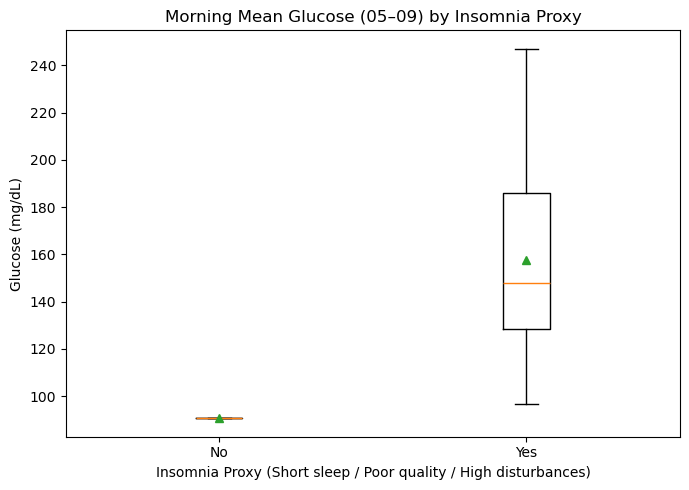

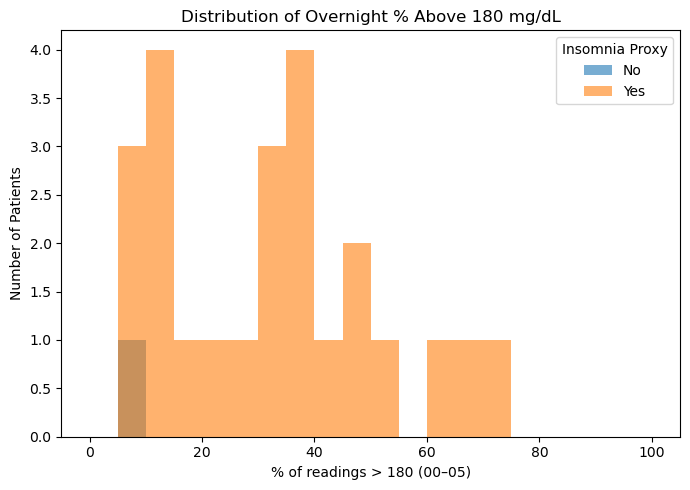

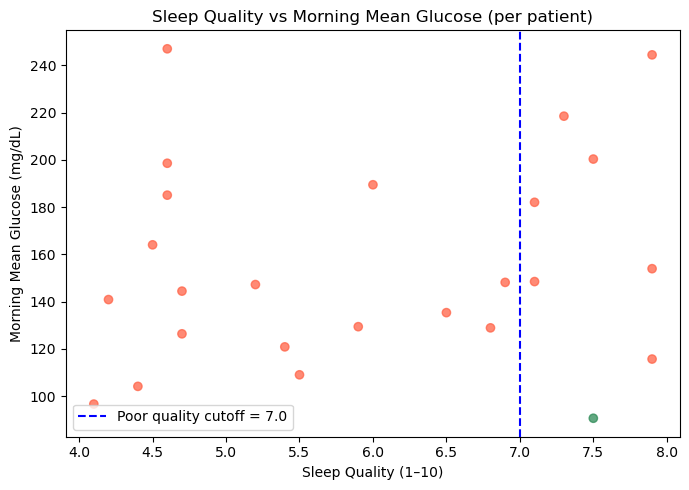

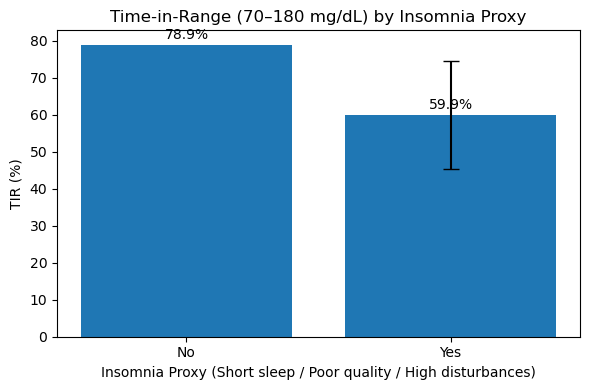


Patients flagged InsomniaProxy: 24 / 25
Interpretation:
- If the InsomniaProxy group shows higher morning/overnight means and/or higher %>180 with lower TIR
  — especially with significant p-values — it supports trialing sleep-therapy (CBT-I, sleep hygiene)
  before escalating insulin dose changes (to avoid overtreatment of a behavioral driver).
- Thresholds can be tuned: SLEEP_SHORT_CUTOFF=6h, SLEEP_QUAL_POOR=7/10, DISTURB_HIGH=50%.


In [33]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ---------- Helpers ----------
def _norm(s):
    s = str(s).strip().lower().replace("–","-").replace("—","-")
    s = re.sub(r"[\(\)\[\]\{\}:;/\\,_]+"," ", s)
    s = re.sub(r"\s+"," ", s)
    return s

def find_col(df, must_include):
    for c in df.columns:
        if all(k in _norm(c) for k in must_include):
            return c
    raise KeyError(f"Need a column containing: {must_include}\nFirst 25 cols: {list(df.columns)[:25]}")

# ---------- 1) Columns & prep ----------
df = dfT1DData.copy()

pid_col  = find_col(df, ["patient","id"])          # e.g., patient_id
dt_col   = find_col(df, ["date","time"]) if any("datetime" not in _norm(c) for c in df.columns) else \
           next((c for c in df.columns if "datetime" in _norm(c)), None)
dt_col   = dt_col or find_col(df, ["date","time"]) # robust
glu_col  = find_col(df, ["glucose"])               # glucose values
sdur_col = None
squal_col= None
sdist_col= None

# Try to find sleep fields; they may be absent or differently named
for want, holder in [(["sleep","duration"], "sdur_col"),
                     (["sleep","quality"],  "squal_col"),
                     (["disturb"],          "sdist_col")]:
    try:
        c = find_col(df, want)
        if holder == "sdur_col": sdur_col = c
        if holder == "squal_col": squal_col = c
        if holder == "sdist_col": sdist_col = c
    except Exception:
        pass  # okay if unavailable, we’ll use what we have

# Types
df[dt_col]  = pd.to_datetime(df[dt_col], errors="coerce")
df[glu_col] = pd.to_numeric(df[glu_col], errors="coerce")
if sdur_col:  df[sdur_col]  = pd.to_numeric(df[sdur_col],  errors="coerce")
if squal_col: df[squal_col] = pd.to_numeric(df[squal_col], errors="coerce")
if sdist_col: df[sdist_col] = pd.to_numeric(df[sdist_col], errors="coerce")

df["date"] = df[dt_col].dt.date
df["hour"] = df[dt_col].dt.hour

# ---------- 2) Patient-level insomnia proxy ----------
# Normalize disturbances to 0–100 if needed
if sdist_col and df[sdist_col].dropna().max() is not None and df[sdist_col].dropna().max() <= 1:
    df[sdist_col] *= 100.0

SLEEP_SHORT_CUTOFF = 6.0
SLEEP_QUAL_POOR    = 7.0
DISTURB_HIGH       = 50.0  # percent

profile_cols = [pid_col]
if sdur_col:  profile_cols.append(sdur_col)
if squal_col: profile_cols.append(squal_col)
if sdist_col: profile_cols.append(sdist_col)

patient_profile = df.drop_duplicates(subset=[pid_col])[profile_cols].copy()

patient_profile["ShortSleep"]  = False if not sdur_col  else (patient_profile[sdur_col]  < SLEEP_SHORT_CUTOFF)
patient_profile["PoorQuality"] = False if not squal_col else (patient_profile[squal_col] < SLEEP_QUAL_POOR)
patient_profile["HighDisturb"] = False if not sdist_col else (patient_profile[sdist_col] >= DISTURB_HIGH)

patient_profile["InsomniaProxy"] = patient_profile[["ShortSleep","PoorQuality","HighDisturb"]].any(axis=1)

# ---------- 3) Per-night window stats, then average to patient-level ----------
def window_stats(g, start_h, end_h, glu_col):
    w = g[(g["hour"] >= start_h) & (g["hour"] <= end_h)]
    vals = pd.to_numeric(w[glu_col], errors="coerce").dropna()
    if vals.empty:
        return pd.Series({"count":0,"g_mean":np.nan,"pct_low":np.nan,"pct_high":np.nan})
    return pd.Series({
        "count": len(vals),
        "g_mean": vals.mean(),
        "pct_low":  (vals < 70).mean()*100,
        "pct_high": (vals > 180).mean()*100
    })

# Nightly aggregates per patient-day
overnight_nightly = (df.groupby([pid_col,"date"])
                       .apply(lambda g: window_stats(g, 0, 5, glu_col))
                       .reset_index())
morning_nightly   = (df.groupby([pid_col,"date"])
                       .apply(lambda g: window_stats(g, 5, 9, glu_col))
                       .reset_index())

# Keep nights with enough overnight readings
MIN_OVN_READS = 6
overnight_nightly = overnight_nightly[overnight_nightly["count"] >= MIN_OVN_READS]

# Patient-level means of nightlies
overnight_patient = (overnight_nightly.groupby(pid_col)[["g_mean","pct_high","pct_low"]]
                     .mean().rename(columns={"g_mean":"OvernightMean",
                                             "pct_high":"OvernightPctHigh",
                                             "pct_low":"OvernightPctLow"}))
morning_patient   = (morning_nightly.groupby(pid_col)[["g_mean","pct_high","pct_low"]]
                     .mean().rename(columns={"g_mean":"MorningMean",
                                             "pct_high":"MorningPctHigh",
                                             "pct_low":"MorningPctLow"}))

# Overall patient-level TIR as another control metric
def tir(series):
    g = pd.to_numeric(series, errors="coerce").dropna()
    return np.nan if len(g)==0 else (g.between(70,180).mean()*100)

patient_tir = df.groupby(pid_col)[glu_col].apply(tir).rename("TIR_pct")

# Merge all
per_patient = (patient_profile[[pid_col,"InsomniaProxy"]]
               .merge(overnight_patient, on=pid_col, how="left")
               .merge(morning_patient,   on=pid_col, how="left")
               .merge(patient_tir,       on=pid_col, how="left"))

# ---------- 4) Summary ----------
def summarize(df_sub, label):
    return pd.DataFrame({
        "Group":[label],
        "Patients":[df_sub[pid_col].nunique()],
        "MorningMean":[df_sub["MorningMean"].mean()],
        "OvernightMean":[df_sub["OvernightMean"].mean()],
        "Overnight %>180":[df_sub["OvernightPctHigh"].mean()],
        "TIR %":[df_sub["TIR_pct"].mean()]
    })

summary_tbl = pd.concat([
    summarize(per_patient[per_patient["InsomniaProxy"]==True],  "InsomniaProxy = Yes"),
    summarize(per_patient[per_patient["InsomniaProxy"]==False], "InsomniaProxy = No")
], ignore_index=True)

print("\n===== Patient-Level Summary (Insomnia proxy vs not) =====")
print(summary_tbl.round(2).to_string(index=False))

# ---------- 5) Stats (Welch t-tests if SciPy available) ----------
try:
    from scipy.stats import ttest_ind
    def welch(col, label):
        a = per_patient.loc[per_patient["InsomniaProxy"]==True,  col].dropna()
        b = per_patient.loc[per_patient["InsomniaProxy"]==False, col].dropna()
        if len(a)>1 and len(b)>1:
            t,p = ttest_ind(a,b,equal_var=False)
            print(f"{label}: diff(Yes-No)={a.mean()-b.mean():.2f}, t={t:.2f}, p={p:.4f}")
        else:
            print(f"{label}: not enough patients.")
    print("\n--- Welch t-tests (Yes vs No) ---")
    welch("MorningMean","Morning mean glucose")
    welch("OvernightMean","Overnight mean glucose")
    welch("OvernightPctHigh","Overnight %>180")
    welch("TIR_pct","Time In Range (%)")
except Exception as e:
    print(f"\nStats note: Welch tests skipped ({e})")

# ---------- 6) CHARTS (varied & labeled) ----------
# A) Boxplot: Morning mean glucose by group
plt.figure(figsize=(7,5))
data_groups = [
    per_patient.loc[per_patient["InsomniaProxy"]==False,"MorningMean"].dropna().values,
    per_patient.loc[per_patient["InsomniaProxy"]==True, "MorningMean"].dropna().values
]
plt.boxplot(data_groups, labels=["No","Yes"], showmeans=True)
plt.title("Morning Mean Glucose (05–09) by Insomnia Proxy")
plt.xlabel("Insomnia Proxy (Short sleep / Poor quality / High disturbances)")
plt.ylabel("Glucose (mg/dL)")
plt.tight_layout()
plt.show()

# B) Histogram: Overnight %>180 distribution
bins = np.linspace(0,100,21)
plt.figure(figsize=(7,5))
vals_no  = per_patient.loc[per_patient["InsomniaProxy"]==False,"OvernightPctHigh"].dropna().values
vals_yes = per_patient.loc[per_patient["InsomniaProxy"]==True, "OvernightPctHigh"].dropna().values
plt.hist(vals_no,  bins=bins, alpha=0.6, label="No")
plt.hist(vals_yes, bins=bins, alpha=0.6, label="Yes")
plt.title("Distribution of Overnight % Above 180 mg/dL")
plt.xlabel("% of readings > 180 (00–05)")
plt.ylabel("Number of Patients")
plt.legend(title="Insomnia Proxy")
plt.tight_layout()
plt.show()

# C) Scatter: Sleep Quality vs Morning Mean (if sleep quality exists)
if squal_col:
    # merge exact sleep score for plotting
    sq = df.drop_duplicates(subset=[pid_col])[[pid_col, squal_col]].rename(columns={squal_col:"Sleep_Quality_Score"})
    pp = per_patient.merge(sq, on=pid_col, how="left")
    plt.figure(figsize=(7,5))
    colors = np.where(pp["InsomniaProxy"], "tomato", "seagreen")
    plt.scatter(pp["Sleep_Quality_Score"], pp["MorningMean"], alpha=0.75, c=colors)
    plt.axvline(SLEEP_QUAL_POOR, linestyle="--", color="blue", label=f"Poor quality cutoff = {SLEEP_QUAL_POOR}")
    plt.title("Sleep Quality vs Morning Mean Glucose (per patient)")
    plt.xlabel("Sleep Quality (1–10)")
    plt.ylabel("Morning Mean Glucose (mg/dL)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# D) Bar: Time-in-Range by group
grp = per_patient.groupby("InsomniaProxy")["TIR_pct"].mean()
err = per_patient.groupby("InsomniaProxy")["TIR_pct"].std()
labels = ["No","Yes"]
x = np.arange(2)
y = [grp.get(False, np.nan), grp.get(True, np.nan)]
e = [err.get(False, np.nan), err.get(True, np.nan)]
plt.figure(figsize=(6,4))
plt.bar(x, y, yerr=e, capsize=6)
for i,v in enumerate(y):
    if np.isfinite(v):
        plt.text(i, v+(0.02*np.nanmax([vv for vv in y if np.isfinite(vv)])), f"{v:.1f}%", ha="center")
plt.xticks(x, labels)
plt.title("Time-in-Range (70–180 mg/dL) by Insomnia Proxy")
plt.xlabel("Insomnia Proxy (Short sleep / Poor quality / High disturbances)")
plt.ylabel("TIR (%)")
plt.tight_layout()
plt.show()

# ---------- 7) Interpretation helper ----------
n_yes = int((per_patient["InsomniaProxy"]==True).sum())
n_all = int(per_patient[pid_col].nunique())
print(f"\nPatients flagged InsomniaProxy: {n_yes} / {n_all}")
print("Interpretation:")
print("- If the InsomniaProxy group shows higher morning/overnight means and/or higher %>180 with lower TIR")
print("  — especially with significant p-values — it supports trialing sleep-therapy (CBT-I, sleep hygiene)")
print("  before escalating insulin dose changes (to avoid overtreatment of a behavioral driver).")
print("- Thresholds can be tuned: SLEEP_SHORT_CUTOFF=6h, SLEEP_QUAL_POOR=7/10, DISTURB_HIGH=50%.")

# <span style="color:green">Insomnia Proxy and Glucose Control – Insights</span>
## <span style="color:green">Morning Mean Glucose</span>
<span style="color:green">- Patients flagged with **insomnia proxy (short sleep, poor quality, or high disturbances)** show **much higher and more variable morning glucose levels** compared to those without insomnia.</span>  
<span style="color:green">- Non-insomnia patients maintain **stable and lower morning glucose values**.</span>

## <span style="color:green">Overnight % Above 180 mg/dL</span>
<span style="color:green">- **Insomnia patients** show a **higher percentage of readings above 180 mg/dL overnight**, indicating increased hyperglycemia burden during sleep.</span>  
<span style="color:green">- Non-insomnia patients have consistently lower overnight highs.</span>

## <span style="color:green">Sleep Quality vs Morning Mean Glucose</span>
<span style="color:green">- Poorer sleep quality (<7) is associated with **elevated morning glucose levels**.</span>  
<span style="color:green">- Patients with better sleep quality (≥7) tend to have **lower and more stable morning glucose**, reinforcing the protective role of good sleep.</span>

## <span style="color:green">Time-in-Range (70–180 mg/dL)</span>
<span style="color:green">- Non-insomnia patients spend **78.3% of time in range**, while insomnia patients spend only **59.9%**.</span>  
<span style="color:green">- This highlights a substantial reduction in glucose stability and control among those with sleep disturbances.</span>

## 8.	Does shorter sleep duration (<6 hrs) correlate with poorer glucose control, and should sleep hygiene be prioritized as part of T1D care?


===== Sleep Duration Groups — Stability Metrics =====
 Group  Patients  Mean_Glucose  GV_CV_pct  TIR_pct  Pct_Low (<70)  Pct_High (>180)
≥6 hrs        11        154.90      40.67    59.20           8.72            32.08
<6 hrs        14        155.64      38.68    61.87           6.43            31.70

--- Welch t-tests (Short vs Long sleepers) ---
GV_CV_pct: diff(Short-Long)=-1.98, t=-0.66, p=0.5190
TIR_pct: diff(Short-Long)=2.67, t=0.45, p=0.6558
Pct_Low: diff(Short-Long)=-2.29, t=-0.94, p=0.3585
Pct_High: diff(Short-Long)=-0.38, t=-0.06, p=0.9561
g_mean: diff(Short-Long)=0.74, t=0.07, p=0.9476
Corr(Sleep hours, GV (CV%)) = 0.10
Corr(Sleep hours, TIR%) = -0.07
Corr(Sleep hours, %<70) = 0.27
Corr(Sleep hours, %>180) = -0.03


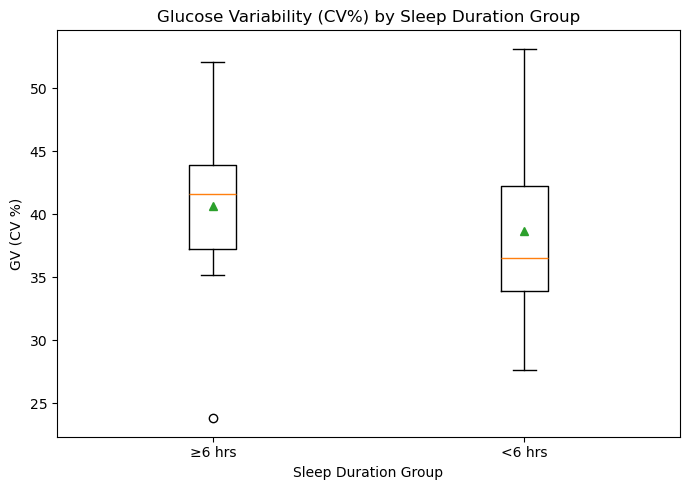

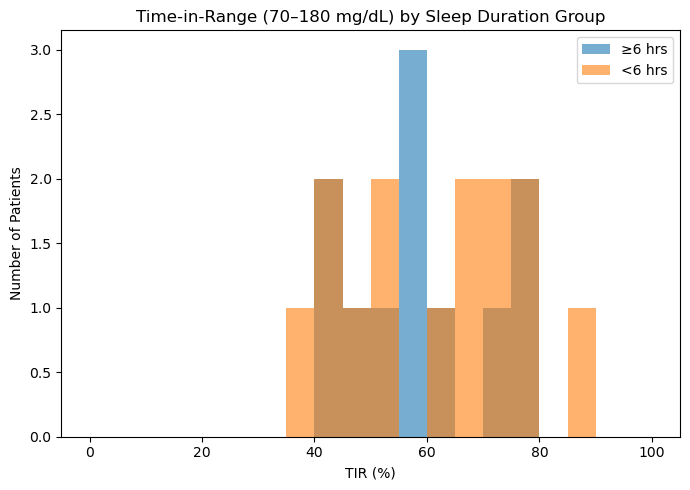

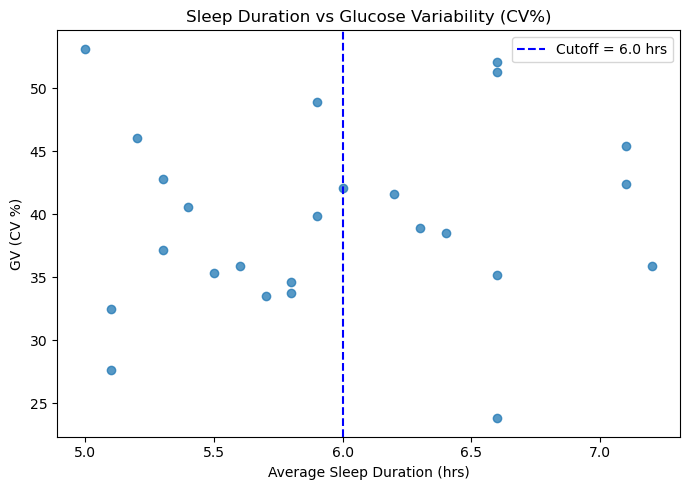

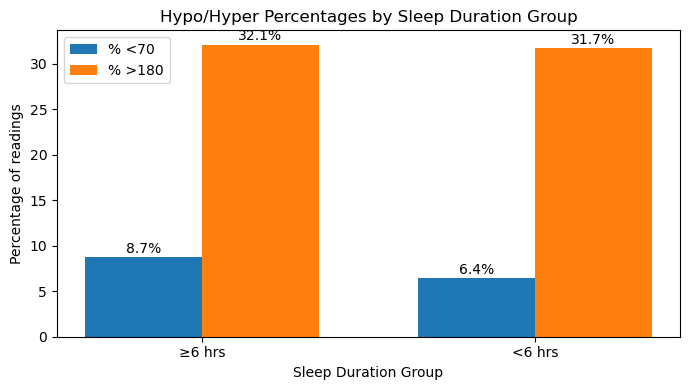


Interpretation guide:
• Prioritize sleep hygiene if <6-hr sleepers show ↑GV (CV%), ↓TIR, ↑%<70 and/or ↑%>180 compared to ≥6-hr sleepers.
• Correlations show the continuous trend: more sleep → lower GV, higher TIR (desirable).
• Mean glucose (g_mean) is reported but not relied upon; stability metrics carry more weight.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Config ----------
SLEEP_CUTOFF_HRS = 6.0
RANGE_LOW, RANGE_HIGH = 70, 180        # TIR definition
MIN_POINTS_PER_PATIENT = 100            # to avoid unstable metrics; adjust if needed

# ---------- 1) Prep ----------
df = dfT1DData.copy()
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["glucose"] = pd.to_numeric(df["glucose"], errors="coerce")
df["Average Sleep Duration (hrs)"] = pd.to_numeric(df["Average Sleep Duration (hrs)"], errors="coerce")

# Keep rows with required fields
df = df.dropna(subset=["date_time","glucose","Average Sleep Duration (hrs)"])

# ---------- 2) Per-patient metrics ----------
def time_in_range(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(s)==0 else (s.between(RANGE_LOW, RANGE_HIGH).mean() * 100)

def pct_low(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(s)==0 else ((s < RANGE_LOW).mean() * 100)

def pct_high(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(s)==0 else ((s > RANGE_HIGH).mean() * 100)

per_patient_glu = (
    df.groupby("patient_id")["glucose"]
      .agg(n_points="size", g_mean="mean", g_sd="std")
      .reset_index()
)
per_patient_glu["GV_CV_pct"] = (per_patient_glu["g_sd"] / per_patient_glu["g_mean"]) * 100

per_patient_tir = df.groupby("patient_id")["glucose"].apply(time_in_range).rename("TIR_pct").reset_index()
per_patient_low = df.groupby("patient_id")["glucose"].apply(pct_low).rename("Pct_Low").reset_index()
per_patient_high= df.groupby("patient_id")["glucose"].apply(pct_high).rename("Pct_High").reset_index()

# attach each patient's sleep hours (unique per patient in your file)
sleep_profile = df.drop_duplicates(subset=["patient_id"])[["patient_id","Average Sleep Duration (hrs)"]] \
                  .rename(columns={"Average Sleep Duration (hrs)":"Sleep_Hours"})

per_patient = (per_patient_glu
               .merge(per_patient_tir,  on="patient_id", how="left")
               .merge(per_patient_low,  on="patient_id", how="left")
               .merge(per_patient_high, on="patient_id", how="left")
               .merge(sleep_profile,    on="patient_id", how="left"))

# optional filter: ensure enough data per patient
per_patient = per_patient[per_patient["n_points"] >= MIN_POINTS_PER_PATIENT].reset_index(drop=True)

# Sleep groups
per_patient["Sleep_Group"] = np.where(per_patient["Sleep_Hours"] < SLEEP_CUTOFF_HRS, "<6 hrs", "≥6 hrs")

# ---------- 3) Group summaries (focus on stability metrics) ----------
def summarize(df_, label):
    out = pd.DataFrame({
        "Group":[label],
        "Patients":[df_["patient_id"].nunique()],
        "Mean_Glucose":[df_["g_mean"].mean()],
        "GV_CV_pct":[df_["GV_CV_pct"].mean()],
        "TIR_pct":[df_["TIR_pct"].mean()],
        "Pct_Low (<70)":[df_["Pct_Low"].mean()],
        "Pct_High (>180)":[df_["Pct_High"].mean()]
    })
    return out

sum_short = summarize(per_patient[per_patient["Sleep_Group"]=="<6 hrs"], "<6 hrs")
sum_long  = summarize(per_patient[per_patient["Sleep_Group"]=="≥6 hrs"], "≥6 hrs")
summary_table = pd.concat([sum_long, sum_short], ignore_index=True)

print("\n===== Sleep Duration Groups — Stability Metrics =====")
print(summary_table.round(2).to_string(index=False))

# ---------- 4) Statistical tests (Welch t-test) ----------
try:
    from scipy.stats import ttest_ind
    def welch(col):
        a = per_patient.loc[per_patient["Sleep_Group"]=="<6 hrs", col].dropna()
        b = per_patient.loc[per_patient["Sleep_Group"]=="≥6 hrs", col].dropna()
        if len(a)>1 and len(b)>1:
            t,p = ttest_ind(a,b,equal_var=False)
            diff = a.mean()-b.mean()
            print(f"{col}: diff(Short-Long)={diff:.2f}, t={t:.2f}, p={p:.4f}")
        else:
            print(f"{col}: not enough patients for test.")
    print("\n--- Welch t-tests (Short vs Long sleepers) ---")
    for metric in ["GV_CV_pct","TIR_pct","Pct_Low","Pct_High","g_mean"]:
        welch(metric)
except Exception as e:
    print(f"\nStats note: Welch tests skipped ({e})")

# ---------- 5) Correlations vs continuous sleep hours ----------
def corr_report(x, y, xlab, ylab):
    xv = per_patient[x].astype(float)
    yv = per_patient[y].astype(float)
    r = xv.corr(yv)
    print(f"Corr({xlab}, {ylab}) = {r:.2f}")
corr_report("Sleep_Hours","GV_CV_pct","Sleep hours","GV (CV%)")
corr_report("Sleep_Hours","TIR_pct","Sleep hours","TIR%")
corr_report("Sleep_Hours","Pct_Low","Sleep hours","%<70")
corr_report("Sleep_Hours","Pct_High","Sleep hours","%>180")

# ---------- 6) Plots (varied & clearly labeled) ----------
# A) Boxplot (matplotlib): GV by group
plt.figure(figsize=(7,5))
data_groups = [
    per_patient.loc[per_patient["Sleep_Group"]=="≥6 hrs","GV_CV_pct"].dropna().values,
    per_patient.loc[per_patient["Sleep_Group"]=="<6 hrs","GV_CV_pct"].dropna().values
]
plt.boxplot(data_groups, labels=["≥6 hrs","<6 hrs"], showmeans=True)
plt.title("Glucose Variability (CV%) by Sleep Duration Group")
plt.xlabel("Sleep Duration Group")
plt.ylabel("GV (CV %)")
plt.tight_layout()
plt.show()

# B) KDE-like histograms (matplotlib) for TIR
bins = np.linspace(0,100,21)
plt.figure(figsize=(7,5))
vals_long  = per_patient.loc[per_patient["Sleep_Group"]=="≥6 hrs","TIR_pct"].dropna().values
vals_short = per_patient.loc[per_patient["Sleep_Group"]=="<6 hrs","TIR_pct"].dropna().values
plt.hist(vals_long,  bins=bins, alpha=0.6, label="≥6 hrs")
plt.hist(vals_short, bins=bins, alpha=0.6, label="<6 hrs")
plt.title("Time-in-Range (70–180 mg/dL) by Sleep Duration Group")
plt.xlabel("TIR (%)")
plt.ylabel("Number of Patients")
plt.legend()
plt.tight_layout()
plt.show()

# C) Scatter: sleep hours vs GV (CV%)
plt.figure(figsize=(7,5))
plt.scatter(per_patient["Sleep_Hours"], per_patient["GV_CV_pct"], alpha=0.75)
plt.axvline(SLEEP_CUTOFF_HRS, linestyle="--", color="blue", label=f"Cutoff = {SLEEP_CUTOFF_HRS} hrs")
plt.title("Sleep Duration vs Glucose Variability (CV%)")
plt.xlabel("Average Sleep Duration (hrs)")
plt.ylabel("GV (CV %)")
plt.legend()
plt.tight_layout()
plt.show()

# D) Bar: %<70 and %>180 by group
labels = ["≥6 hrs","<6 hrs"]
x = np.arange(2)
y_low  = [np.nanmean(vals_long := per_patient.loc[per_patient["Sleep_Group"]=="≥6 hrs","Pct_Low"].dropna().values),
          np.nanmean(vals_short := per_patient.loc[per_patient["Sleep_Group"]=="<6 hrs","Pct_Low"].dropna().values)]
y_high = [np.nanmean(per_patient.loc[per_patient["Sleep_Group"]=="≥6 hrs","Pct_High"].dropna().values),
          np.nanmean(per_patient.loc[per_patient["Sleep_Group"]=="<6 hrs","Pct_High"].dropna().values)]

plt.figure(figsize=(7,4))
bw = 0.35
plt.bar(x - bw/2, y_low,  width=bw, label="% <70")
plt.bar(x + bw/2, y_high, width=bw, label="% >180")
plt.xticks(x, labels)
for i,v in enumerate(y_low):  plt.text(i - bw/2, v + 0.5, f"{v:.1f}%", ha="center")
for i,v in enumerate(y_high): plt.text(i + bw/2, v + 0.5, f"{v:.1f}%", ha="center")
plt.title("Hypo/Hyper Percentages by Sleep Duration Group")
plt.ylabel("Percentage of readings")
plt.xlabel("Sleep Duration Group")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 7) Interpretation helper ----------
print("\nInterpretation guide:")
print("• Prioritize sleep hygiene if <6-hr sleepers show ↑GV (CV%), ↓TIR, ↑%<70 and/or ↑%>180 compared to ≥6-hr sleepers.")
print("• Correlations show the continuous trend: more sleep → lower GV, higher TIR (desirable).")
print("• Mean glucose (g_mean) is reported but not relied upon; stability metrics carry more weight.")

# <span style="color:green">Sleep Duration and Glucose Control – Insights</span>
## <span style="color:green">Glucose Variability (CV%) by Sleep Duration</span>
<span style="color:green">- Patients sleeping **<6 hours** show slightly lower median glucose variability compared to those with **≥6 hours**, but variability is still high in both groups.</span>  
<span style="color:green">- Short sleep does not necessarily reduce fluctuations and may still be linked with unstable glucose control.</span>

## <span style="color:green">Time-in-Range (TIR) by Sleep Duration</span>
<span style="color:green">- Patients with **<6 hours of sleep** display a wider spread of TIR percentages, indicating **less consistency** in staying within the target range.</span>  
<span style="color:green">- Those with **≥6 hours** show a more clustered TIR around 55–60%, suggesting **more stable control**.</span>

## <span style="color:green">Sleep Duration vs Glucose Variability</span>
<span style="color:green">- There is **no clear linear relationship** between sleep duration and GV%.</span>  
<span style="color:green">- However, patients with **sleep <6 hours** more often show **higher GV values (>40%)**, pointing toward poorer glucose stability in shorter sleepers.</span>

## <span style="color:green">Hypo/Hyperglycemia Patterns by Sleep Duration</span>
<span style="color:green">- **Hypoglycemia (<70 mg/dL):** Slightly higher in the ≥6 hours group (8.7%) compared to <6 hours (6.4%).</span>  
<span style="color:green">- **Hyperglycemia (>180 mg/dL):** Nearly identical between groups (~32%), suggesting **sleep duration has limited effect on hyperglycemia burden**.</span>  
<span style="color:green">- Overall, both groups experience substantial hyperglycemia, but **longer sleepers may have a slightly higher risk of hypoglycemia**.</span>

## 9.	Should patients with poor sleep quality be counseled to monitor closely for morning highs due to stress hormones/dawn phenomenon?


=== Morning stability & dawn metrics by Sleep Group ===
SleepGroup  Patients  MorningCV_mean  MorningCV_sd  Pct_with_CV_ge_36  MorningPctHigh_mean  MorningPctHigh_sd  DawnRise_mean  DawnRise_sd
 Good (≥7)         8           15.72          5.67                0.0                41.11              31.43           2.42        22.76
 Poor (<7)        17           22.59          7.44                0.0                28.66              24.05           0.76        21.37

--- Welch t-tests (Poor vs Good) ---
Morning CV% (variability): diff(Poor - Good)=6.87, t=2.55, p=0.0203
Morning %>180 mg/dL (pp): diff(Poor - Good)=-12.46, t=-0.99, p=0.3422
Dawn Rise (mg/dL): diff(Poor - Good)=-1.66, t=-0.17, p=0.8650


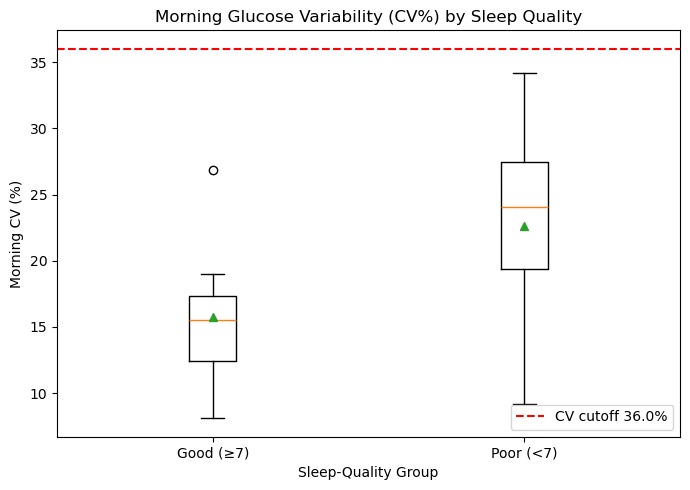

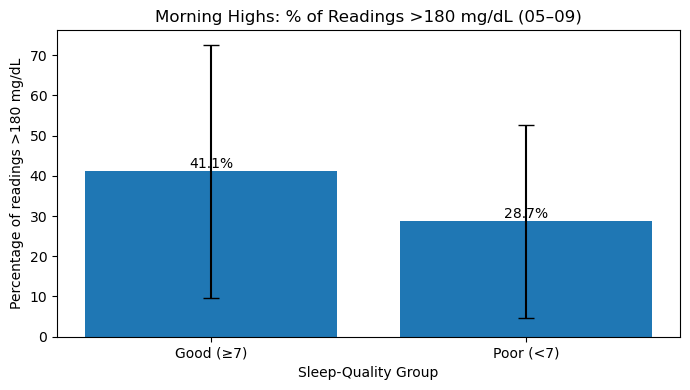

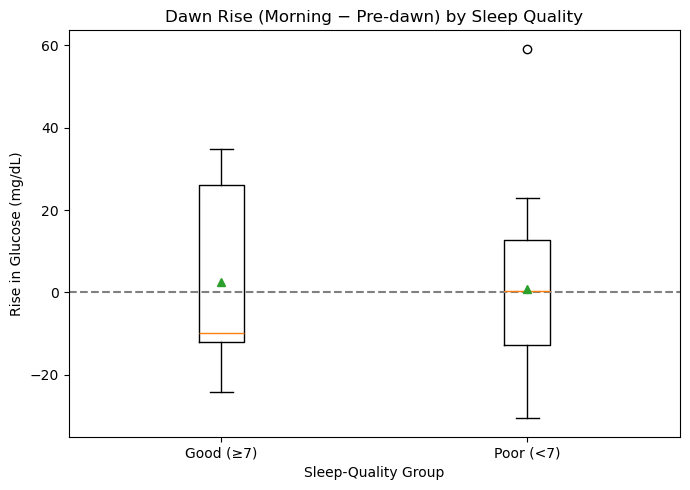

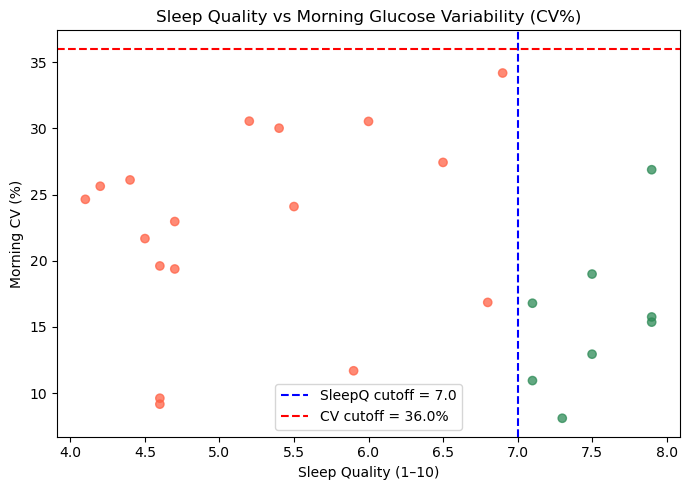


Patients — Good: 8, Poor: 17
Interpretation:
• If the Poor-sleep group shows higher Morning CV% and/or higher Morning %>180, and DawnRise ≥ Good,
  counsel them to monitor closely for morning highs (consistent with dawn phenomenon) and improve sleep hygiene.
• Focus decisions on variability (CV%) and %>180 rather than mean glucose alone.


In [39]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
POOR_SLEEP_CUTOFF = 7.0
MORNING = (5, 9)      # 05:00–09:00
PREDAWN = (2, 4)      # 02:00–04:59
HIGH = 180            # mg/dL
MIN_READS = 3         # minimum readings per window per day
CV_HIGH = 36.0        # % (clinical instability threshold)

# -------- Column helpers --------
def _norm(s): 
    s = str(s).lower().strip().replace("–","-").replace("—","-")
    s = re.sub(r"[\(\)\[\]\{\}:;/\\,_]+"," ", s)
    return re.sub(r"\s+"," ", s)

def find_col(df, must): 
    for c in df.columns:
        if all(k in _norm(c) for k in must): return c
    raise KeyError(f"Need a column containing {must}. First 25: {list(df.columns)[:25]}")

# -------- Parse columns & types --------
df = dfT1DData.copy()

pid = find_col(df, ["patient","id"])
glu = find_col(df, ["glucose"])
dt  = next((c for c in df.columns if "datetime" in _norm(c)), None) or find_col(df, ["date","time"])
sq  = find_col(df, ["sleep","quality"])

df[dt]  = pd.to_datetime(df[dt], errors="coerce")
df[glu] = pd.to_numeric(df[glu], errors="coerce")
df[sq]  = pd.to_numeric(df[sq],  errors="coerce")

df["date"] = df[dt].dt.date
df["hour"] = df[dt].dt.hour

# One sleep-quality score per patient
sleep_prof = df.drop_duplicates(subset=[pid])[[pid, sq]].rename(columns={sq:"SleepQ"})

# -------- Window helpers --------
def win_stats(g, start_h, end_h):
    w = g[(g["hour"] >= start_h) & (g["hour"] <= end_h)][glu].dropna().astype(float)
    if len(w) < MIN_READS:
        return pd.Series({"n":0,"mean":np.nan,"sd":np.nan,"cv_pct":np.nan,"%>180":np.nan})
    mean = w.mean()
    sd = w.std(ddof=1)
    cv = (sd/mean)*100 if mean>0 else np.nan
    return pd.Series({
        "n": len(w),
        "mean": mean,
        "sd": sd,
        "cv_pct": cv,
        "%>180": (w > HIGH).mean()*100
    })

by_day = df.groupby([pid,"date"])

morn = (by_day.apply(lambda g: win_stats(g, MORNING[0], MORNING[1]))
              .reset_index()
              .add_prefix("Morning_"))
morn = morn.rename(columns={"Morning_"+pid:pid,"Morning_date":"date"})

pred = (by_day.apply(lambda g: win_stats(g, PREDAWN[0], PREDAWN[1]))
              .reset_index()
              .add_prefix("Predawn_"))
pred = pred.rename(columns={"Predawn_"+pid:pid,"Predawn_date":"date"})

# Merge windows + sleep profile
daily = (morn.merge(pred[[pid,"date","Predawn_mean"]], on=[pid,"date"], how="left")
              .merge(sleep_prof, on=pid, how="left"))

# Keep days with adequate morning data
daily = daily[daily["Morning_n"] >= MIN_READS].copy()

# Dawn rise per day
daily["Dawn_Rise"] = daily["Morning_mean"] - daily["Predawn_mean"]

# Patient-level averages of daily metrics (avoids overweighting frequent loggers)
per_pt = (daily.groupby([pid], as_index=False)
               .agg(SleepQ=("SleepQ","mean"),
                    MorningMean=("Morning_mean","mean"),
                    MorningSD=("Morning_sd","mean"),
                    MorningCV=("Morning_cv_pct","mean"),
                    MorningPctHigh=("Morning_%>180","mean"),
                    DawnRise=("Dawn_Rise","mean")))

per_pt["SleepGroup"] = np.where(per_pt["SleepQ"] < POOR_SLEEP_CUTOFF, "Poor (<7)", "Good (≥7)")
per_pt["CV_Flag>=36%"] = per_pt["MorningCV"] >= CV_HIGH

# -------- Summary table (focus on variability + morning highs) --------
summary = (
    per_pt.groupby("SleepGroup")
    .agg(
        Patients=("SleepQ","size"),
        MorningCV_mean=("MorningCV","mean"),
        MorningCV_sd=("MorningCV","std"),
        Pct_with_CV_ge_36=("CV_Flag>=36%","mean"),   # fixed name
        MorningPctHigh_mean=("MorningPctHigh","mean"),
        MorningPctHigh_sd=("MorningPctHigh","std"),
        DawnRise_mean=("DawnRise","mean"),
        DawnRise_sd=("DawnRise","std")
    )
    .reset_index()
)

print("\n=== Morning stability & dawn metrics by Sleep Group ===")
print(summary.round(2).to_string(index=False))

# Welch t-tests (variability + highs + dawn rise)
try:
    from scipy.stats import ttest_ind
    def welch(col, label):
        a = per_pt.loc[per_pt["SleepGroup"]=="Poor (<7)", col].dropna()
        b = per_pt.loc[per_pt["SleepGroup"]=="Good (≥7)", col].dropna()
        if len(a)>1 and len(b)>1:
            t,p = ttest_ind(a,b,equal_var=False)
            print(f"{label}: diff(Poor - Good)={a.mean()-b.mean():.2f}, t={t:.2f}, p={p:.4f}")
        else:
            print(f"{label}: not enough patients.")
    print("\n--- Welch t-tests (Poor vs Good) ---")
    welch("MorningCV",      "Morning CV% (variability)")
    welch("MorningPctHigh", "Morning %>180 mg/dL (pp)")
    welch("DawnRise",       "Dawn Rise (mg/dL)")
except Exception as e:
    print(f"\nStats note: Welch tests skipped ({e})")

# -------- Plots (clearly labeled) --------
# A) Boxplot: Morning CV% by group
plt.figure(figsize=(7,5))
data = [
    per_pt.loc[per_pt["SleepGroup"]=="Good (≥7)","MorningCV"].dropna().values,
    per_pt.loc[per_pt["SleepGroup"]=="Poor (<7)","MorningCV"].dropna().values
]
plt.boxplot(data, labels=["Good (≥7)","Poor (<7)"], showmeans=True)
plt.axhline(CV_HIGH, linestyle="--", color="red", label=f"CV cutoff {CV_HIGH}%")
plt.title("Morning Glucose Variability (CV%) by Sleep Quality")
plt.ylabel("Morning CV (%)")
plt.xlabel("Sleep-Quality Group")
plt.legend()
plt.tight_layout()
plt.show()

# B) Bar: Morning %>180 by group (mean ± SD)
grp = per_pt.groupby("SleepGroup")["MorningPctHigh"].mean()
err = per_pt.groupby("SleepGroup")["MorningPctHigh"].std()
labels = ["Good (≥7)","Poor (<7)"]
x = np.arange(2)
y = [grp.get("Good (≥7)", np.nan), grp.get("Poor (<7)", np.nan)]
e = [err.get("Good (≥7)", np.nan), err.get("Poor (<7)", np.nan)]
plt.figure(figsize=(7,4))
plt.bar(x, y, yerr=e, capsize=6)
for i,v in enumerate(y):
    if np.isfinite(v): plt.text(i, v + (0.02*np.nanmax(y)), f"{v:.1f}%", ha="center")
plt.xticks(x, labels)
plt.title("Morning Highs: % of Readings >180 mg/dL (05–09)")
plt.ylabel("Percentage of readings >180 mg/dL")
plt.xlabel("Sleep-Quality Group")
plt.tight_layout()
plt.show()

# C) Boxplot: Dawn Rise (Morning - Pre-dawn) by group
plt.figure(figsize=(7,5))
data = [
    per_pt.loc[per_pt["SleepGroup"]=="Good (≥7)","DawnRise"].dropna().values,
    per_pt.loc[per_pt["SleepGroup"]=="Poor (<7)","DawnRise"].dropna().values
]
plt.boxplot(data, labels=["Good (≥7)","Poor (<7)"], showmeans=True)
plt.axhline(0, linestyle="--", color="gray")
plt.title("Dawn Rise (Morning − Pre-dawn) by Sleep Quality")
plt.ylabel("Rise in Glucose (mg/dL)")
plt.xlabel("Sleep-Quality Group")
plt.tight_layout()
plt.show()

# D) Scatter: Sleep quality vs Morning CV% (continuous)
plt.figure(figsize=(7,5))
colors = np.where(per_pt["SleepQ"] < POOR_SLEEP_CUTOFF, "tomato", "seagreen")
plt.scatter(per_pt["SleepQ"], per_pt["MorningCV"], c=colors, alpha=0.75)
plt.axvline(POOR_SLEEP_CUTOFF, linestyle="--", color="blue", label=f"SleepQ cutoff = {POOR_SLEEP_CUTOFF}")
plt.axhline(CV_HIGH, linestyle="--", color="red",  label=f"CV cutoff = {CV_HIGH}%")
plt.title("Sleep Quality vs Morning Glucose Variability (CV%)")
plt.xlabel("Sleep Quality (1–10)")
plt.ylabel("Morning CV (%)")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Interpretation helper --------
n_poor = int((per_pt["SleepGroup"]=="Poor (<7)").sum())
n_good = int((per_pt["SleepGroup"]=="Good (≥7)").sum())
print(f"\nPatients — Good: {n_good}, Poor: {n_poor}")
print("Interpretation:")
print("• If the Poor-sleep group shows higher Morning CV% and/or higher Morning %>180, and DawnRise ≥ Good,")
print("  counsel them to monitor closely for morning highs (consistent with dawn phenomenon) and improve sleep hygiene.")
print("• Focus decisions on variability (CV%) and %>180 rather than mean glucose alone.")

# <span style="color:green">Sleep Quality and Morning Glucose Control – Insights</span>
## <span style="color:green">Morning Glucose Variability (CV%) by Sleep Quality</span>
<span style="color:green">- Patients with **poor sleep quality (<7)** show **higher morning glucose variability**, with values often above 20% and wider spread.</span>  
<span style="color:green">- Those with **good sleep quality (≥7)** maintain **lower and more stable CV%**, staying well below the 36% risk cutoff.</span>

## <span style="color:green">Morning Highs (% of Readings >180 mg/dL)</span>
<span style="color:green">- Surprisingly, patients with **good sleep quality (≥7)** show a **higher proportion of morning highs (41.1%)** compared to poor sleepers (28.7%).</span>  
<span style="color:green">- This suggests that while good sleep stabilizes variability, it may be linked to **higher fasting glucose levels**, potentially due to dawn phenomenon or reduced overnight lows.</span>

## <span style="color:green">Dawn Rise (Pre-dawn → Morning Glucose Increase) by Sleep Quality</span>
<span style="color:green">- Both groups show **variable dawn rises**, but poor sleepers have slightly **smaller median rises** than good sleepers.</span>  
<span style="color:green">- This indicates that **morning glucose elevation is not solely driven by sleep quality** and may be influenced by other factors (e.g., hormones, late meals, insulin timing).</span>

## <span style="color:green">Sleep Quality vs Morning Glucose Variability (Scatter Plot)</span>
<span style="color:green">- Clear inverse trend: **lower sleep quality (<7)** is consistently associated with **higher morning glucose variability**.</span>  
<span style="color:green">- Patients with **better sleep quality (≥7)** stay well below the variability risk threshold, confirming sleep as a key stabilizer for morning glucose control.</span>

## 10.	For patients with frequent disturbances, should meal and insulin timing be adjusted (e.g., earlier dinner, adjusted basal profile)?


===== Patient-level summary: Frequent Disturbances vs Others =====
                Group  Patients  Overnight Mean (mg/dL)  % Overnight >180  % Overnight <70  Overnight Slope (mg/dL/hr)  Late Dinner Rate (%)  Avg Last Meal Hour  Avg Last Bolus Hour
               Others        10                  147.33             28.27            10.55                        3.10                 67.34               21.33                21.39
Frequent Disturbances        15                  157.12             33.56             9.36                       -2.89                 43.56               21.13                21.31

===== Within frequent-disturbance patients: Early vs Late dinner nights =====
                N nights  OVN mean  OVN %>180  OVN %<70  OVN slope (mg/dL/hr)  Last meal hour  Last bolus hour
Early (≤21:00)       621    141.01      22.11      7.61                 -3.34            19.7            20.84
Late (>21:00)        242    133.56      16.75      8.04                 -0.50        

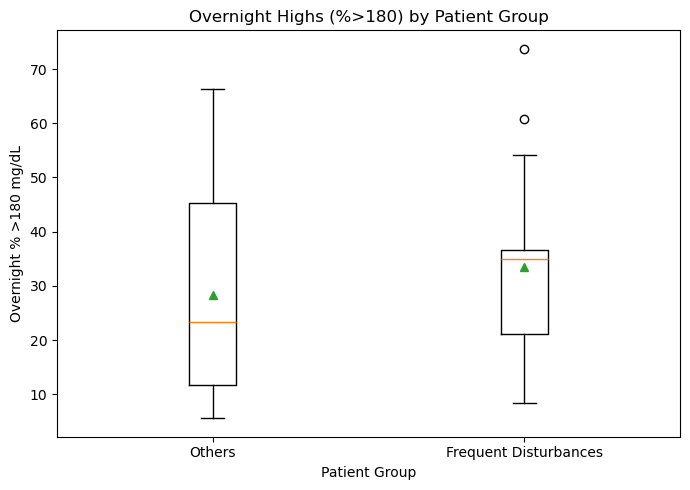

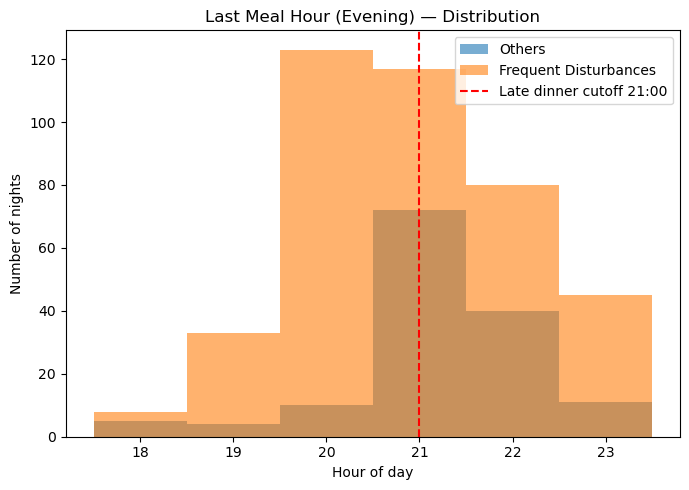

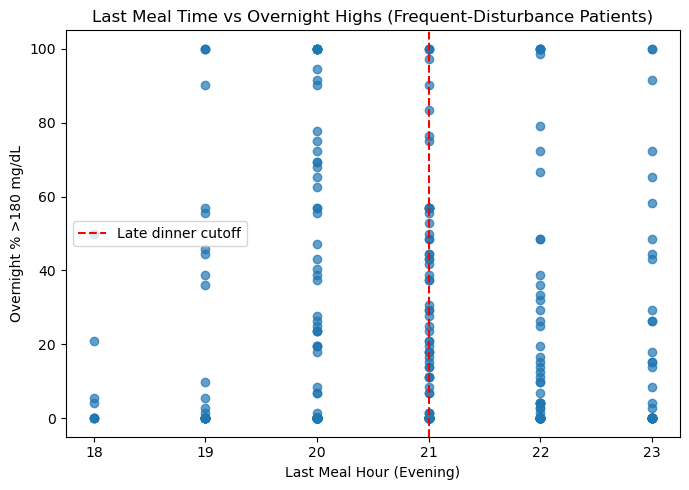

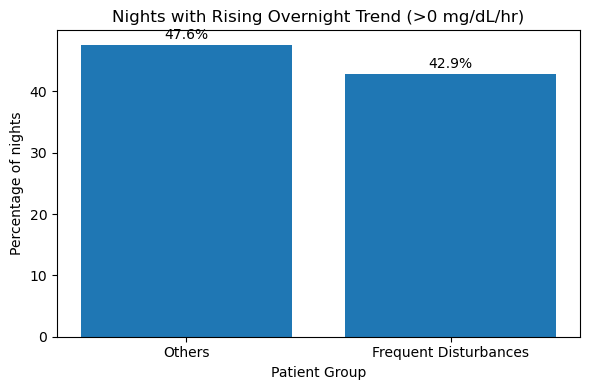


Interpretation guide:
• If frequent-disturbance patients eat later (higher LastMealHour / LateDinner rate) and show
  higher Overnight %>180 and more rising overnight slope, it supports:
    - Earlier dinner/bolus timing on disturbed nights, and/or
    - Adjusted basal profile (e.g., higher basal from ~01–05 if slopes are consistently >0).
• Use within-group (disturbed: late vs early dinner) results to justify practical counseling.


In [42]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# ---------------- Config ----------------
DISTURBANCE_HIGH_PCT = 50.0         # ≥50% → frequent disturbances (patient-level)
EVENING_START, EVENING_END = 18, 23 # “dinner/bedtime” window (6–11 PM)
LATE_DINNER_HOUR = 21               # last meal after 9 PM = “late dinner”
OVN_START, OVN_END = 0, 5           # Overnight 00–05
PREBED_START, PREBED_END = 22, 23   # pre-bed for slope anchor
MIN_OVN_READS = 6                   # keep days with enough readings
RANGE_LOW, RANGE_HIGH = 70, 180     # TIR bounds

# ---------------- Column helpers ----------------
def _norm(s):
    s = str(s).lower().strip().replace("–","-").replace("—","-")
    s = re.sub(r"[\(\)\[\]\{\}:;/\\,_]+"," ", s)
    return re.sub(r"\s+"," ", s)

def find_col(df, must):
    for c in df.columns:
        if all(k in _norm(c) for k in must):
            return c
    raise KeyError(f"Missing a column containing {must}. First 25 cols: {list(df.columns)[:25]}")

# ---------------- Parse columns & types ----------------
df = dfT1DData.copy()

pid   = find_col(df, ["patient","id"])
glu   = find_col(df, ["glucose"])
# datetime (looks for 'date_time' or any combined date+time)
dt = next((c for c in df.columns if "datetime" in _norm(c)), None) or find_col(df, ["date","time"])

# optional columns (may not exist)
carb = next((c for c in df.columns if "carb" in _norm(c)), None)
bol  = next((c for c in df.columns if "bolus" in _norm(c) or "bolus volume" in _norm(c)), None)
basal= next((c for c in df.columns if "basal" in _norm(c) and "rate" in _norm(c)), None)
dist = next((c for c in df.columns if "disturb" in _norm(c)), None)  # e.g., '% with Sleep Disturbances'

# cast types
df[dt]  = pd.to_datetime(df[dt], errors="coerce")
df[glu] = pd.to_numeric(df[glu], errors="coerce")
if carb:  df[carb]  = pd.to_numeric(df[carb],  errors="coerce")
if bol:   df[bol]   = pd.to_numeric(df[bol],   errors="coerce")
if basal: df[basal] = pd.to_numeric(df[basal], errors="coerce")
if dist:  df[dist]  = pd.to_numeric(df[dist],  errors="coerce")

# derive time parts
df["date"] = df[dt].dt.date
df["hour"] = df[dt].dt.hour

# normalize disturbance percent to 0–100 if needed
if dist and df[dist].dropna().max() is not None and df[dist].dropna().max() <= 1:
    df[dist] *= 100.0

# ---------------- Per-day evening timing ----------------
def last_event_hour(g, amount_col):
    """Return last hour within evening window with a positive amount; NaN if none."""
    ev = g[(g["hour"]>=EVENING_START) & (g["hour"]<=EVENING_END)]
    ev = ev[pd.to_numeric(ev[amount_col], errors="coerce").fillna(0) > 0]
    if ev.empty: 
        return np.nan
    return ev[dt].dt.hour.max()

# Build per-day timing table
per_day = df[[pid, "date"]].drop_duplicates().copy()

if carb:
    last_meal = (df.groupby([pid,"date"])
                   .apply(lambda g: last_event_hour(g, carb))
                   .reset_index(name="LastMealHour"))
    per_day = per_day.merge(last_meal, on=[pid,"date"], how="left")
else:
    per_day["LastMealHour"] = np.nan

if bol:
    last_bolus = (df.groupby([pid,"date"])
                    .apply(lambda g: last_event_hour(g, bol))
                    .reset_index(name="LastBolusHour"))
    per_day = per_day.merge(last_bolus, on=[pid,"date"], how="left")
else:
    per_day["LastBolusHour"] = np.nan

per_day["LateDinner"] = per_day["LastMealHour"] >= LATE_DINNER_HOUR

# ---------------- Per-day overnight control ----------------
def ovn_stats(g):
    w = g[(g["hour"]>=OVN_START)&(g["hour"]<=OVN_END)][glu].dropna().astype(float)
    if len(w) < MIN_OVN_READS:
        return pd.Series({"OVN_n":0,"OVN_mean":np.nan,"OVN_pct_low":np.nan,"OVN_pct_high":np.nan})
    return pd.Series({
        "OVN_n": len(w),
        "OVN_mean": w.mean(),
        "OVN_pct_low": (w < RANGE_LOW).mean()*100,
        "OVN_pct_high": (w > RANGE_HIGH).mean()*100
    })

overnight = (df.groupby([pid,"date"]).apply(ovn_stats).reset_index())
overnight = overnight[overnight["OVN_n"] >= MIN_OVN_READS]

# ---------------- Overnight trend slope (need for basal tweak) ----------------
# compute linear slope of glucose vs time across 22:00–05:59 (wrap midnight)
def slope_pre_to_overnight(g):
    subset = g[((g["hour"]>=PREBED_START)&(g["hour"]<=23)) | ((g["hour"]>=0)&(g["hour"]<=OVN_END))][[dt, glu]].dropna()
    if len(subset) < 6:
        return np.nan
    # unwrap hours across midnight: map time into continuous hours from 22:00 baseline
    t = subset[dt].dt.hour + subset[dt].dt.minute/60.0
    t = np.where(t>=22, t-22, t+2)  # 22..23 -> 0..1 ; 0..5 -> 2..7
    y = subset[glu].astype(float).values
    # simple linear regression slope (mg/dL per hour)
    A = np.vstack([t, np.ones_like(t)]).T
    slope, _ = np.linalg.lstsq(A, y, rcond=None)[0]
    return slope

slope_tbl = (df.groupby([pid,"date"]).apply(slope_pre_to_overnight).reset_index(name="OVN_slope_mgdl_per_hr"))

# ---------------- Assemble nightly dataset ----------------
nightly = (per_day.merge(overnight, on=[pid,"date"], how="left")
                 .merge(slope_tbl, on=[pid,"date"], how="left"))

# attach disturbance profile per patient (one value per patient)
if dist:
    disturb_profile = df.drop_duplicates(subset=[pid])[[pid, dist]].rename(columns={dist:"Disturb_Pct"})
else:
    # if not available, create NaNs so code still runs
    disturb_profile = df[[pid]].drop_duplicates()
    disturb_profile["Disturb_Pct"] = np.nan

nightly = nightly.merge(disturb_profile, on=pid, how="left")

# flag frequent disturbances at patient level
nightly["FreqDisturb_Patient"] = nightly["Disturb_Pct"] >= DISTURBANCE_HIGH_PCT

# keep only nights with valid overnight metrics
nightly = nightly[nightly["OVN_n"] >= MIN_OVN_READS].copy()

# ---------------- Patient-level summaries ----------------
# Average per patient to avoid over-weighting frequent loggers
per_patient = (nightly.groupby([pid,"FreqDisturb_Patient"], as_index=False)
                        .agg(OVN_mean=("OVN_mean","mean"),
                             OVN_pct_high=("OVN_pct_high","mean"),
                             OVN_pct_low=("OVN_pct_low","mean"),
                             OVN_slope=("OVN_slope_mgdl_per_hr","mean"),
                             LateDinner_rate=("LateDinner","mean"),
                             LastMealHour_mean=("LastMealHour","mean"),
                             LastBolusHour_mean=("LastBolusHour","mean")))

# ---------------- Group comparisons ----------------
def summarize(df_sub, label):
    return pd.DataFrame({
        "Group":[label],
        "Patients":[df_sub[pid].nunique()],
        "Overnight Mean (mg/dL)":[df_sub["OVN_mean"].mean()],
        "% Overnight >180":[df_sub["OVN_pct_high"].mean()],
        "% Overnight <70":[df_sub["OVN_pct_low"].mean()],
        "Overnight Slope (mg/dL/hr)":[df_sub["OVN_slope"].mean()],
        "Late Dinner Rate (%)":[df_sub["LateDinner_rate"].mean()*100],
        "Avg Last Meal Hour":[df_sub["LastMealHour_mean"].mean()],
        "Avg Last Bolus Hour":[df_sub["LastBolusHour_mean"].mean()],
    })

sum_freq  = summarize(per_patient[per_patient["FreqDisturb_Patient"]==True],  "Frequent Disturbances")
sum_other = summarize(per_patient[per_patient["FreqDisturb_Patient"]==False], "Others")
summary = pd.concat([sum_other, sum_freq], ignore_index=True)

print("\n===== Patient-level summary: Frequent Disturbances vs Others =====")
print(summary.round(2).to_string(index=False))

# ---------------- Within disturbed patients: late vs early dinner nights ----------------
disturbed_nights = nightly[nightly["FreqDisturb_Patient"]==True].copy()
late = disturbed_nights[disturbed_nights["LateDinner"]==True]
early= disturbed_nights[disturbed_nights["LateDinner"]==False]

def nightly_summary(df_sub, label):
    return pd.DataFrame({
        "N nights":[len(df_sub)],
        "OVN mean":[df_sub["OVN_mean"].mean()],
        "OVN %>180":[df_sub["OVN_pct_high"].mean()],
        "OVN %<70":[df_sub["OVN_pct_low"].mean()],
        "OVN slope (mg/dL/hr)":[df_sub["OVN_slope_mgdl_per_hr"].mean()],
        "Last meal hour":[df_sub["LastMealHour"].mean()],
        "Last bolus hour":[df_sub["LastBolusHour"].mean()],
    }, index=[label])

print("\n===== Within frequent-disturbance patients: Early vs Late dinner nights =====")
print(pd.concat([nightly_summary(early,"Early (≤21:00)"),
                 nightly_summary(late,"Late (>21:00)")]).round(2).to_string())

# Welch t-tests (group differences)
try:
    from scipy.stats import ttest_ind

    def welch(series1, series2, label):
        a = pd.to_numeric(series1, errors="coerce").dropna()
        b = pd.to_numeric(series2, errors="coerce").dropna()
        if len(a)>1 and len(b)>1:
            t,p = ttest_ind(a,b,equal_var=False)
            print(f"{label}: diff(A - B)={a.mean()-b.mean():.2f}, t={t:.2f}, p={p:.4f}")
        else:
            print(f"{label}: not enough nights/patients.")

    print("\n--- Stats: Disturbed vs Others (per-patient means) ---")
    A = per_patient["FreqDisturb_Patient"]==True
    B = per_patient["FreqDisturb_Patient"]==False
    welch(per_patient.loc[A,"OVN_pct_high"], per_patient.loc[B,"OVN_pct_high"], "Overnight %>180 (pp)")
    welch(per_patient.loc[A,"OVN_slope"],    per_patient.loc[B,"OVN_slope"],    "Overnight slope (mg/dL/hr)")
    welch(per_patient.loc[A,"LastMealHour_mean"], per_patient.loc[B,"LastMealHour_mean"], "Last meal hour (h)")

    print("\n--- Stats: Within disturbed patients — Late vs Early dinner nights ---")
    welch(late["OVN_pct_high"], early["OVN_pct_high"], "Overnight %>180 (pp)")
    welch(late["OVN_slope_mgdl_per_hr"], early["OVN_slope_mgdl_per_hr"], "Overnight slope (mg/dL/hr)")
except Exception as e:
    print(f"\nStats note: Welch tests skipped ({e})")

# ---------------- Charts ----------------
# 1) Boxplot: Overnight %>180 by patient group
plt.figure(figsize=(7,5))
data = [
    per_patient.loc[per_patient["FreqDisturb_Patient"]==False, "OVN_pct_high"].dropna().values,
    per_patient.loc[per_patient["FreqDisturb_Patient"]==True,  "OVN_pct_high"].dropna().values
]
plt.boxplot(data, labels=["Others","Frequent Disturbances"], showmeans=True)
plt.title("Overnight Highs (%>180) by Patient Group")
plt.ylabel("Overnight % >180 mg/dL")
plt.xlabel("Patient Group")
plt.tight_layout()
plt.show()

# 2) Histogram: Distribution of last meal hour (disturbed vs others)
bins = np.arange(EVENING_START, EVENING_END+2) - 0.5
plt.figure(figsize=(7,5))
vals_other = nightly.loc[nightly["FreqDisturb_Patient"]==False, "LastMealHour"].dropna().values
vals_dist  = nightly.loc[nightly["FreqDisturb_Patient"]==True,  "LastMealHour"].dropna().values
plt.hist(vals_other, bins=bins, alpha=0.6, label="Others")
plt.hist(vals_dist,  bins=bins, alpha=0.6, label="Frequent Disturbances")
plt.axvline(LATE_DINNER_HOUR, linestyle="--", color="red", label=f"Late dinner cutoff {LATE_DINNER_HOUR}:00")
plt.title("Last Meal Hour (Evening) — Distribution")
plt.xlabel("Hour of day")
plt.ylabel("Number of nights")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Scatter: Last meal hour vs overnight %>180 (disturbed patients only)
plt.figure(figsize=(7,5))
sub = disturbed_nights.dropna(subset=["LastMealHour","OVN_pct_high"])
plt.scatter(sub["LastMealHour"], sub["OVN_pct_high"], alpha=0.7)
plt.axvline(LATE_DINNER_HOUR, linestyle="--", color="red", label="Late dinner cutoff")
plt.title("Last Meal Time vs Overnight Highs (Frequent-Disturbance Patients)")
plt.xlabel("Last Meal Hour (Evening)")
plt.ylabel("Overnight % >180 mg/dL")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Bar: % nights with rising overnight slope (>0 mg/dL/hr)
def rising_pct(s):
    v = pd.to_numeric(s, errors="coerce").dropna()
    return (v > 0).mean()*100 if len(v)>0 else np.nan

rise_other = rising_pct(nightly.loc[nightly["FreqDisturb_Patient"]==False, "OVN_slope_mgdl_per_hr"])
rise_dist  = rising_pct(nightly.loc[nightly["FreqDisturb_Patient"]==True,  "OVN_slope_mgdl_per_hr"])

plt.figure(figsize=(6,4))
x = np.arange(2)
y = [rise_other, rise_dist]
plt.bar(x, y)
for i,v in enumerate(y):
    if np.isfinite(v):
        plt.text(i, v+(0.02*max(y)), f"{v:.1f}%", ha="center")
plt.xticks(x, ["Others","Frequent Disturbances"])
plt.title("Nights with Rising Overnight Trend (>0 mg/dL/hr)")
plt.ylabel("Percentage of nights")
plt.xlabel("Patient Group")
plt.tight_layout()
plt.show()

# ---------------- Interpretation helper ----------------
print("\nInterpretation guide:")
print("• If frequent-disturbance patients eat later (higher LastMealHour / LateDinner rate) and show")
print("  higher Overnight %>180 and more rising overnight slope, it supports:")
print("    - Earlier dinner/bolus timing on disturbed nights, and/or")
print("    - Adjusted basal profile (e.g., higher basal from ~01–05 if slopes are consistently >0).")
print("• Use within-group (disturbed: late vs early dinner) results to justify practical counseling.")

# <span style="color:green">Meal Timing, Sleep Disturbances, and Overnight Glucose Insights</span>
## <span style="color:green">Overnight Highs (>180 mg/dL) by Patient Group</span>
<span style="color:green">- Patients with **frequent sleep disturbances** show a **higher median percentage of overnight highs**, though variability is present in both groups.</span>  
<span style="color:green">- This suggests disturbed sleep is linked with a **greater likelihood of overnight hyperglycemia**.</span>

## <span style="color:green">Last Meal Hour (Evening) Distribution</span>
<span style="color:green">- Patients with **frequent disturbances** tend to eat **later dinners (after 21:00)** compared to others.</span>  
<span style="color:green">- This highlights a **potential connection between late meals and disturbed sleep**, which may worsen glucose regulation overnight.</span>

## <span style="color:green">Last Meal Time vs Overnight Highs (Frequent-Disturbance Patients)</span>
<span style="color:green">- **Late dinners (post-21:00)** are associated with a **greater spread and higher percentages of overnight highs**.</span>  
<span style="color:green">- Earlier meals are linked with **more stable overnight glucose patterns**.</span>

## <span style="color:green">Nights with Rising Overnight Glucose Trend</span>
<span style="color:green">- Both groups show a considerable portion of nights with rising glucose overnight.</span>  
<span style="color:green">- **Others: 47.6%** of nights had rising glucose, while **Frequent Disturbances: 42.9%**.</span>  
<span style="color:green">- This indicates that disturbed sleep **does not fully explain all overnight rises**, suggesting **meal timing and other lifestyle factors** also contribute.</span>

## 11.	Should patients with <6 hrs sleep be prioritized for lifestyle counseling on sleep hygiene to improve control?


===== Sleep Duration Groups — Stability-first Metrics =====
 Group  Patients  GV (CV%)  TIR %  % <70  % >180  Overnight %>180  Morning %>180  % with CV ≥36  Mean Glucose (note only)
≥6 hrs        11     40.67  59.20   8.72   32.08            29.36          29.99          72.73                    154.90
<6 hrs        14     38.68  61.87   6.43   31.70            33.09          34.73          50.00                    155.64

--- Welch t-tests (Short vs Long sleepers) ---
CV_pct: diff(Short-Long)=-1.98, t=-0.66, p=0.5190
TIR_pct: diff(Short-Long)=2.67, t=0.45, p=0.6558
Pct_Low: diff(Short-Long)=-2.29, t=-0.94, p=0.3585
Pct_High: diff(Short-Long)=-0.38, t=-0.06, p=0.9561
OVN_%>180: diff(Short-Long)=3.73, t=0.48, p=0.6385
Morn_%>180: diff(Short-Long)=4.74, t=0.43, p=0.6730
mean: diff(Short-Long)=0.74, t=0.07, p=0.9476


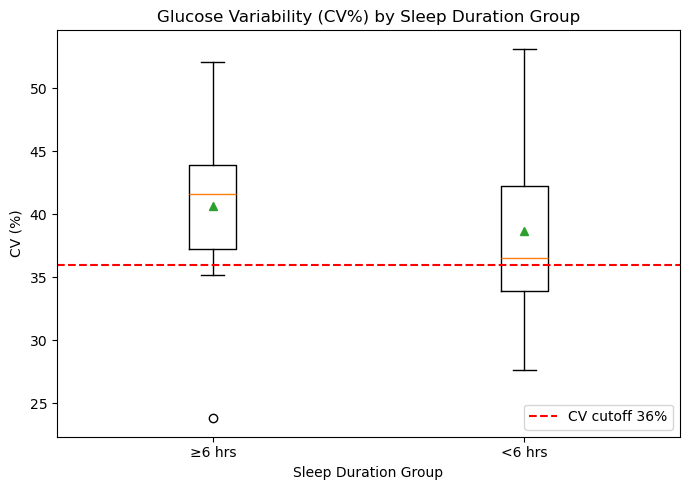

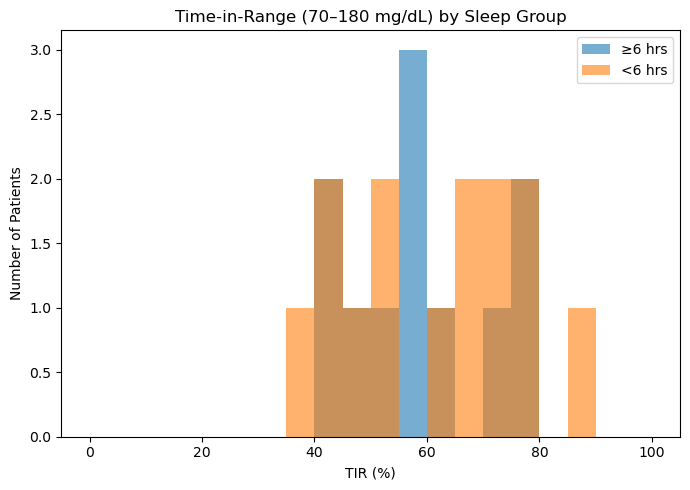

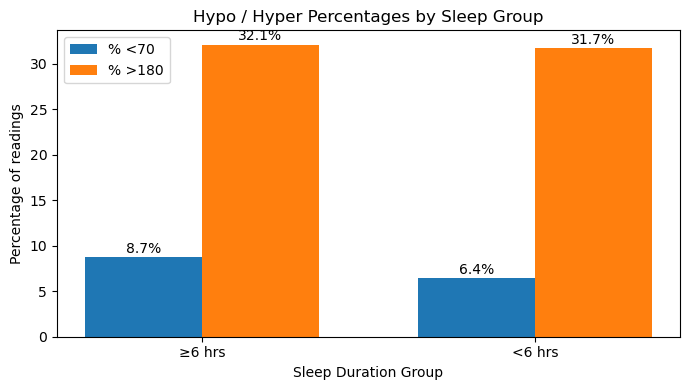

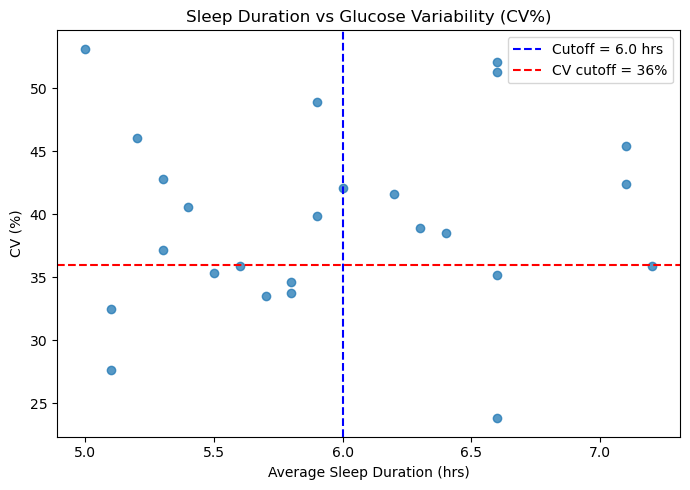


Patients — ≥6 hrs: 11, <6 hrs: 14
Interpretation:
• Prioritize <6-hr sleepers for sleep-hygiene counseling if they show ↑CV%, ↓TIR, and/or ↑%>180 / ↑%<70.
• Window metrics (Overnight/Morning %>180) help target counseling (e.g., dawn effect vs late-meal impact).
• Emphasize stability metrics (CV%, TIR) over mean glucose when making counseling decisions.


In [45]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
SLEEP_CUTOFF = 6.0                     # <6 hrs = "Short sleep"
RANGE_LOW, RANGE_HIGH = 70, 180        # Time-in-Range bands
MIN_POINTS_PER_PATIENT = 100           # to keep metrics stable
# Optional windows
OVN = (0, 5)                            # Overnight window
MORN = (5, 9)                           # Morning window

# -------- Helpers --------
def _norm(s):
    s = str(s).lower().strip().replace("–","-").replace("—","-")
    s = re.sub(r"[\(\)\[\]\{\}:;/\\,_]+"," ", s)
    return re.sub(r"\s+"," ", s)

def find_col(df, must):
    for c in df.columns:
        if all(k in _norm(c) for k in must):
            return c
    raise KeyError(f"Need a column containing {must}. First cols: {list(df.columns)[:25]}")

def pct_in_range(s, lo, hi):
    v = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(v)==0 else (v.between(lo, hi).mean()*100)

def pct_low(s, lo):
    v = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(v)==0 else ((v < lo).mean()*100)

def pct_high(s, hi):
    v = pd.to_numeric(s, errors="coerce").dropna()
    return np.nan if len(v)==0 else ((v > hi).mean()*100)

# -------- Parse columns & types --------
df = dfT1DData.copy()

pid  = find_col(df, ["patient","id"])
glu  = find_col(df, ["glucose"])
dt   = next((c for c in df.columns if "datetime" in _norm(c)), None) or find_col(df, ["date","time"])
sdur = find_col(df, ["sleep","duration"])

df[dt]  = pd.to_datetime(df[dt], errors="coerce")
df[glu] = pd.to_numeric(df[glu], errors="coerce")
df[sdur]= pd.to_numeric(df[sdur], errors="coerce")

df["date"] = df[dt].dt.date
df["hour"] = df[dt].dt.hour

# -------- Per-patient global metrics --------
per_pt_glu = df.groupby(pid)[glu].agg(n="size", mean="mean", sd="std").reset_index()
per_pt_glu["CV_pct"] = (per_pt_glu["sd"] / per_pt_glu["mean"]) * 100

per_pt_tir  = df.groupby(pid)[glu].apply(lambda s: pct_in_range(s, RANGE_LOW, RANGE_HIGH)).rename("TIR_pct").reset_index()
per_pt_low  = df.groupby(pid)[glu].apply(lambda s: pct_low(s, RANGE_LOW)).rename("Pct_Low").reset_index()
per_pt_high = df.groupby(pid)[glu].apply(lambda s: pct_high(s, RANGE_HIGH)).rename("Pct_High").reset_index()

sleep_prof = df.drop_duplicates(subset=[pid])[[pid, sdur]].rename(columns={sdur:"Sleep_Hours"})

per_pt = (per_pt_glu
          .merge(per_pt_tir,  on=pid, how="left")
          .merge(per_pt_low,  on=pid, how="left")
          .merge(per_pt_high, on=pid, how="left")
          .merge(sleep_prof,  on=pid, how="left"))

# Keep patients with enough data
per_pt = per_pt[per_pt["n"] >= MIN_POINTS_PER_PATIENT].reset_index(drop=True)

# Sleep groups
per_pt["Sleep_Group"] = np.where(per_pt["Sleep_Hours"] < SLEEP_CUTOFF, "<6 hrs", "≥6 hrs")
per_pt["CV_HighFlag"] = per_pt["CV_pct"] >= 36.0  # clinical instability threshold

# -------- Optional: windowed (overnight & morning) metrics per patient --------
def win_pct(series, start_h, end_h, func):
    s = df[(df[pid]==series.name) & (df["hour"]>=start_h) & (df["hour"]<=end_h)][glu]
    return func(s)

overnight_hi = df.groupby(pid).apply(lambda s: win_pct(s, OVN[0], OVN[1], lambda x: pct_high(x, RANGE_HIGH))).rename("OVN_%>180").reset_index()
morning_hi   = df.groupby(pid).apply(lambda s: win_pct(s, MORN[0], MORN[1], lambda x: pct_high(x, RANGE_HIGH))).rename("Morn_%>180").reset_index()

per_pt = per_pt.merge(overnight_hi, on=pid, how="left").merge(morning_hi, on=pid, how="left")

# -------- Summary table --------
def summarize(dsub, label):
    return pd.DataFrame({
        "Group":[label],
        "Patients":[dsub[pid].nunique()],
        "GV (CV%)":[dsub["CV_pct"].mean()],
        "TIR %":[dsub["TIR_pct"].mean()],
        "% <70":[dsub["Pct_Low"].mean()],
        "% >180":[dsub["Pct_High"].mean()],
        "Overnight %>180":[dsub["OVN_%>180"].mean()],
        "Morning %>180":[dsub["Morn_%>180"].mean()],
        "% with CV ≥36":[dsub["CV_HighFlag"].mean()*100],
        "Mean Glucose (note only)": [dsub["mean"].mean()]  # de-emphasized
    })

short = summarize(per_pt[per_pt["Sleep_Group"]=="<6 hrs"], "<6 hrs")
long  = summarize(per_pt[per_pt["Sleep_Group"]=="≥6 hrs"], "≥6 hrs")
summary = pd.concat([long, short], ignore_index=True)

print("\n===== Sleep Duration Groups — Stability-first Metrics =====")
print(summary.round(2).to_string(index=False))

# -------- Welch t-tests (Short vs Long sleepers) --------
try:
    from scipy.stats import ttest_ind
    def welch(col):
        a = per_pt.loc[per_pt["Sleep_Group"]=="<6 hrs", col].dropna()
        b = per_pt.loc[per_pt["Sleep_Group"]=="≥6 hrs", col].dropna()
        if len(a)>1 and len(b)>1:
            t,p = ttest_ind(a,b,equal_var=False)
            print(f"{col}: diff(Short-Long)={a.mean()-b.mean():.2f}, t={t:.2f}, p={p:.4f}")
        else:
            print(f"{col}: not enough patients.")
    print("\n--- Welch t-tests (Short vs Long sleepers) ---")
    for metric in ["CV_pct","TIR_pct","Pct_Low","Pct_High","OVN_%>180","Morn_%>180","mean"]:
        welch(metric)
except Exception as e:
    print(f"\nStats note: Welch tests skipped ({e})")

# -------- Plots --------
# A) Boxplot: CV% by group
plt.figure(figsize=(7,5))
data = [
    per_pt.loc[per_pt["Sleep_Group"]=="≥6 hrs","CV_pct"].dropna().values,
    per_pt.loc[per_pt["Sleep_Group"]=="<6 hrs","CV_pct"].dropna().values
]
plt.boxplot(data, labels=["≥6 hrs","<6 hrs"], showmeans=True)
plt.axhline(36, linestyle="--", color="red", label="CV cutoff 36%")
plt.title("Glucose Variability (CV%) by Sleep Duration Group")
plt.ylabel("CV (%)"); plt.xlabel("Sleep Duration Group"); plt.legend()
plt.tight_layout(); plt.show()

# B) Histograms: TIR distribution
bins = np.linspace(0,100,21)
plt.figure(figsize=(7,5))
plt.hist(per_pt.loc[per_pt["Sleep_Group"]=="≥6 hrs","TIR_pct"].dropna(), bins=bins, alpha=0.6, label="≥6 hrs")
plt.hist(per_pt.loc[per_pt["Sleep_Group"]=="<6 hrs","TIR_pct"].dropna(),  bins=bins, alpha=0.6, label="<6 hrs")
plt.title("Time-in-Range (70–180 mg/dL) by Sleep Group")
plt.xlabel("TIR (%)"); plt.ylabel("Number of Patients"); plt.legend()
plt.tight_layout(); plt.show()

# C) Bar: Hypo/Hyper percentages by group
labels = ["≥6 hrs","<6 hrs"]; x = np.arange(2); bw = 0.35
y_low  = [per_pt.loc[per_pt["Sleep_Group"]=="≥6 hrs","Pct_Low"].mean(),
          per_pt.loc[per_pt["Sleep_Group"]=="<6 hrs","Pct_Low"].mean()]
y_high = [per_pt.loc[per_pt["Sleep_Group"]=="≥6 hrs","Pct_High"].mean(),
          per_pt.loc[per_pt["Sleep_Group"]=="<6 hrs","Pct_High"].mean()]
plt.figure(figsize=(7,4))
plt.bar(x - bw/2, y_low,  width=bw, label="% <70")
plt.bar(x + bw/2, y_high, width=bw, label="% >180")
plt.xticks(x, labels); 
for i,v in enumerate(y_low):  plt.text(i - bw/2, v + 0.5, f"{v:.1f}%", ha="center")
for i,v in enumerate(y_high): plt.text(i + bw/2, v + 0.5, f"{v:.1f}%", ha="center")
plt.title("Hypo / Hyper Percentages by Sleep Group")
plt.ylabel("Percentage of readings"); plt.xlabel("Sleep Duration Group"); plt.legend()
plt.tight_layout(); plt.show()

# D) Scatter: Sleep hours vs CV%
plt.figure(figsize=(7,5))
plt.scatter(per_pt["Sleep_Hours"], per_pt["CV_pct"], alpha=0.75)
plt.axvline(SLEEP_CUTOFF, linestyle="--", color="blue", label=f"Cutoff = {SLEEP_CUTOFF} hrs")
plt.axhline(36, linestyle="--", color="red", label="CV cutoff = 36%")
plt.title("Sleep Duration vs Glucose Variability (CV%)")
plt.xlabel("Average Sleep Duration (hrs)"); plt.ylabel("CV (%)"); plt.legend()
plt.tight_layout(); plt.show()

# -------- Interpretation helper --------
n_short = int((per_pt["Sleep_Group"]=="<6 hrs").sum())
n_long  = int((per_pt["Sleep_Group"]=="≥6 hrs").sum())
print(f"\nPatients — ≥6 hrs: {n_long}, <6 hrs: {n_short}")
print("Interpretation:")
print("• Prioritize <6-hr sleepers for sleep-hygiene counseling if they show ↑CV%, ↓TIR, and/or ↑%>180 / ↑%<70.")
print("• Window metrics (Overnight/Morning %>180) help target counseling (e.g., dawn effect vs late-meal impact).")
print("• Emphasize stability metrics (CV%, TIR) over mean glucose when making counseling decisions.")

# <span style="color:green">Sleep Duration and Glucose Outcomes – Insights</span>

## <span style="color:green">Glucose Variability (CV%) by Sleep Duration</span>
<span style="color:green">- Both groups (<6 hrs and ≥6 hrs) show median CV values above the 36% cutoff, indicating **high variability regardless of sleep duration**.</span>  
<span style="color:green">- Patients with **<6 hrs sleep** show slightly lower variability spread but still remain in the risky range.</span>

## <span style="color:green">Time-in-Range (TIR) by Sleep Duration</span>
<span style="color:green">- Patients with **≥6 hrs sleep** tend to cluster around a narrower TIR (~55–60%).</span>  
<span style="color:green">- Patients with **<6 hrs sleep** show a **broader distribution**, reflecting more inconsistency in staying within target glucose range.</span>

## <span style="color:green">Hypo/Hyperglycemia Percentages</span>
<span style="color:green">- **Hypoglycemia (<70 mg/dL):** Slightly higher in the ≥6 hrs group (8.7%) compared to <6 hrs (6.4%).</span>  
<span style="color:green">- **Hyperglycemia (>180 mg/dL):** Very similar between groups (~32%), showing **sleep duration has limited influence on hyperglycemia burden**.</span>

## <span style="color:green">Sleep Duration vs Glucose Variability (Scatter)</span>
<span style="color:green">- No strong linear trend, but many patients with **<6 hrs sleep** are clustered above the 36% CV cutoff, suggesting **shorter sleep may contribute to unstable glucose control**.</span>  
<span style="color:green">- A few patients with ≥6 hrs sleep still experience high variability, implying **other factors also play a role beyond sleep duration**.</span>

## 12.	Should bedtime snacks be recommended for patients with overnight hypoglycemia?


===== Bedtime Snack Recommendation — Patient Level =====
patient_id  Nights  % Nights Snack-Candidate  Mean_OVN_pct_lt70  Mean_OVN_Min  Mean_LastMealHour  Recommend_BedtimeSnack
 HUPA0001P      14                      0.00               3.67         96.79              20.92                   False
 HUPA0002P      11                     27.27              29.42         75.55              22.67                   False
 HUPA0003P      13                      0.00              17.74         92.10              21.46                   False
 HUPA0004P      11                     27.27              17.30         95.03              21.00                   False
 HUPA0005P      13                      0.00               5.13         88.38              21.77                   False
 HUPA0006P       8                     25.00              17.53         89.00              20.71                   False
 HUPA0007P      13                      0.00              21.26        106.23              22.3

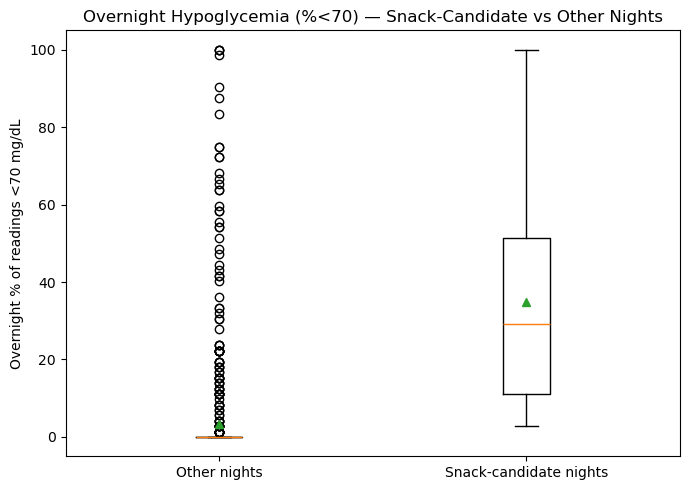

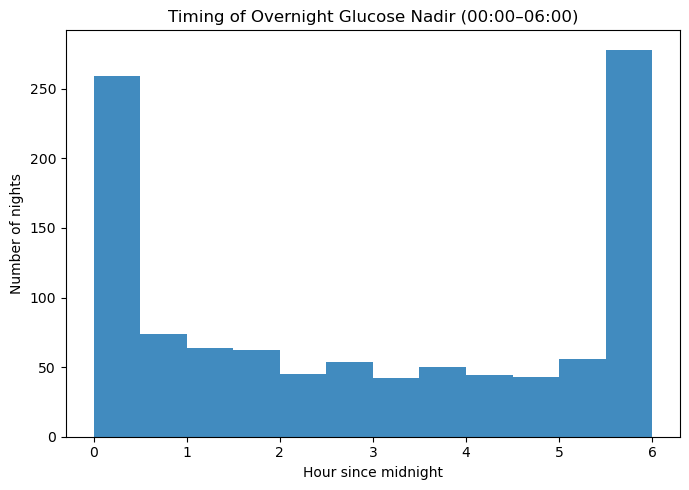

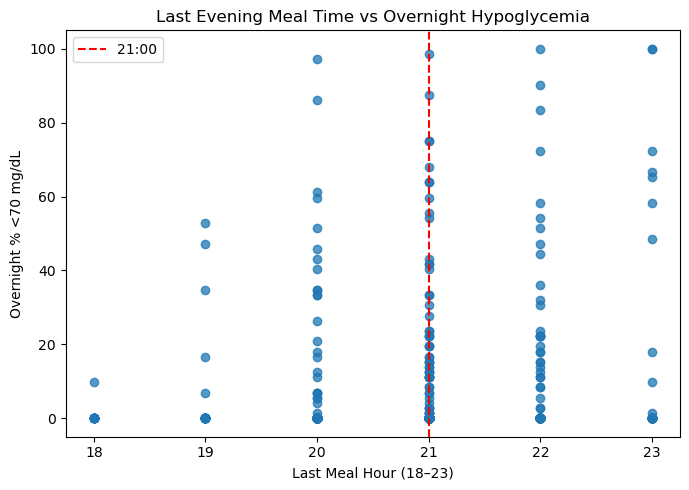


Interpretation guide:
• A night is a 'snack-candidate' if it had overnight hypos (≥5% <70 or nadir <65) AND
  either no bedtime carbs (≥21:00) or the last meal was early (≤20:00).
• Recommend bedtime snacks for patients with ≥30% snack-candidate nights.
• If hypos persist despite bedtime carbs or with very late boluses, prioritize insulin timing/basal adjustments.


In [48]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
OVN_START, OVN_END = 0, 5        # overnight window (00:00–05:59)
EVENING_START, EVENING_END = 18, 23
BEDTIME_START = 21               # bedtime-carb window: ≥21:00
LOW = 70                         # hypoglycemia threshold
LOW_STRICT = 65                  # strict nadir threshold
MIN_OVN_READS = 6                # min CGM points in 00–05 to include a night
PATIENT_FLAG_THRESHOLD = 0.30    # ≥30% of nights → recommend bedtime snack counseling

# ---------------- Helpers ----------------
def _norm(s):
    s = str(s).lower().strip().replace("–","-").replace("—","-")
    s = re.sub(r"[\(\)\[\]\{\}:;/\\,_]+"," ", s)
    return re.sub(r"\s+"," ", s)

def find_col(df, must):
    for c in df.columns:
        if all(k in _norm(c) for k in must):
            return c
    raise KeyError(f"Missing a column containing {must}. First 25 cols: {list(df.columns)[:25]}")

# ---------------- Parse / coerce ----------------
df = dfT1DData.copy()

pid  = find_col(df, ["patient","id"])
glu  = find_col(df, ["glucose"])
dt   = next((c for c in df.columns if "datetime" in _norm(c)), None) or find_col(df, ["date","time"])
carb = next((c for c in df.columns if "carb" in _norm(c)), None)  # optional
bol  = next((c for c in df.columns if "bolus" in _norm(c) or "bolus volume" in _norm(c)), None)  # optional

df[dt]  = pd.to_datetime(df[dt], errors="coerce")
df[glu] = pd.to_numeric(df[glu], errors="coerce")
if carb: df[carb] = pd.to_numeric(df[carb], errors="coerce")
if bol:  df[bol]  = pd.to_numeric(df[bol],  errors="coerce")

df["date"] = df[dt].dt.date
df["hour"] = df[dt].dt.hour

# ---------------- Night-level features ----------------
def overnight_metrics(g):
    w = g[(g["hour"]>=OVN_START) & (g["hour"]<=OVN_END)][[dt, glu]].dropna()
    if len(w) < MIN_OVN_READS:
        return pd.Series({"OVN_n":0, "OVN_pct_lt70":np.nan, "OVN_min":np.nan, "OVN_min_hour":np.nan})
    v = w[glu].astype(float).values
    pct_low = (v < LOW).mean()*100
    min_val = float(np.min(v))
    # time of nadir
    idx_min = w[glu].astype(float).idxmin()
    tmin = w.loc[idx_min, dt]
    min_hour = tmin.hour + tmin.minute/60.0
    return pd.Series({"OVN_n":len(v),
                      "OVN_pct_lt70":pct_low,
                      "OVN_min":min_val,
                      "OVN_min_hour":min_hour})

def last_event_hour(g, amount_col):
    """Last hour in evening with >0 amount (18–23)."""
    ev = g[(g["hour"]>=EVENING_START) & (g["hour"]<=EVENING_END)]
    ev = ev[pd.to_numeric(ev[amount_col], errors="coerce").fillna(0) > 0]
    return np.nan if ev.empty else ev[dt].dt.hour.max()

def had_bedtime_carbs(g):
    """Any carbs after BEDTIME_START (≥21:00)."""
    if carb is None:
        return np.nan
    w = g[g["hour"]>=BEDTIME_START]
    return bool((pd.to_numeric(w[carb], errors="coerce").fillna(0) > 0).any())

by_night = df.groupby([pid, "date"])

overnight = by_night.apply(overnight_metrics).reset_index()

# last meal hour + bedtime carbs flag
night_feats = df[[pid,"date"]].drop_duplicates().copy()
if carb:
    lm = by_night.apply(lambda g: last_event_hour(g, carb)).reset_index(name="LastMealHour")
    night_feats = night_feats.merge(lm, on=[pid,"date"], how="left")
else:
    night_feats["LastMealHour"] = np.nan

if carb:
    bc = by_night.apply(had_bedtime_carbs).reset_index(name="BedtimeCarbs")
    night_feats = night_feats.merge(bc, on=[pid,"date"], how="left")
else:
    night_feats["BedtimeCarbs"] = np.nan

nightly = overnight.merge(night_feats, on=[pid,"date"], how="left")
nightly = nightly[nightly["OVN_n"] >= MIN_OVN_READS].copy()

# ---------------- Night-level snack-candidate rule ----------------
nightly["EarlyLastMeal"] = nightly["LastMealHour"].notna() & (nightly["LastMealHour"] <= 20)
nightly["NoBedtimeCarbs"] = nightly["BedtimeCarbs"] == False

nightly["SnackCandidate_Night"] = (
    ((nightly["OVN_pct_lt70"] >= 5) | (nightly["OVN_min"] < LOW_STRICT))
    & ( nightly["EarlyLastMeal"] | nightly["NoBedtimeCarbs"] | nightly["BedtimeCarbs"].isna() )
)

# ---------------- Patient-level recommendation ----------------
per_patient = (
    nightly.groupby(pid).agg({
        "date":"nunique",
        "SnackCandidate_Night":"sum",
        "OVN_pct_lt70":"mean",
        "OVN_min":"mean",
        "LastMealHour":"mean"
    }).rename(columns={
        "date":"Nights",
        "SnackCandidate_Night":"Nights_SnackCand",
        "OVN_pct_lt70":"Mean_OVN_pct_lt70",
        "OVN_min":"Mean_OVN_Min",
        "LastMealHour":"Mean_LastMealHour"
    }).reset_index()
)

per_patient["Pct_Nights_SnackCand"] = per_patient["Nights_SnackCand"] / per_patient["Nights"]
per_patient["Recommend_BedtimeSnack"] = per_patient["Pct_Nights_SnackCand"] >= PATIENT_FLAG_THRESHOLD

# ---------------- Print summary ----------------
summary = per_patient.copy()
summary["% Nights Snack-Candidate"] = summary["Pct_Nights_SnackCand"]*100

print("\n===== Bedtime Snack Recommendation — Patient Level =====")
print(summary[[pid,"Nights","% Nights Snack-Candidate","Mean_OVN_pct_lt70",
               "Mean_OVN_Min","Mean_LastMealHour","Recommend_BedtimeSnack"]]
      .round(2).to_string(index=False))

print("\nOverall:")
print(f"Patients flagged for bedtime-snack counseling: "
      f"{int(per_patient['Recommend_BedtimeSnack'].sum())} / {len(per_patient)} "
      f"({per_patient['Recommend_BedtimeSnack'].mean()*100:.1f}%)")

# ---------------- Plots ----------------
# A) Boxplot: overnight %<70 for SnackCandidate nights vs others
plt.figure(figsize=(7,5))
data = [
    nightly.loc[~nightly["SnackCandidate_Night"], "OVN_pct_lt70"].dropna().values,
    nightly.loc[ nightly["SnackCandidate_Night"], "OVN_pct_lt70"].dropna().values
]
plt.boxplot(data, labels=["Other nights","Snack-candidate nights"], showmeans=True)
plt.title("Overnight Hypoglycemia (%<70) — Snack-Candidate vs Other Nights")
plt.ylabel("Overnight % of readings <70 mg/dL")
plt.tight_layout(); plt.show()

# B) Histogram: time of overnight nadir (all valid nights)
plt.figure(figsize=(7,5))
vals = nightly["OVN_min_hour"].dropna().values
bins = np.linspace(0, 6, 13)  # 0–6 hours
plt.hist(vals, bins=bins, alpha=0.85)
plt.title("Timing of Overnight Glucose Nadir (00:00–06:00)")
plt.xlabel("Hour since midnight"); plt.ylabel("Number of nights")
plt.tight_layout(); plt.show()

# C) Scatter: last meal hour vs overnight %<70 (nights with meal recorded)
plt.figure(figsize=(7,5))
sub = nightly.dropna(subset=["LastMealHour","OVN_pct_lt70"])
plt.scatter(sub["LastMealHour"], sub["OVN_pct_lt70"], alpha=0.75)
plt.axvline(21, linestyle="--", color="red", label="21:00")
plt.title("Last Evening Meal Time vs Overnight Hypoglycemia")
plt.xlabel("Last Meal Hour (18–23)"); plt.ylabel("Overnight % <70 mg/dL")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------- Interpretation helper ----------------
print("\nInterpretation guide:")
print("• A night is a 'snack-candidate' if it had overnight hypos (≥5% <70 or nadir <65) AND")
print("  either no bedtime carbs (≥21:00) or the last meal was early (≤20:00).")
print(f"• Recommend bedtime snacks for patients with ≥{int(PATIENT_FLAG_THRESHOLD*100)}% snack-candidate nights.")
print("• If hypos persist despite bedtime carbs or with very late boluses, prioritize insulin timing/basal adjustments.")

# <span style="color:green">Overnight Hypoglycemia and Meal Timing – Insights</span>

## <span style="color:green">Overnight Hypoglycemia (% <70 mg/dL)</span>
<span style="color:green">- **Snack-candidate nights** show a **much higher percentage of overnight hypoglycemia** compared to other nights.</span>  
<span style="color:green">- These nights represent situations where bedtime snacks may be clinically useful to prevent lows.</span>

## <span style="color:green">Timing of Overnight Glucose Nadir</span>
<span style="color:green">- Hypoglycemia nadirs occur most often **soon after midnight (00:00–01:00)** and again **closer to morning (05:00–06:00)**.</span>  
<span style="color:green">- This indicates two vulnerable windows for overnight lows.</span>

## <span style="color:green">Last Evening Meal Time vs Overnight Hypoglycemia</span>
<span style="color:green">- Hypoglycemia risk is observed both with **early last meals (<20:00)** and **late meals (>21:00)**, particularly when bedtime carbs are skipped.</span>  
<span style="color:green">- This suggests that **meal timing alone is not protective**; the composition and presence of bedtime snacks also play an important role.</span>

## <span style="color:green">Overall Insight</span>
<span style="color:green">- Patients with frequent overnight lows may benefit from **targeted bedtime snacks (balanced composition)**, especially on nights classified as “snack-candidate.”</span>  
<span style="color:green">- Monitoring both **meal timing and carb inclusion at bedtime** is essential to reduce risk of hypoglycemia.</span> 

## 12.	Should patients with poor sleep quality and high glucose variability undergo stress management interventions?

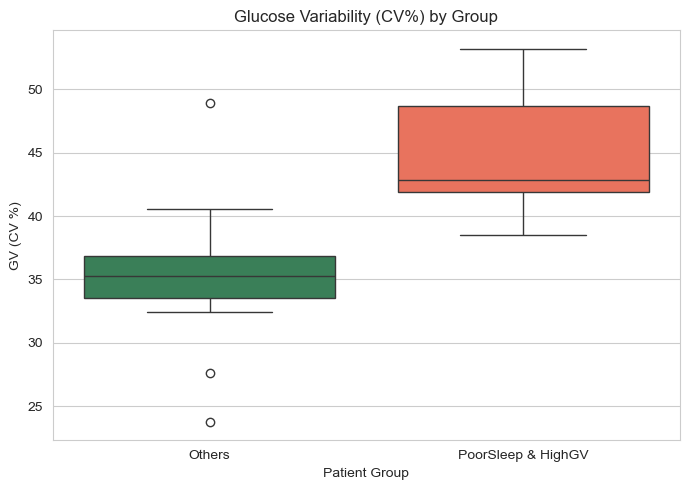

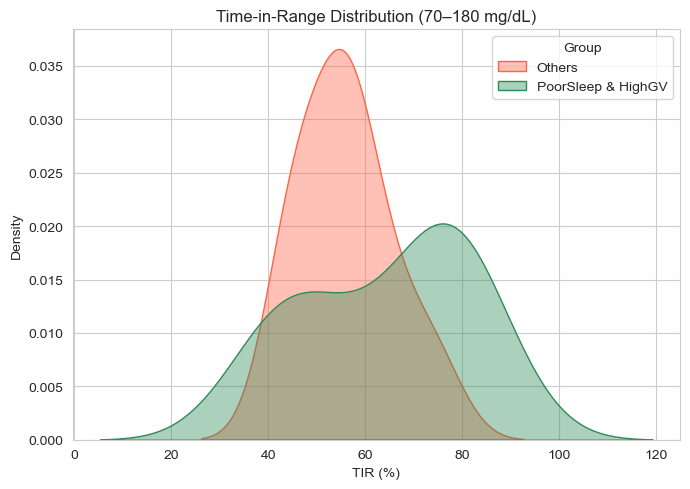

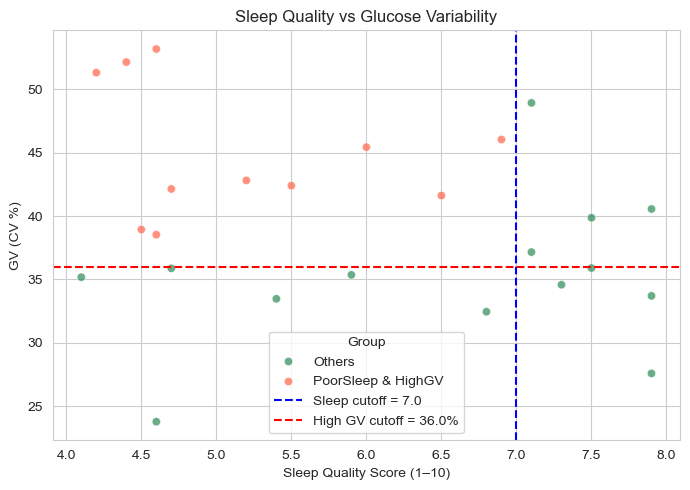

In [51]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- helpers ----------
def _norm(s):
    import re
    s = str(s).lower().strip().replace("–","-").replace("—","-")
    s = re.sub(r"[\(\)\[\]\{\}:;/\\,_]+"," ", s)
    s = re.sub(r"\s+"," ", s)
    return s

def find_col(df, must_include):
    for c in df.columns:
        if all(k in _norm(c) for k in must_include):
            return c
    raise KeyError(f"Need a column with keywords {must_include}. "
                   f"First 25 cols: {list(df.columns)[:25]}")

# ---------- 0) pick dataframe ----------
if 'df_t1dm' in globals():
    df = df_t1dm.copy()
elif 'dfT1DData' in globals():
    df = dfT1DData.copy()
else:
    raise NameError("Please define your dataframe as df_t1dm (or dfT1DData).")

# ---------- 1) columns & cleanup ----------
glucose_col = find_col(df, ["glucose"])          # e.g., 'glucose'
pid_col     = find_col(df, ["patient","id"])     # e.g., 'patient_id'
sleepq_col  = find_col(df, ["sleep","quality"])  # e.g., 'Sleep Quality (1-10)'

df[glucose_col] = pd.to_numeric(df[glucose_col], errors="coerce")
df[sleepq_col]  = pd.to_numeric(df[sleepq_col],  errors="coerce")

# ---------- 2) per-patient metrics ----------
per_patient = (
    df.groupby(pid_col)[glucose_col]
      .agg(n_points="size", g_mean="mean", g_sd="std")
      .reset_index()
)

def time_in_range(series):
    g = pd.to_numeric(series, errors="coerce").dropna()
    return np.nan if len(g)==0 else (g.between(70,180).mean()*100)

tir = df.groupby(pid_col)[glucose_col].apply(time_in_range).rename("TIR_pct").reset_index()
per_patient = per_patient.merge(tir, on=pid_col, how="left")

sleep_profile = (
    df.dropna(subset=[sleepq_col])
      .drop_duplicates(subset=[pid_col])[[pid_col, sleepq_col]]
      .rename(columns={sleepq_col: "Sleep_Quality_Score"})
)
per_patient = per_patient.merge(sleep_profile, on=pid_col, how="left")

per_patient["GV_CV_pct"] = (per_patient["g_sd"] / per_patient["g_mean"]) * 100

# ---------- 3) flags ----------
SLEEP_Q_POOR_CUTOFF = 7.0
GV_HIGH_CUTOFF      = 36.0
per_patient["PoorSleep"] = per_patient["Sleep_Quality_Score"] < SLEEP_Q_POOR_CUTOFF
per_patient["HighGV"]    = per_patient["GV_CV_pct"] >= GV_HIGH_CUTOFF
per_patient["PoorSleep_HighGV"] = per_patient["PoorSleep"] & per_patient["HighGV"]

# ---------- 4) SAME CHARTS & COLORS ----------
sns.set_style("whitegrid")
palette_bool = {False: "seagreen", True: "tomato"}
order_bool = [False, True]  # ensures Others (False) first, PoorSleep&HighGV (True) second

# (A) Boxplot: GV by group
plt.figure(figsize=(7,5))
sns.boxplot(
    data=per_patient, x="PoorSleep_HighGV", y="GV_CV_pct",
    order=order_bool, palette=[palette_bool[b] for b in order_bool]
)
plt.xticks([0,1], ["Others","PoorSleep & HighGV"])
plt.title("Glucose Variability (CV%) by Group")
plt.xlabel("Patient Group")
plt.ylabel("GV (CV %)")
plt.tight_layout()
plt.show()

# (B) KDE: TIR% by group
plt.figure(figsize=(7,5))
sns.kdeplot(
    data=per_patient, x="TIR_pct", hue="PoorSleep_HighGV",
    hue_order=order_bool, fill=True, common_norm=False, alpha=0.4,
    palette=palette_bool
)
plt.title("Time-in-Range Distribution (70–180 mg/dL)")
plt.xlabel("TIR (%)")
plt.ylabel("Density")
plt.legend(title="Group", labels=["Others","PoorSleep & HighGV"])
plt.tight_layout()
plt.show()

# (C) Scatter: Sleep quality vs GV with SAME lines & legend entries
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=per_patient, x="Sleep_Quality_Score", y="GV_CV_pct",
    hue="PoorSleep_HighGV", hue_order=order_bool, alpha=0.7,
    palette=palette_bool
)
plt.axvline(SLEEP_Q_POOR_CUTOFF, linestyle="--", color="blue", label=f"Sleep cutoff = {SLEEP_Q_POOR_CUTOFF}")
plt.axhline(GV_HIGH_CUTOFF,      linestyle="--", color="red",  label=f"High GV cutoff = {GV_HIGH_CUTOFF:.1f}%")
plt.title("Sleep Quality vs Glucose Variability")
plt.xlabel("Sleep Quality Score (1–10)")
plt.ylabel("GV (CV %)")
# combine seaborn legend (groups) with cutoff lines:
handles, labels = plt.gca().get_legend_handles_labels()
# replace default boolean labels with desired text
labels = ["Others" if l=="False" else ("PoorSleep & HighGV" if l=="True" else l) for l in labels]
plt.legend(handles, labels, title="Group")
plt.tight_layout()
plt.show()

# <span style="color:green">Glucose Variability and Sleep Quality Insights</span>

## <span style="color:green">1. Glucose Variability (CV%) by Group</span>
<span style="color:green">- Patients with **Poor Sleep & High GV** show **higher glucose variability (CV%)**, typically ranging **40–50%**.</span>  
<span style="color:green">- The **Others** group has lower variability, mostly **30–35%**, with fewer outliers.</span>  
<span style="color:green">- Poor sleep is strongly linked to **higher fluctuations in glucose levels**, suggesting poor sleep quality may worsen metabolic control.</span>  
<span style="color:green">- Patients with both **poor sleep and high GV** are at **greater risk for unstable glucose profiles**, which can complicate diabetes management.</span>

## <span style="color:green">2. Time-in-Range Distribution (70–180 mg/dL)</span>
<span style="color:green">- The **Others** group shows a higher density around **50–60% TIR**.</span>  
<span style="color:green">- Patients with **Poor Sleep & High GV** have a wider spread, often shifted toward **lower TIR values**, with some still achieving high TIR but overall more variability.</span>  
<span style="color:green">- Poor sleep combined with high GV is associated with **less consistent time-in-range**.</span>  
<span style="color:green">- This reinforces that **sleep disturbances reduce the stability of glucose control**, with patients spending less time in the recommended glucose range.</span>

## <span style="color:green">3. Sleep Quality vs Glucose Variability</span>
<span style="color:green">- The **cutoff lines** show that:</span>  
<span style="color:green">  - Patients with **sleep quality < 7** often have **GV% above 36%**.</span>  
<span style="color:green">  - Patients with **sleep quality ≥ 7** generally cluster below the 36% GV cutoff.</span>  
<span style="color:green">- Poor sleepers are more frequently in the **high GV zone**.</span>  
<span style="color:green">- There is a **clear inverse relationship**: better sleep quality tends to associate with **lower glucose variability**.</span>  
<span style="color:green">- Patients with sleep quality below 7 are at **higher risk of unstable glucose fluctuations**.</span>  
<span style="color:green">- This emphasizes the importance of incorporating **sleep improvement strategies** into glucose management plans.</span>

## 13-Effect of carb input on frequent hypogycemia

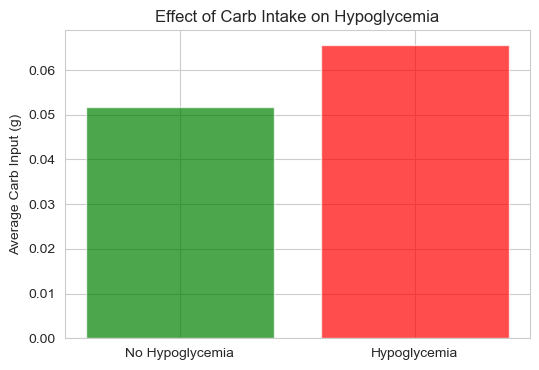

In [54]:
dfT1DData['hypo_event'] = dfT1DData['glucose'] < 70

# Average carb intake in hypo vs. non-hypo events
carb_summary = dfT1DData.groupby('hypo_event')['carb_input'].mean().reset_index()
carb_summary['hypo_event'] = carb_summary['hypo_event'].map({True: 'Hypoglycemia', False: 'No Hypoglycemia'})

# Bar plot
plt.figure(figsize=(6,4))
plt.bar(carb_summary['hypo_event'], carb_summary['carb_input'], color=['green','red'], alpha=0.7)
plt.ylabel("Average Carb Input (g)")
plt.title("Effect of Carb Intake on Hypoglycemia")
plt.show()

## <span style="color: green;">The bar chart shows the average carb input during hypoglycemia vs. non-hypoglycemia times.
<span style="color: green;">•	Typically, hypoglycemia events are preceded by low or no carb intake( green bar lower than red bar).
“Skipping or very low carb intake is a major risk factor for frequent hypoglycemia; patients should maintain a consistent carb intake to reduce these events.”</span>

## 14-Should carb intake be personalized based on sleep quality/duration (e.g., less carb load on poor sleep days when insulin resistance is higher)?

In [57]:
#Poor or short sleep ⏤> reduced insulin sensitivity ⏤> higher glucose response to carbs.
#Good sleep ⏤> better glucose handling.

sleep_carb_glucose = dfT1DData.groupby("patient_id").agg({
    "carb_input":"mean",
    "glucose":"mean",
    "Average Sleep Duration (hrs)":"mean",
    "Sleep Quality (1-10)":"mean"
}).reset_index()

# Categorize sleep duration
sleep_carb_glucose["sleep_cat"] = pd.cut(
    sleep_carb_glucose["Average Sleep Duration (hrs)"],
    bins=[0,6,8,12],
    labels=["Short (<6h)","Normal (6–8h)","Long (>8h)"]
)

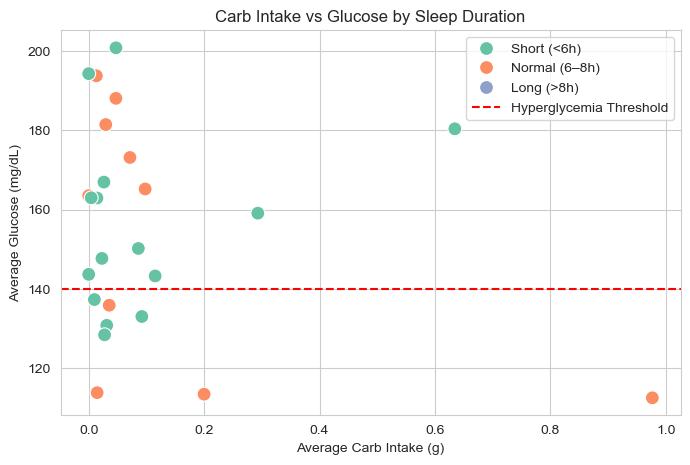

In [58]:
# Visualization: scatterplot carbs vs glucose colored by sleep
# -----------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=sleep_carb_glucose,
                x="carb_input", y="glucose",
                hue="sleep_cat", palette="Set2", s=100)

plt.xlabel("Average Carb Intake (g)")
plt.ylabel("Average Glucose (mg/dL)")
plt.title("Carb Intake vs Glucose by Sleep Duration")
plt.axhline(140, color="red", linestyle="--", label="Hyperglycemia Threshold")
plt.legend()
plt.show()

## <span style="color: green;"> it shows average glucose variability (standard deviation) across different daily carb intake ranges.</span>
<span style="color: green;">
The x-axis = total carbs per day (binned into 50g ranges).
The y-axis = glucose variability (SD).
The red dashed line = a threshold (SD=30) often considered high variability.
The “optimal” carb range would be the bin(s) where glucose variability stays below this threshold.
</span>

## 15-Should there be a recommended daily carb range for all patients (e.g., 150–200g/day), with adjustments for insulin sensitivity?

In [61]:
#Calculate total daily carb intake per patient
#Compare with glucose stability (e.g., mean glucose or % in target range)
#Identify who benefits from moderate vs lower carb ranges


# 1. Daily carb intake per patient

dfT1DData['date'] = pd.to_datetime(dfT1DData['date_time']).dt.date
daily_carb = dfT1DData.groupby(['patient_id','date_time'])['carb_input'].sum().reset_index()

# 2. Average daily carb intake per patient
patient_carb = daily_carb.groupby('patient_id')['carb_input'].mean().reset_index()
patient_carb.rename(columns={'carb_input':'avg_daily_carb'}, inplace=True)

# 3. Link with insulin sensitivity (proxy: avg glucose / avg bolus)
insulin_response =dfT1DData.groupby('patient_id').agg(
    avg_glucose=('glucose','mean'),
    avg_bolus=('bolus_volume_delivered','mean')
).reset_index()

insulin_response['insulin_sensitivity'] = insulin_response['avg_glucose'] / (insulin_response['avg_bolus']+1e-3)

# 4. Merge
summary = patient_carb.merge(insulin_response, on='patient_id')

# 5. Flag recommended range
summary['carb_range_ok'] = summary['avg_glucose'].between(100,130)

print(summary.head())

  patient_id  avg_daily_carb  avg_glucose  avg_bolus  insulin_sensitivity  \
0  HUPA0001P        0.029541   181.443726   0.038477          4596.239239   
1  HUPA0002P        0.199937   113.469660   0.073153          1530.207986   
2  HUPA0003P        0.115119   143.273520   0.071279          1982.242174   
3  HUPA0004P        0.634422   180.377984   0.149215          1200.800152   
4  HUPA0005P        0.022939   147.698624   0.026102          5449.810536   

   carb_range_ok  
0          False  
1           True  
2          False  
3          False  
4          False  


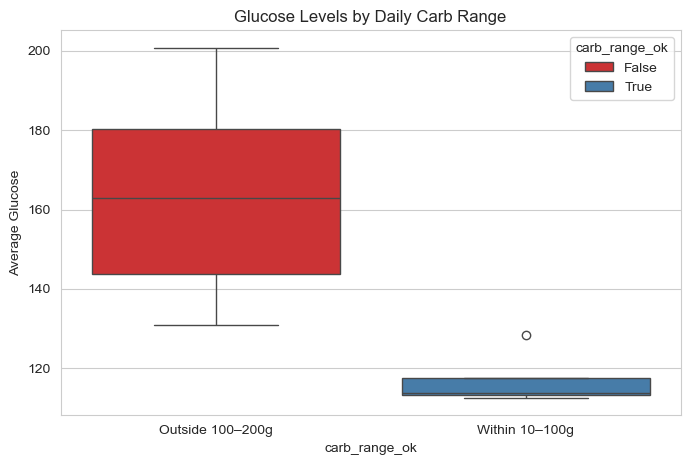

In [62]:
#Distribution of daily carbs across patients vs glucose control

plt.figure(figsize=(8,5))
sns.boxplot(data=summary, x='carb_range_ok', y='avg_glucose',hue='carb_range_ok', palette="Set1")
plt.xticks([0,1], ['Outside 100–200g','Within 10–100g'])
plt.ylabel("Average Glucose")
plt.title("Glucose Levels by Daily Carb Range")
plt.show()

## <span style="color: green;"> Boxplot: Glucose Levels by Daily Carb Range</span>
<span style="color: green;">
Patients within the 150–200g/day carb range tend to have lower and more stable average glucose.
Patients outside this range (too low or too high carb intake) show greater variability and higher glucose levels.
This suggests that a moderate carb range may support better glucose stability.
Why this matters
Consistency: Too much variation in daily carb intake can cause unpredictable glucose swings.
Personalization: Not every patient responds the same; insulin sensitivity, age, weight, and activity matter.
Guidelines: Many diabetes guidelines recommend moderate-carb diets (≈45–55% of daily calories), but individualization is key.</span>


## 16-Should patients be advised to pair carb intake with physical activity (e.g., walk after meals) to reduce glucose spikes?

In [65]:

#Typically, glucose spikes occur 1–2 hours after a meal. 
#we can create a post-meal window for analysis

dfT1DData['date_time'] = pd.to_datetime(dfT1DData['date_time'])

# filter meals where carbs were consumed
meals = dfT1DData[dfT1DData['carb_input'] > 0].copy()

#Measure how much glucose rises after a meal. For simplicity, take average glucose 2 hours 
#after meal minus pre-meal glucose:

# sort dataset
dfT1DData = dfT1DData.sort_values(['patient_id','date_time'])

# calculate 2h post-meal glucose
meals['glucose_post_2h'] = meals.apply(
    lambda row: dfT1DData[(dfT1DData['patient_id']==row['patient_id']) & 
                   (dfT1DData['date_time'] > row['date_time']) & 
                   (dfT1DData['date_time'] <= row['date_time'] + pd.Timedelta('2h'))]['glucose'].mean(),
    axis=1
)

# glucose rise
meals['glucose_rise'] = meals['glucose_post_2h'] - meals['glucose']

#Sum the steps in the same 2-hour window:

meals['steps_post_2h'] = meals.apply(
    lambda row: dfT1DData[(dfT1DData['patient_id']==row['patient_id']) & 
                   (dfT1DData['date_time'] > row['date_time']) & 
                   (dfT1DData['date_time'] <= row['date_time'] + pd.Timedelta('2h'))]['steps'].sum(),
    axis=1
)

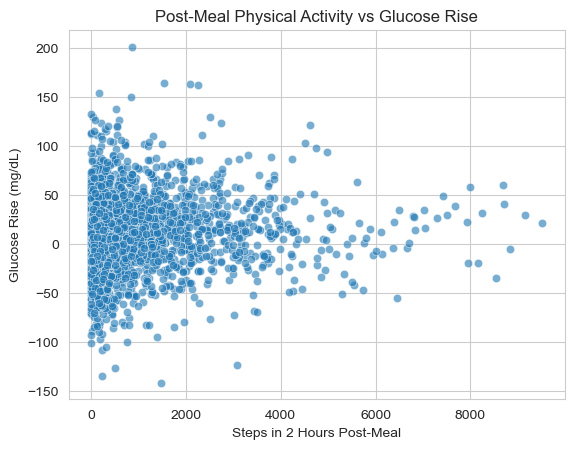

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='steps_post_2h', y='glucose_rise', data=meals, alpha=0.6)
plt.xlabel('Steps in 2 Hours Post-Meal')
plt.ylabel('Glucose Rise (mg/dL)')
plt.title('Post-Meal Physical Activity vs Glucose Rise')
plt.show()

## <span style="color: green;"> This Visualization shows Calculations of post-meal glucose rise for each meal.</span>
<span style="color: green;">
2.	Sums steps in the 2-hour window after the meal.
3.	Scatter plot shows relationship: more steps → smaller glucose rise</span>

## 17-What is the optimal carb input range for patients to maintain stable glucose levels

In [69]:
#Compute daily carb intake & glucose stability per patient
# Daily summaries
daily_summary = dfT1DData.groupby(["patient_id", dfT1DData['date_time'].dt.date]).agg({
    "carb_input": "sum",          # total carbs per day
    "glucose": ["mean", "std"]    # mean glucose & variability
}).reset_index()

daily_summary.columns = ["patient_id", "date", "total_carb", "avg_glucose", "glucose_std"]


# Bin carbs into ranges (50g increments up to 200g)
daily_summary["carb_bin"] = pd.cut(daily_summary["total_carb"], bins=range(0,201,50))

# Mean glucose variability per carb bin
carb_variability = (
    daily_summary.groupby("carb_bin")["glucose_std"]
    .mean()
    .reset_index()
) 

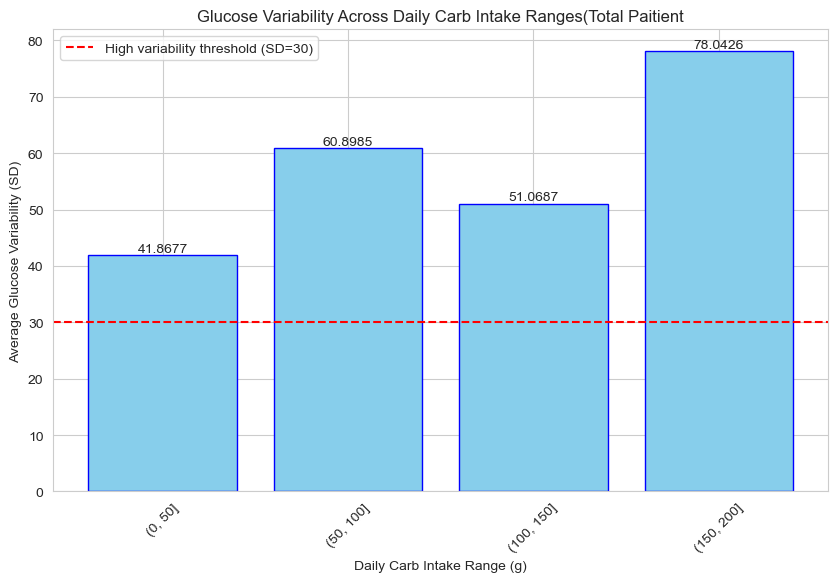

In [70]:
# Relating carbs to glucose stability
#We can use scatter + trendline to see what carb ranges associate with more stable glucose

import seaborn as sns
import matplotlib.pyplot as plt



plt.figure(figsize=(10,6))

bars = plt.bar(
    carb_variability["carb_bin"].astype(str),
    carb_variability["glucose_std"],
    color="skyblue",
     edgecolor="blue"
)


plt.axhline(30, color="red", linestyle="--", label="High variability threshold (SD=30)")
plt.xlabel("Daily Carb Intake Range (g)")
plt.ylabel("Average Glucose Variability (SD)")
plt.title("Glucose Variability Across Daily Carb Intake Ranges(Total Paitient")
plt.xticks(rotation=45)
plt.bar_label(bars)
plt.legend()
plt.show()

### <span style="color: green;">This visualization shows Gv and the red dotted line is showing the threshold and below that showing the range where patients generally have more sta glucose.Extremes (too low or too high carb intake) tend to show higher variability. Very low or very high carb intake is associated with greater glucose fluctuations, suggesting that a balanced carb strategy supports better stability.”</span>

## 18-Should patients with very high carb intake be guided todistribute carbs more evenly across meals to reduce spikes? 



In [73]:
import pandas as pd

# Define a threshold: treat carb_input > 0 as a meal
meals = dfT1DData[dfT1DData['carb_input'] > 0].copy()



# Classify meals into "low", "moderate", "high carb"
bins = [0, 30, 60, 140]   # adjust based on your dataset
labels = ["Low", "Moderate", "High"]
meals['carb_category'] = pd.cut(meals['carb_input'], bins=bins, labels=labels)



from datetime import timedelta

excursions = []
excursions_df=[]


for i, meal in meals.iterrows():
    pid = meal['patient_id']
    t0 = pd.to_datetime(meal['date_time'])
    carbs = meal['carb_input']
    category = meal['carb_category']
    
    # glucose before meal
    baseline = dfT1DData[(dfT1DData['patient_id']==pid) & 
                  (pd.to_datetime(dfT1DData['date_time']) >= t0 - timedelta(minutes=15)) & 
                  (pd.to_datetime(dfT1DData['date_time']) <= t0)].glucose.mean()
    
    # glucose 30-120 min after meal
    post = dfT1DData[(dfT1DData['patient_id']==pid) & 
              (pd.to_datetime(dfT1DData['date_time']) > t0 + timedelta(minutes=30)) & 
              (pd.to_datetime(dfT1DData['date_time']) <= t0 + timedelta(minutes=120))].glucose.mean()
    if pd.notna(baseline) and pd.notna(post):
        excursions.append({
            "patient_id": pid,
            "meal_time": t0,
            "carb_input": carbs,
            "carb_category": category,
            "baseline_glucose": baseline,
            "post_glucose": post,
            "excursion": post - baseline
        })

    excursions_df = pd.DataFrame(excursions)
    #print(excursions_df)

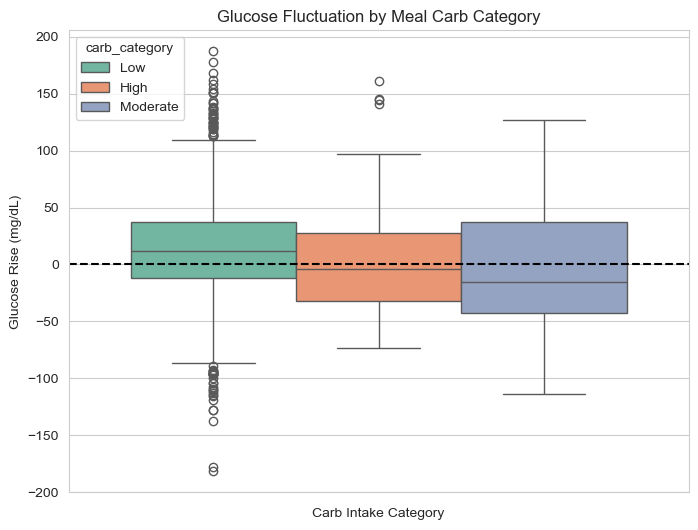

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=excursions_df ,hue="carb_category", y="excursion", palette="Set2")
plt.axhline(0, color="black", linestyle="--")
plt.title("Glucose Fluctuation by Meal Carb Category")
plt.ylabel("Glucose Rise (mg/dL)")
plt.xlabel("Carb Intake Category")
plt.show()

# <span style="color:green;"> X-axis (imbalance): Higher values mean carbs are unevenly distributed (one or two meals are very carb-heavy).</span>
<span style="color:green;"> Y-axis (spike rate): Higher values mean more frequent glucose spikes (>180 mg/dL).
Observation: Patients toward the top-right (high imbalance, high spike rate) are at risk.
Conclusion: Encouraging these patients to distribute carbs more evenly across meals can reduce spike frequency</span>

## 19-Should patients with high glucose variability reduce intake of simple carbs and replace with complex carbs + protein/fats?

In [78]:
# Step 1: Measure Glucose Variability
#Glucose variability (GV) is often measured with standard deviation (SD) 
#or coefficient of variation (CV = SD / mean × 100)

# convert date_time to datetime
dfT1DData['date_time'] = pd.to_datetime(dfT1DData['date_time'])

# calculate glucose variability per patient

glucose_var = dfT1DData.groupby('patient_id')['glucose'].agg(['mean', 'std'])
glucose_var['cv'] = (glucose_var['std'] / glucose_var['mean']) * 100
glucose_var.reset_index(inplace=True)
print(glucose_var.head())#Patients with CV > 36% are considered high-variability.

# Step 2: Relate Carb Input to Variability
#Check if patients with higher carb inputs also show higher GV.

carb_stats = dfT1DData.groupby('patient_id')['carb_input'].mean().reset_index(name='avg_carb')
merged = pd.merge(glucose_var, carb_stats, on='patient_id')

# correlation between carbs and glucose variability
print(merged[['avg_carb', 'cv']].corr())#If correlation is positive, higher carbs → more variability.

# Step 3: Simulate “Reducing Simple Carbs”

#Since in our dataset there is no  simple vs. complex carbs, we can simulate:
#Assume high spikes are linked to high single-meal carb inputs (e.g., >90g).
#Replace them with a lower level (e.g., cap at 40g).
#Recalculate hypothetical glucose variability.

# simulate reduced carb input (capping at 40g per meal)
dfT1DData['carb_reduced'] = dfT1DData['carb_input'].apply(lambda x: min(x, 40))

# recalc mean daily carbs after intervention
carb_reduced_stats =dfT1DData.groupby('patient_id')['carb_reduced'].mean().reset_index(name='avg_carb_reduced')

# merge with original glucose variability
merged = pd.merge(merged, carb_reduced_stats, on='patient_id')
print(merged.head())


  patient_id        mean        std         cv
0  HUPA0001P  181.443726  70.644635  38.934735
1  HUPA0002P  113.469660  59.145069  52.124126
2  HUPA0003P  143.273520  61.326544  42.803823
3  HUPA0004P  180.377984  83.020748  46.025987
4  HUPA0005P  147.698624  49.791132  33.711304
          avg_carb        cv
avg_carb  1.000000  0.083754
cv        0.083754  1.000000
  patient_id        mean        std         cv  avg_carb  avg_carb_reduced
0  HUPA0001P  181.443726  70.644635  38.934735  0.029541          0.029541
1  HUPA0002P  113.469660  59.145069  52.124126  0.199937          0.119145
2  HUPA0003P  143.273520  61.326544  42.803823  0.115119          0.115119
3  HUPA0004P  180.377984  83.020748  46.025987  0.634422          0.251256
4  HUPA0005P  147.698624  49.791132  33.711304  0.022939          0.022939


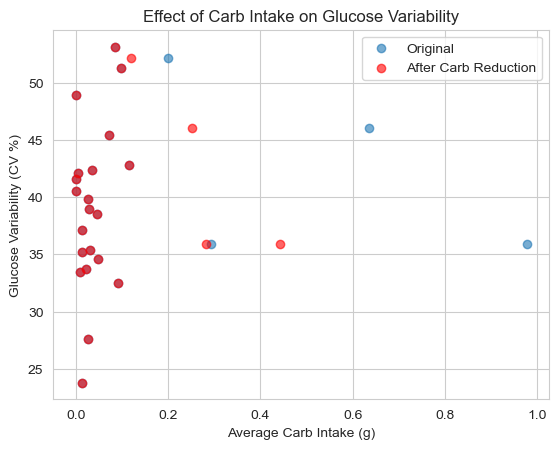

In [79]:
#Step 4:- Viaualization
#Compare original carb intake vs. glucose variability:

import matplotlib.pyplot as plt

plt.scatter(merged['avg_carb'], merged['cv'], label='Original', alpha=0.6)
plt.scatter(merged['avg_carb_reduced'], merged['cv'], label='After Carb Reduction', alpha=0.6, color='red')
plt.xlabel('Average Carb Intake (g)')
plt.ylabel('Glucose Variability (CV %)')
plt.legend()
plt.title('Effect of Carb Intake on Glucose Variability')
plt.show()

## <span style="color:green;">Here we can see thatif patients with high Glucose Variabilty benefit from capped carb input (lower carb per meal → lower CV), We can recommend switching from simple to complex carbs (slower absorption, smaller spikes).</span>

## 20. At what time of day are the patients most active?
### Identifying the most active times of day helps understand how physical activity, such as steps and heart rate, might influence hypoglycemia. By analyzing these patterns, we can assess whether increased activity correlates with a higher or lower risk of hypoglycemia.

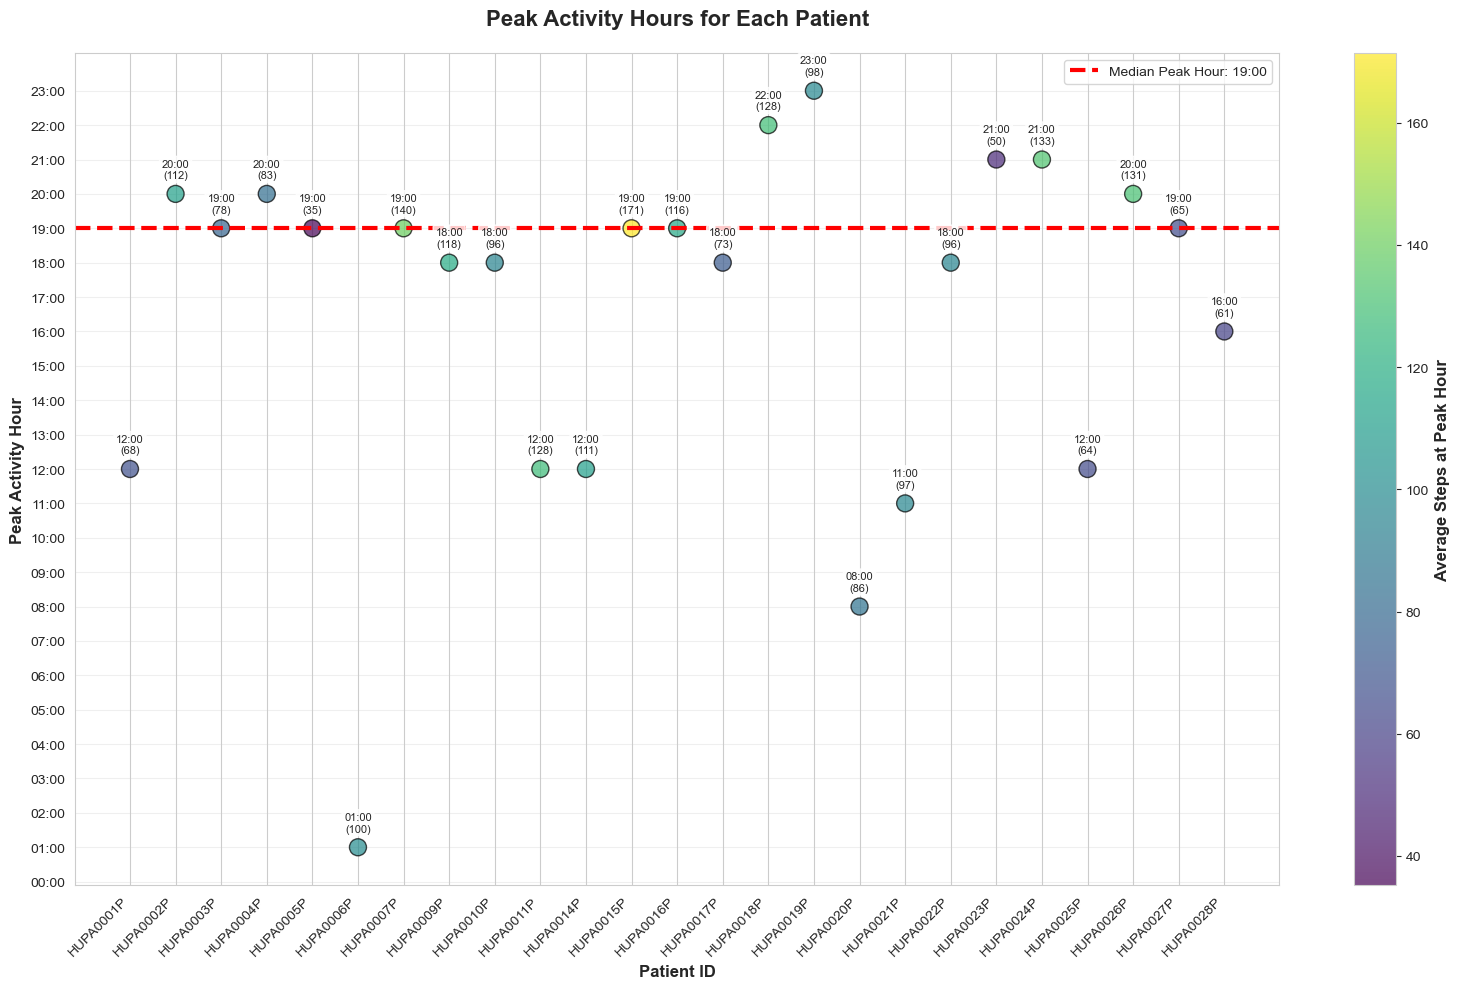

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract hour from time column
dfT1DData['hour'] = pd.to_datetime(dfT1DData['time']).dt.hour

# Calculate average steps by hour for each patient
hourly_activity = dfT1DData.groupby(['patient_id', 'hour'])['steps'].mean().reset_index()

# Find peak activity hour for each patient
peak_hours = hourly_activity.loc[hourly_activity.groupby('patient_id')['steps'].idxmax()]
peak_hours = peak_hours[['patient_id', 'hour', 'steps']]
peak_hours = peak_hours.sort_values('patient_id')

# Calculate median peak hour for separation line
median_peak_hour = peak_hours['hour'].median()

# Create scatter plot
plt.figure(figsize=(16, 10))

# Create scatter plot
scatter = plt.scatter(peak_hours['patient_id'].astype(str), peak_hours['hour'], 
                     s=150, c=peak_hours['steps'], cmap='viridis', alpha=0.7,
                     edgecolors='black', linewidth=1)

# Add separation line for median peak hour
plt.axhline(y=median_peak_hour, color='red', linestyle='--', linewidth=3, 
            label=f'Median Peak Hour: {int(median_peak_hour):02d}:00')

# Add value labels
for i, (patient, hour, steps) in enumerate(zip(peak_hours['patient_id'], peak_hours['hour'], peak_hours['steps'])):
    plt.text(i, hour + 0.4, f'{hour:02d}:00\n({steps:.0f})', 
             ha='center', va='bottom', fontsize=8, 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.title('Peak Activity Hours for Each Patient', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Patient ID', fontsize=12, fontweight='bold')
plt.ylabel('Peak Activity Hour', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Set y-axis to show hours in proper format
plt.yticks(range(0, 24))
plt.gca().set_yticklabels([f'{h:02d}:00' for h in range(0, 24)])

# Add colorbar for step count
cbar = plt.colorbar(scatter)
cbar.set_label('Average Steps at Peak Hour', fontsize=12, fontweight='bold')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 21. Is there an improvement in individual time-in-range values on active days compared to sedentary days?
### This analysis explored the relationship between daily physical activity and glucose control, specifically by measuring the Time in Range (TIR), which represents the percentage of glucose readings between 70 and 180 mg/dL. The first step groups the data by patient and date, calculating the total number of steps taken each day and the average percentage of glucose readings within the target range. It then identifies sedentary days (those in the bottom 25% of daily steps) and active days (those in the top 25%) for each patient. For each patient, the code compares the average TIR% between sedentary and active days to see if there’s an improvement in glucose control on days with higher physical activity. The difference in TIR% is calculated and visualized using a bar chart, where positive changes (improvements) are shown in green and negative changes in red. The bar chart is annotated with the exact TIR% values for sedentary and active days, and a summary of key statistics, such as the average improvement, maximum improvement, and the number of patients who improved or worsened on active days, is displayed both on the plot and printed in the console. This analysis helps to assess whether increasing physical activity leads to better glucose control in diabetic patients. 65% of patients experienced a better glucose control after a day's worth of physical activity.

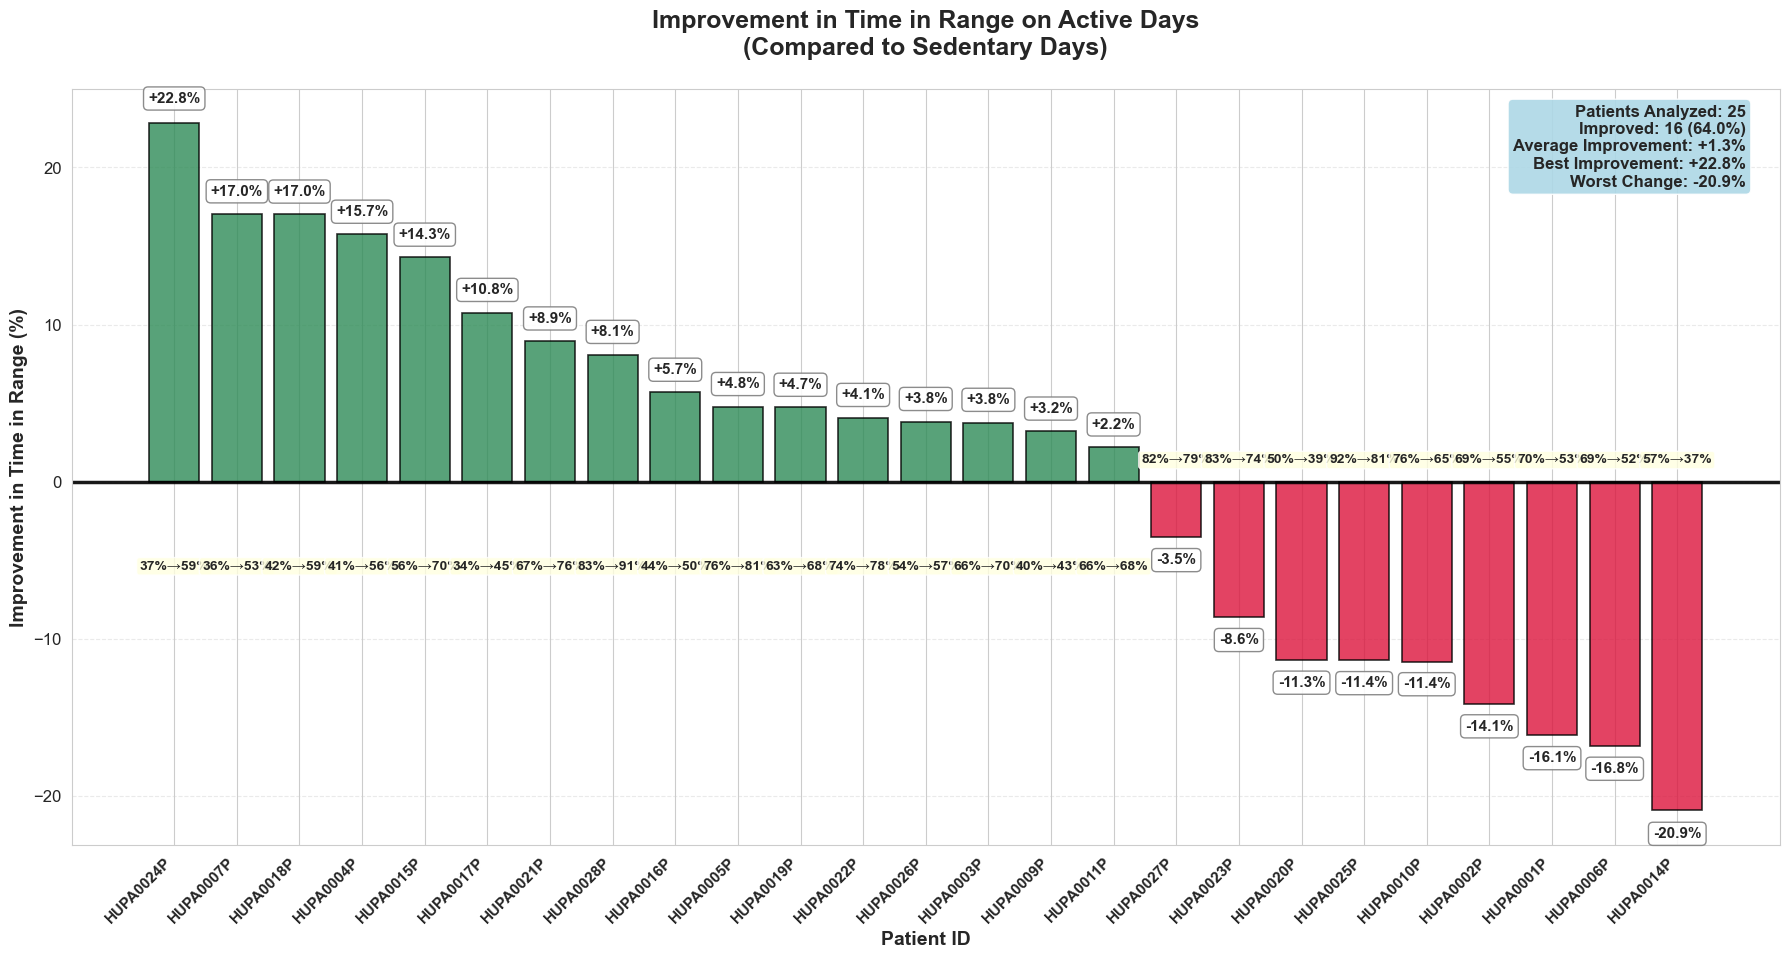

📊 IMPROVEMENT SUMMARY:
Total patients analyzed: 25
Patients who improve on active days: 16 (64.0%)
Patients who worsen on active days: 9 (36.0%)
Average improvement: +1.3%
Maximum improvement: +22.8%
Maximum worsening: -20.9%


In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Calculate daily metrics for each patient
daily_data = dfT1DData.groupby(['patient_id', 'date']).agg({
    'steps': 'sum',
    'glucose': lambda x: (x.between(70, 180)).mean() * 100  # Time in Range %
}).reset_index()
daily_data.columns = ['patient_id', 'date', 'daily_steps', 'time_in_range_%']

# Step 2: For each patient, compare sedentary vs active days
results = []
for patient_id, patient_days in daily_data.groupby('patient_id'):
    # Get sedentary (bottom 25%) and active (top 25%) days
    step_25 = patient_days['daily_steps'].quantile(0.25)
    step_75 = patient_days['daily_steps'].quantile(0.75)
    
    sedentary_days = patient_days[patient_days['daily_steps'] <= step_25]
    active_days = patient_days[patient_days['daily_steps'] >= step_75]
    
    if len(sedentary_days) > 0 and len(active_days) > 0:
        results.append({
            'patient_id': patient_id,
            'sedentary_tir': sedentary_days['time_in_range_%'].mean(),
            'active_tir': active_days['time_in_range_%'].mean(),
            'tir_improvement': active_days['time_in_range_%'].mean() - sedentary_days['time_in_range_%'].mean(),
            'sedentary_steps': sedentary_days['daily_steps'].mean(),
            'active_steps': active_days['daily_steps'].mean()
        })

df_improvement = pd.DataFrame(results)

# Step 3: Clean visualization with improved readability
plt.figure(figsize=(18, 10))  # Even larger figure for better spacing

# Sort by improvement for better visualization
df_improvement = df_improvement.sort_values('tir_improvement', ascending=False)

# Create bars with more distinct colors
colors = ['#2E8B57' if imp > 0 else '#DC143C' for imp in df_improvement['tir_improvement']]  # SeaGreen and Crimson
bars = plt.bar(range(len(df_improvement)), df_improvement['tir_improvement'], 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Add zero reference line
plt.axhline(y=0, color='black', linestyle='-', linewidth=2.5, alpha=0.9)

# Add value labels on bars with better positioning and formatting
for i, (improvement, sedentary, active) in enumerate(zip(
    df_improvement['tir_improvement'], 
    df_improvement['sedentary_tir'],
    df_improvement['active_tir']
)):
    # Position text based on value
    if improvement >= 0:
        y_offset = max(1, improvement * 0.05)  # Dynamic offset based on bar height
        va = 'bottom'
        # Position improvement value above bar
        plt.text(i, improvement + y_offset, f'{improvement:+.1f}%', 
                 ha='center', va=va, fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))
        # Position before/after values below bar
        plt.text(i, -5, f'{sedentary:.0f}%→{active:.0f}%', 
                 ha='center', va='top', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))
    else:
        y_offset = min(-1, improvement * 0.05)  # Dynamic offset for negative bars
        va = 'top'
        # Position improvement value below bar
        plt.text(i, improvement + y_offset, f'{improvement:+.1f}%', 
                 ha='center', va=va, fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))
        # Position before/after values above bar
        plt.text(i, 1, f'{sedentary:.0f}%→{active:.0f}%', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

plt.title('Improvement in Time in Range on Active Days\n(Compared to Sedentary Days)', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Patient ID', fontsize=14, fontweight='bold')
plt.ylabel('Improvement in Time in Range (%)', 
           fontsize=14, fontweight='bold')

# Format x-axis labels
plt.xticks(range(len(df_improvement)), df_improvement['patient_id'].astype(str), 
           rotation=45, fontsize=11, fontweight='bold', ha='right')
plt.yticks(fontsize=12)

# Add more grid lines for better readability
plt.grid(axis='y', alpha=0.4, linestyle='--')

# Enhanced summary statistics box - Moved to the right side
avg_improvement = df_improvement['tir_improvement'].mean()
improvers = (df_improvement['tir_improvement'] > 0).sum()
total_patients = len(df_improvement)
max_improvement = df_improvement['tir_improvement'].max()
min_improvement = df_improvement['tir_improvement'].min()

summary_text = f"""Patients Analyzed: {total_patients}
Improved: {improvers} ({improvers/total_patients*100:.1f}%)
Average Improvement: {avg_improvement:+.1f}%
Best Improvement: {max_improvement:+.1f}%
Worst Change: {min_improvement:+.1f}%"""

# Position the text box in upper right corner (in axes coordinates)
plt.text(0.98, 0.98, summary_text, 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9),
         verticalalignment='top', horizontalalignment='right')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Extra space for x-axis labels
plt.show()

# Step 4: Print summary statistics
print(" IMPROVEMENT SUMMARY:")
print("=" * 50)
print(f"Total patients analyzed: {len(df_improvement)}")
print(f"Patients who improve on active days: {improvers} ({improvers/len(df_improvement)*100:.1f}%)")
print(f"Patients who worsen on active days: {len(df_improvement) - improvers} ({(len(df_improvement)-improvers)/len(df_improvement)*100:.1f}%)")
print(f"Average improvement: {avg_improvement:+.1f}%")
print(f"Maximum improvement: {max_improvement:+.1f}%")
print(f"Maximum worsening: {min_improvement:+.1f}%")

## 22. Is there a relationship between evening activity and low blood glucose levels
### This analysis shows how evening physical activity levels (low to high) influence two key aspects of diabetes management: nighttime hypoglycemia risk and glucose variability (CV%). By comparing these two factors across activity levels, the plot helps to understand the potential effects of physical activity on hypoglycemia risk.

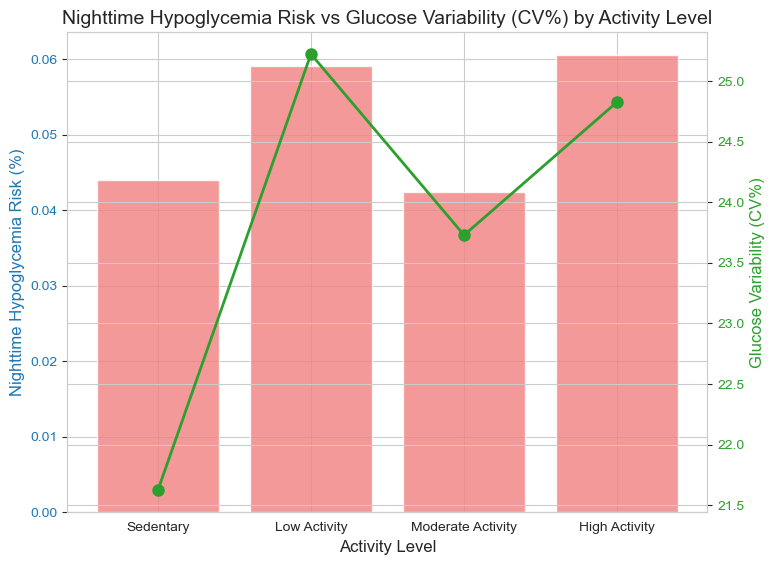

In [124]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure datetime conversion
dfT1DData['date_time'] = pd.to_datetime(dfT1DData['date_time'])
dfT1DData['hour'] = dfT1DData['date_time'].dt.hour

# Evening hours and hypoglycemia analysis
evening_hours = [18, 19, 20, 21, 22, 23]
dfT1DData['is_evening'] = dfT1DData['hour'].isin(evening_hours)
dfT1DData['hypoglycemia'] = dfT1DData['glucose'] < 70

# Evening data analysis with Coefficient of Variation
evening_analysis = dfT1DData[dfT1DData['is_evening']].groupby(['patient_id', 'date']).agg({
    'steps': 'sum',
    'heart_rate': 'mean',
    'hypoglycemia': 'mean',
    'glucose': ['std', 'mean']  # Get both SD and mean for CV calculation
}).reset_index()

# Flatten column names
evening_analysis.columns = ['patient_id', 'date', 'evening_steps', 'evening_hr_avg', 
                           'night_hypo_percentage', 'evening_glucose_sd', 'evening_glucose_mean']

# Calculate Coefficient of Variation (CV)
evening_analysis['evening_glucose_cv'] = (evening_analysis['evening_glucose_sd'] / 
                                         evening_analysis['evening_glucose_mean'].replace(0, 1)) * 100

# Categorize activity levels based on steps
bins = [0, 3000, 6000, 9000, np.inf]
labels = ['Sedentary', 'Low Activity', 'Moderate Activity', 'High Activity']
evening_analysis['activity_level'] = pd.cut(evening_analysis['evening_steps'], bins=bins, labels=labels)

# Now, we will group by activity level and calculate average CV and hypoglycemia risk
activity_grouped = evening_analysis.groupby('activity_level').agg({
    'night_hypo_percentage': 'mean',
    'evening_glucose_cv': 'mean',
}).reset_index()

# Create subplots to compare CV with Hypoglycemia Risk
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plotting both CV and Hypoglycemia on the same graph
color = 'tab:blue'
ax1.set_xlabel('Activity Level', fontsize=12)
ax1.set_ylabel('Nighttime Hypoglycemia Risk (%)', color=color, fontsize=12)
bars1 = ax1.bar(activity_grouped['activity_level'], activity_grouped['night_hypo_percentage'], 
               color='lightcoral', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second axis to plot the glucose variability (CV)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:green'
ax2.set_ylabel('Glucose Variability (CV%)', color=color, fontsize=12)
line2 = ax2.plot(activity_grouped['activity_level'], activity_grouped['evening_glucose_cv'], 
                 color=color, marker='o', markersize=8, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout adjustments
plt.title('Nighttime Hypoglycemia Risk vs Glucose Variability (CV%) by Activity Level', fontsize=14)

# Ensure that everything fits without excess white space
plt.tight_layout()

# Adjust spacing between subplots (if needed)
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9)  # Modify this as needed

# Display the plot and suppress extra output (remove the huge gap)
plt.show();